In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

from lib.visualize import plot_breakpoints_ill, plot_breakpoints_ill_pb
from lib.utils import add_comma_to_pos

plt.style.use('ggplot')

In [2]:
DATE = '20230123'
SAMPLE = '17-08'
SAMPLE_ = SAMPLE.replace('-', '_')
TYPE = 'DEL'
CHROM = 'chr1'

In [3]:
BAM_ILL = f'/confidential/tGenVar/tech/illumina/bam_hg38/ill.{SAMPLE_}.hg38.bam'
BAM_PB = f'/confidential/tGenVar/tech/pb/bam_MDtag_hg38/pb.{SAMPLE_}.hg38.bam'
REPEATS = '/confidential/tGenVar/ref/hg38/annotation/hg38_repeatmasker.tsv'

QCDIR = f'/confidential/tGenVar/sv_manual_curation/{SAMPLE}/{TYPE}/{CHROM}'
QCFILE = f'{DATE}_{SAMPLE}_{TYPE}_{CHROM}.tsv'

100%|██████████| 59/59 [09:53<00:00, 10.06s/it]


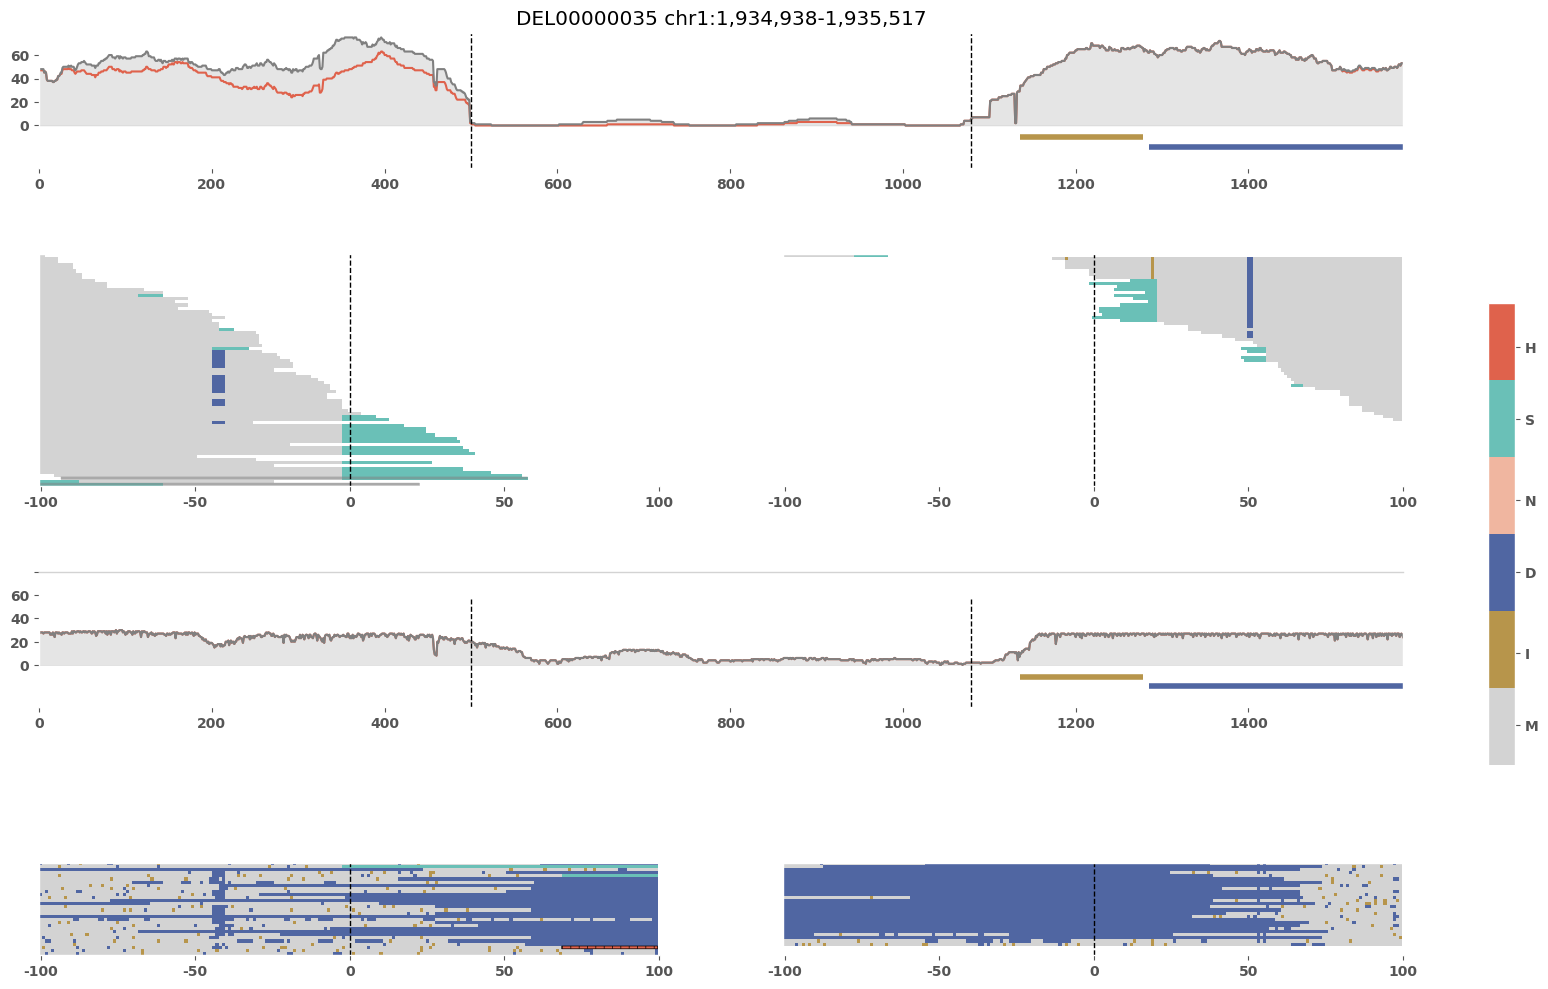

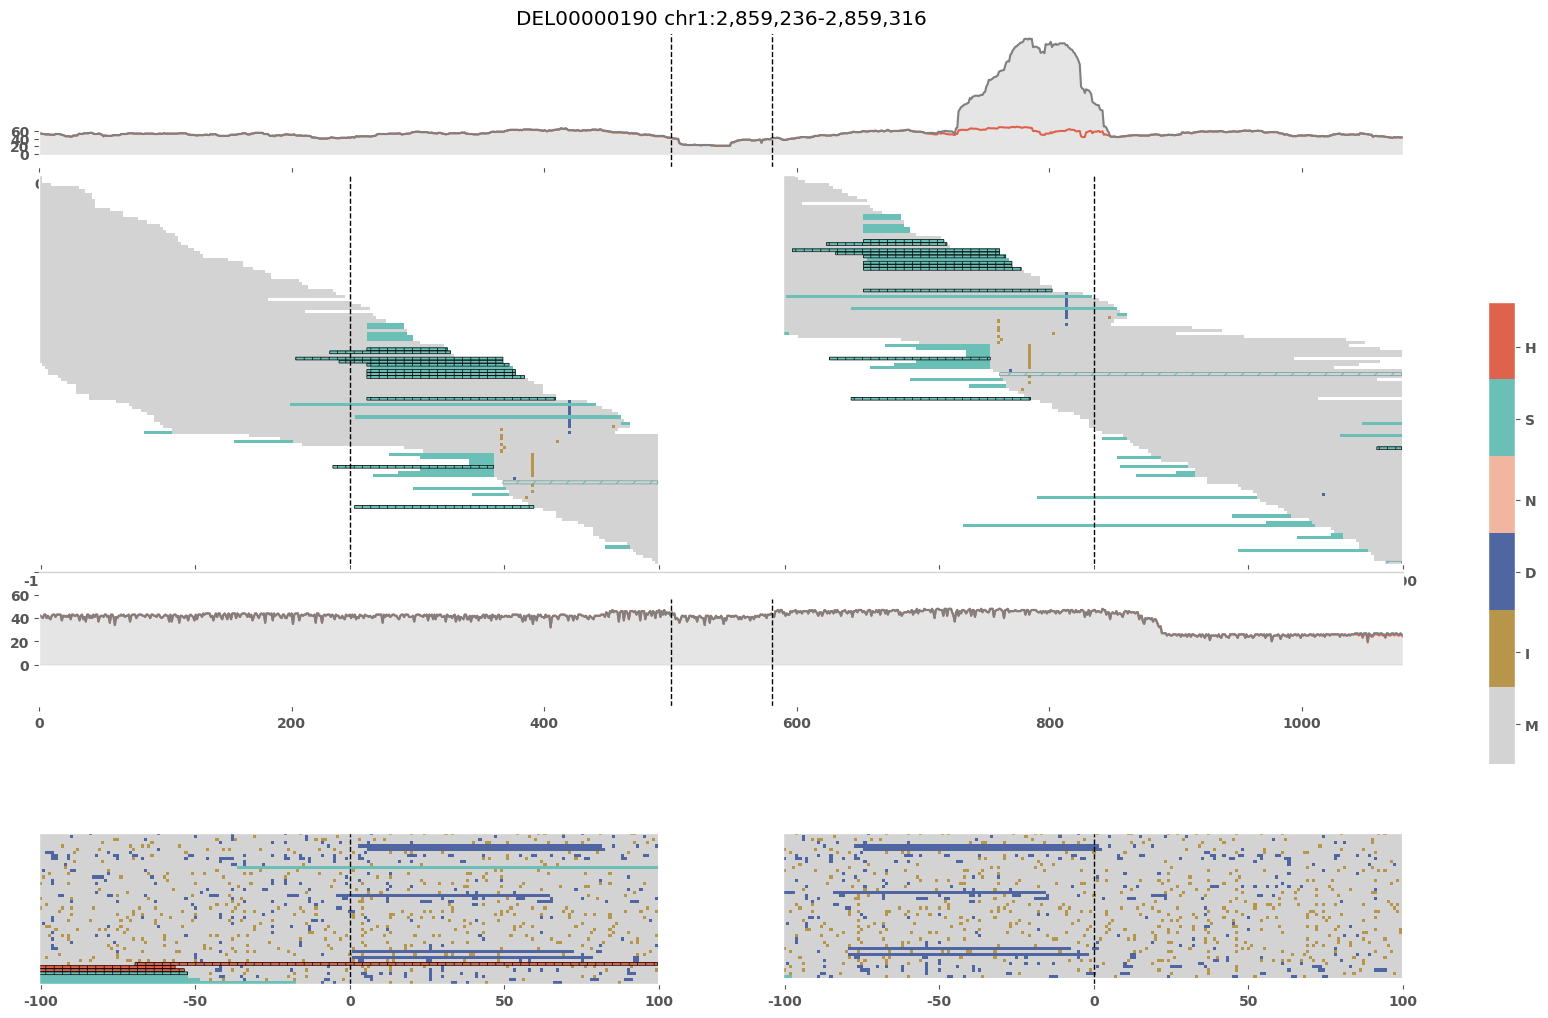

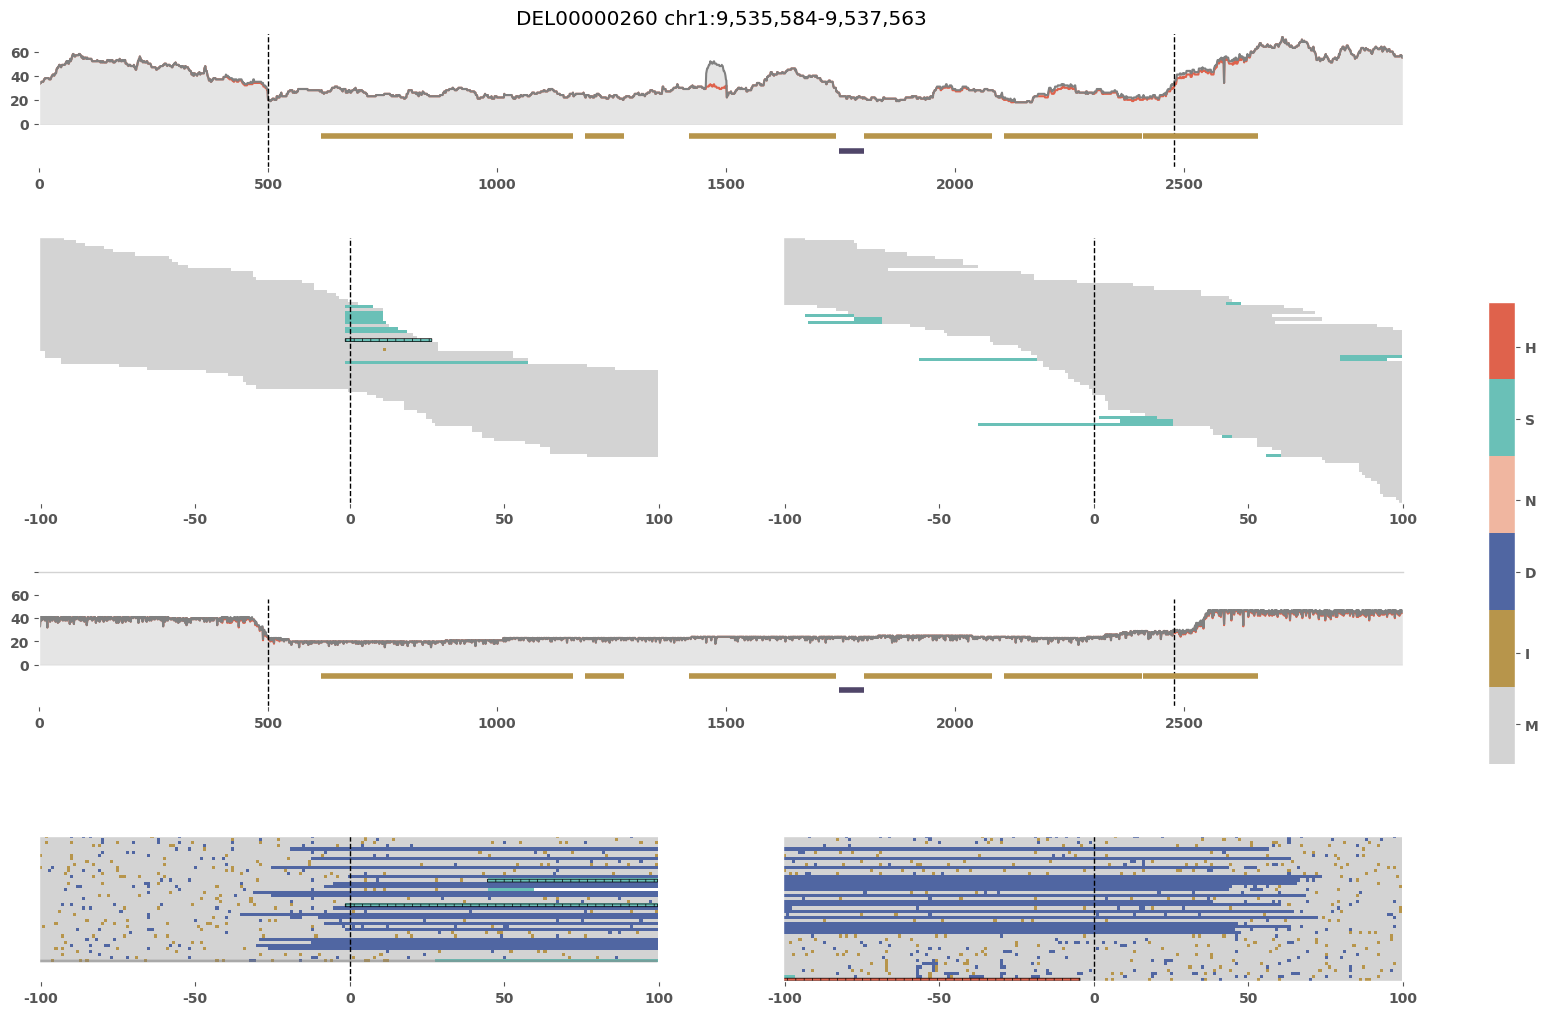

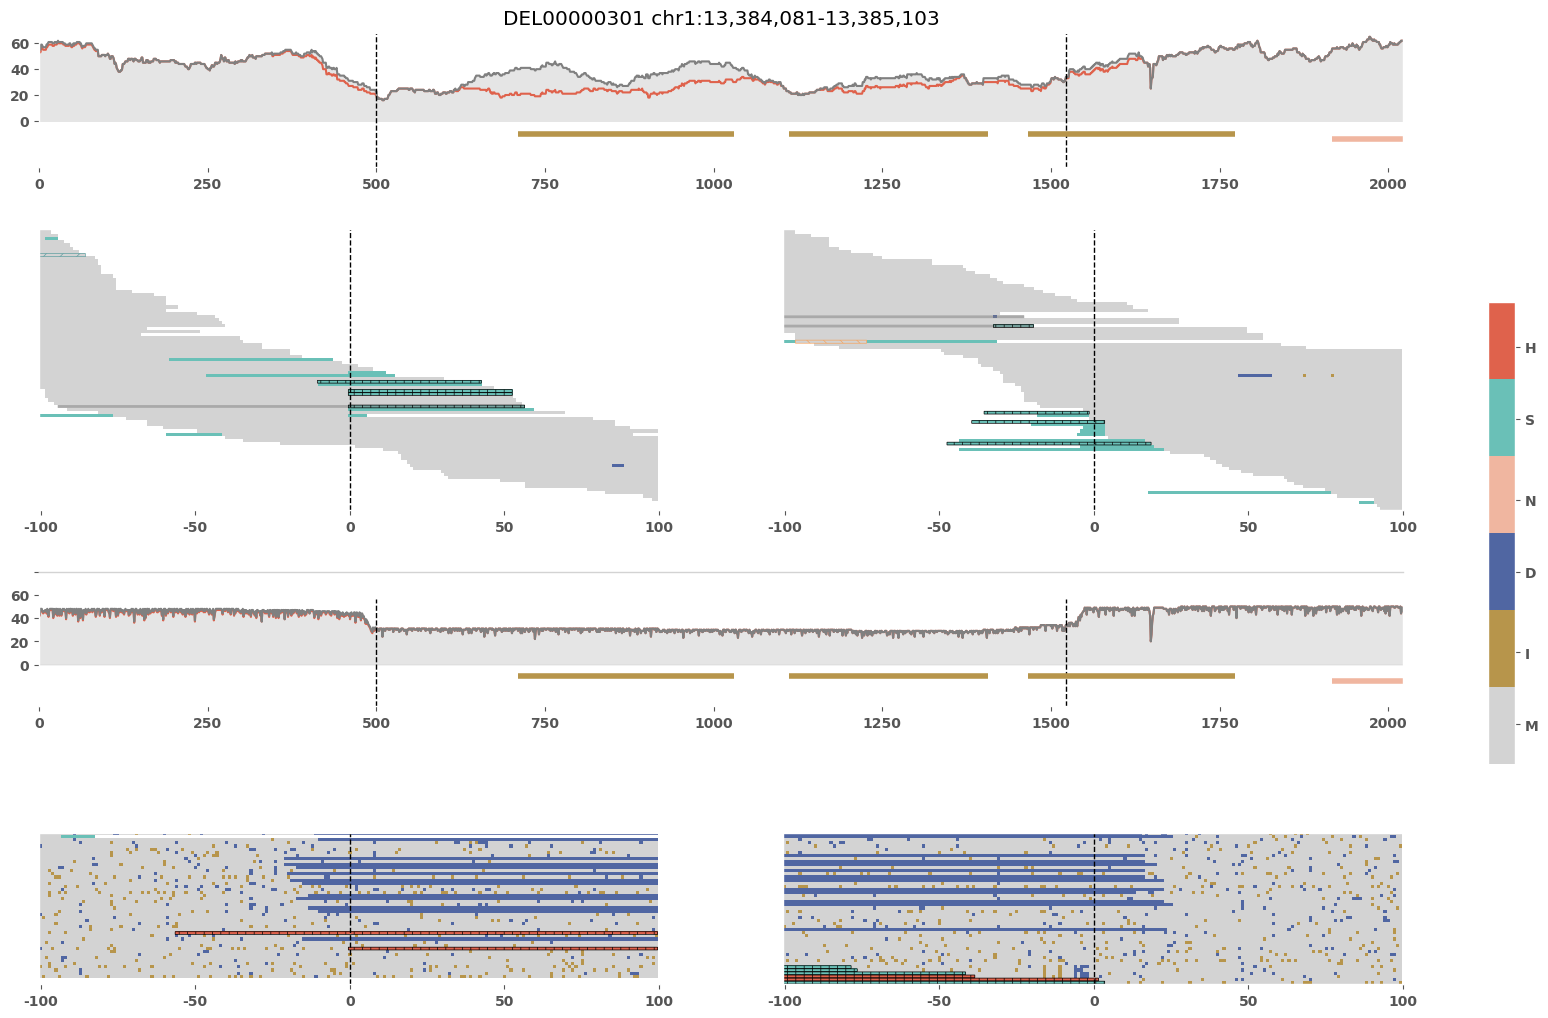

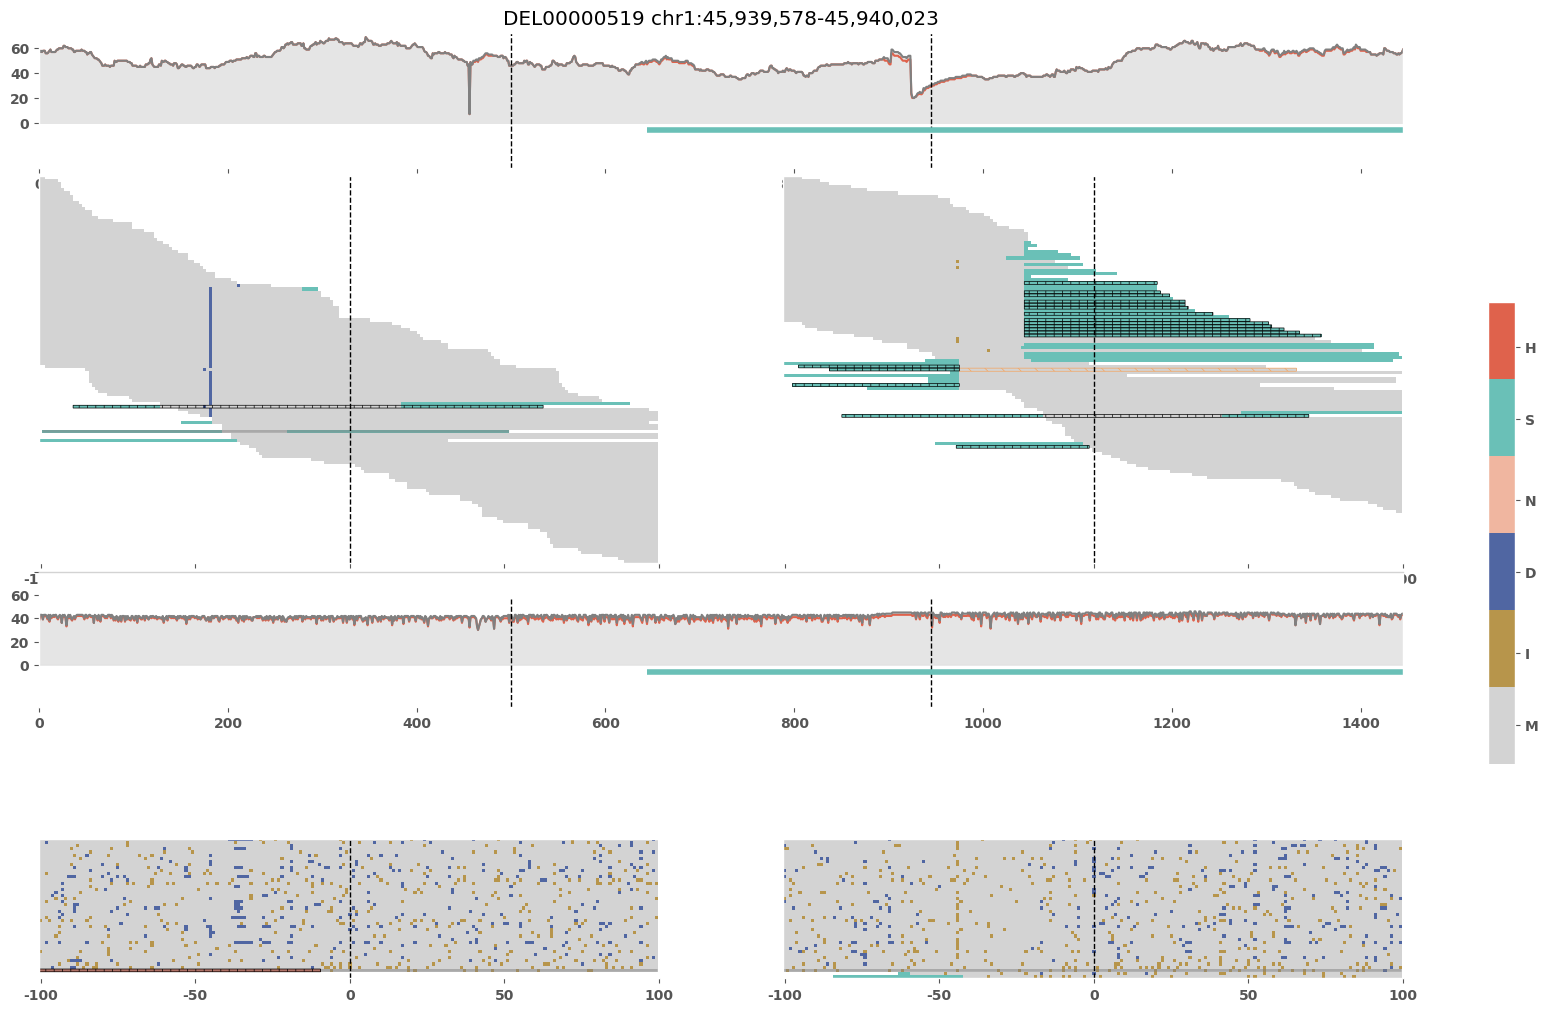

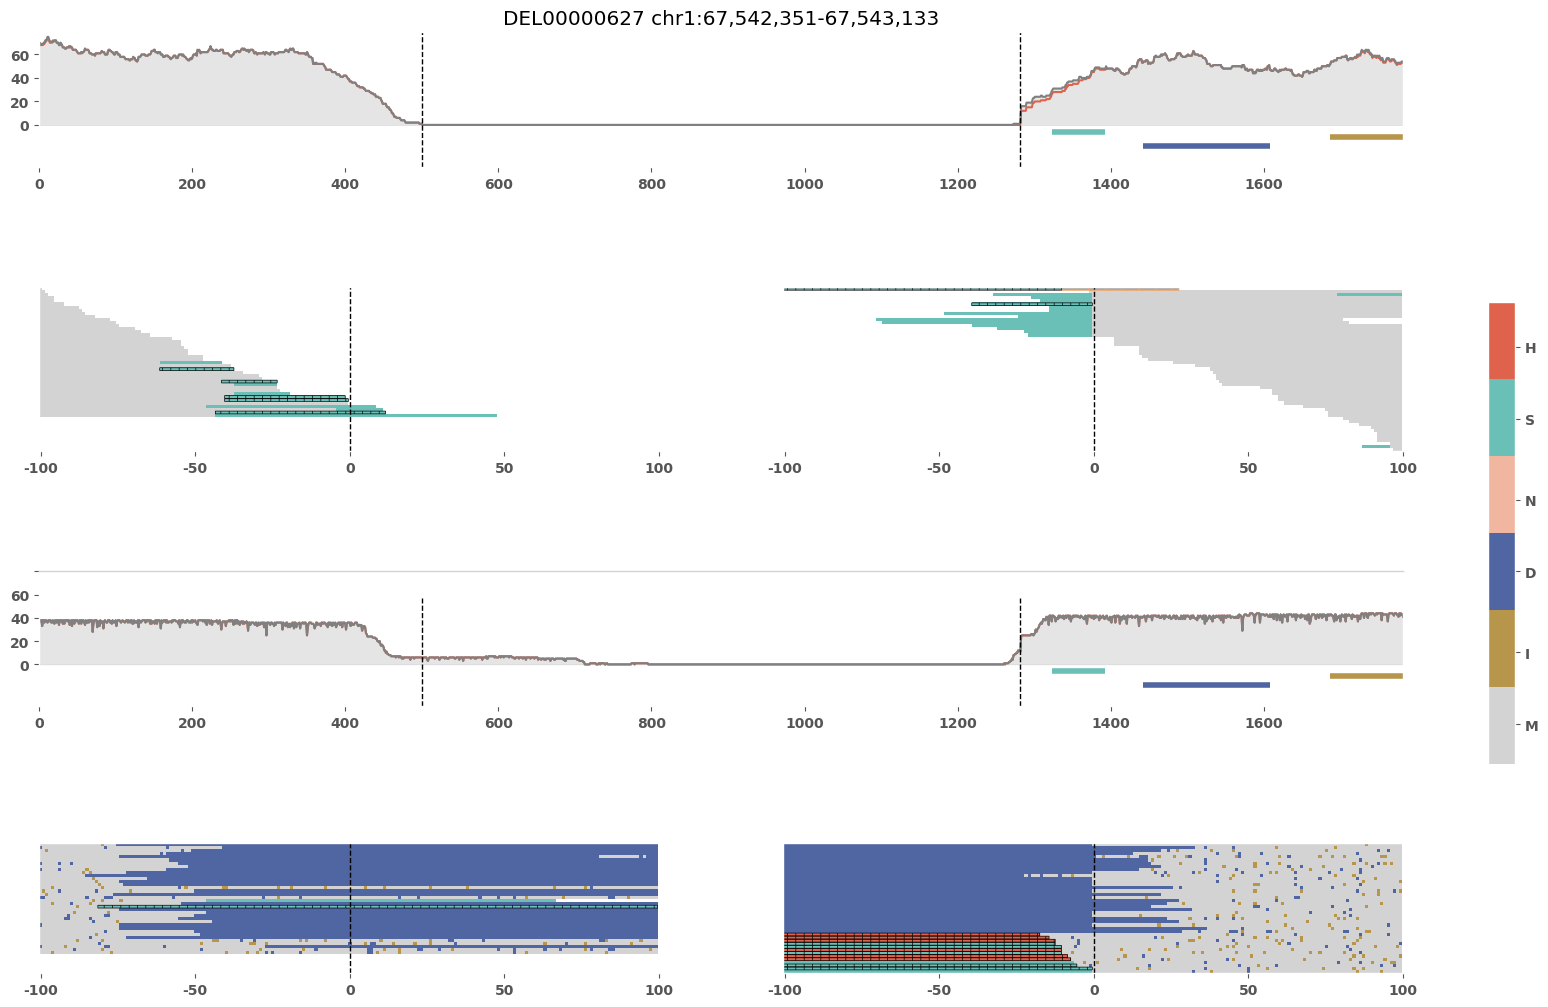

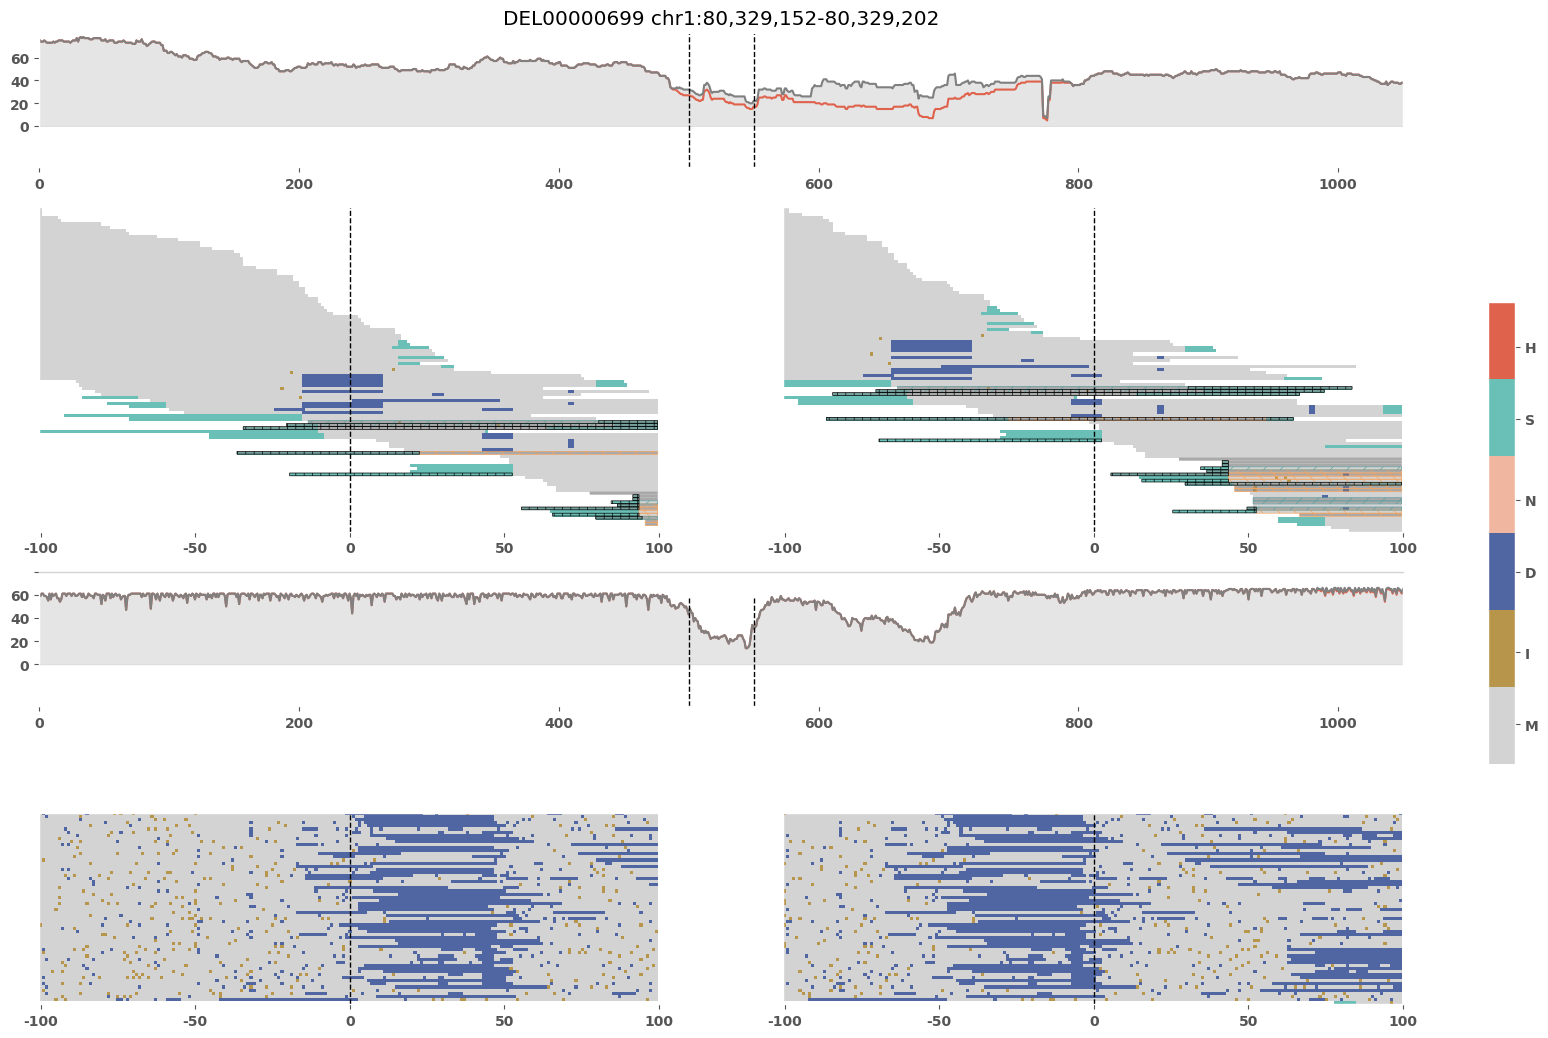

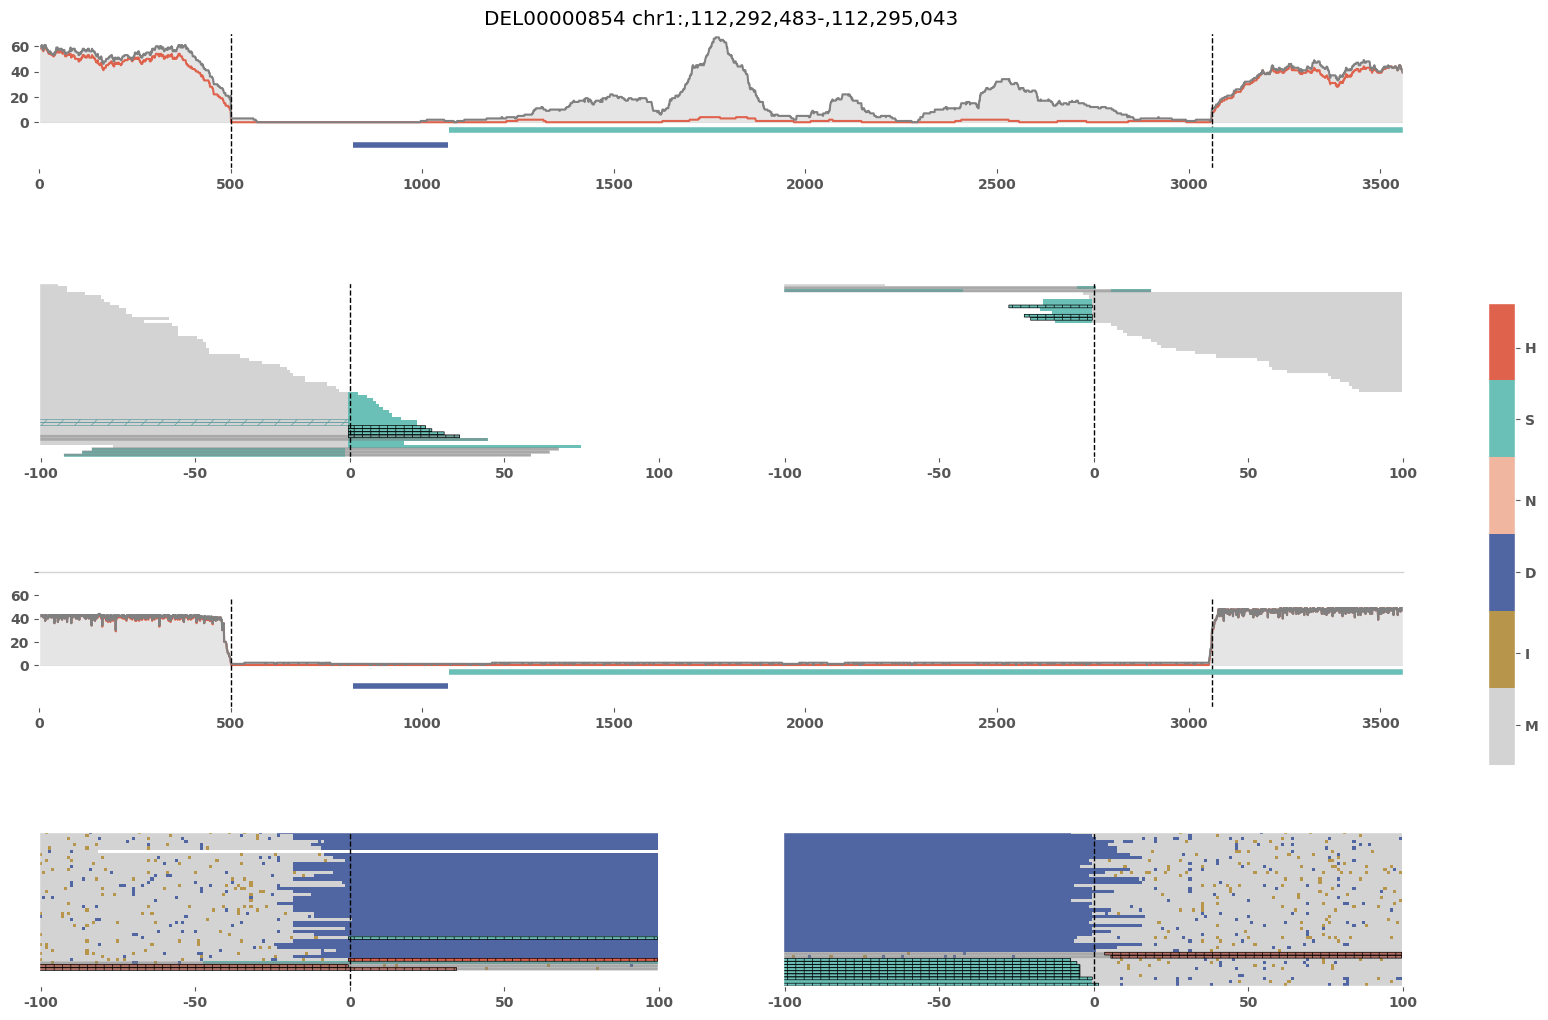

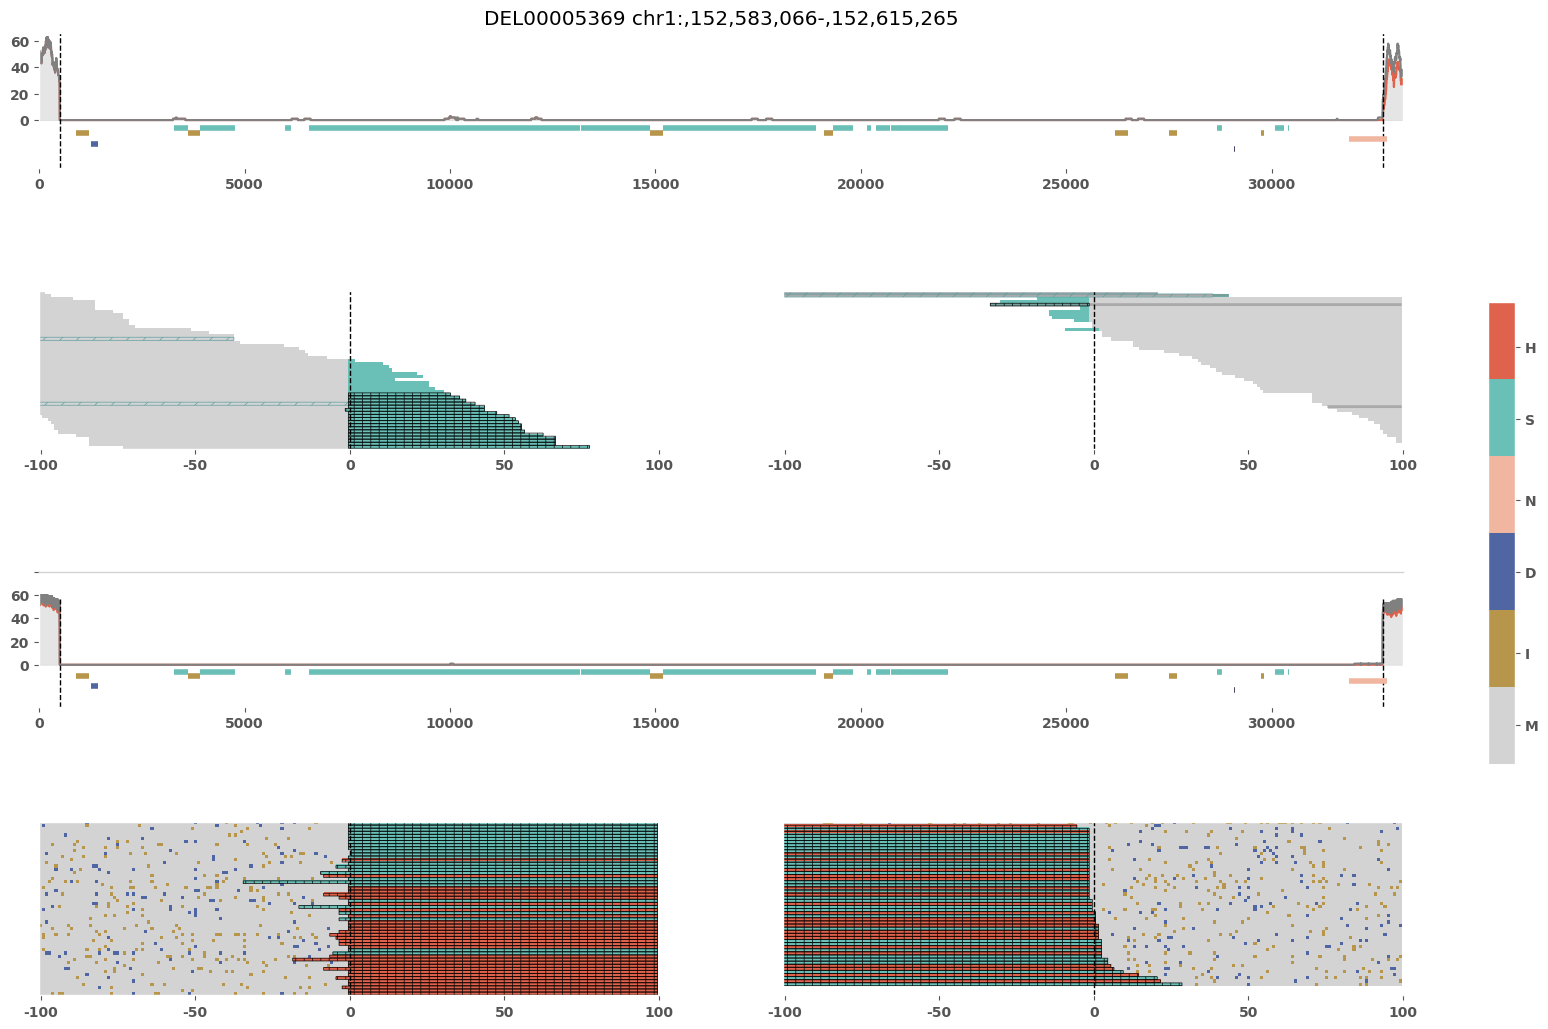

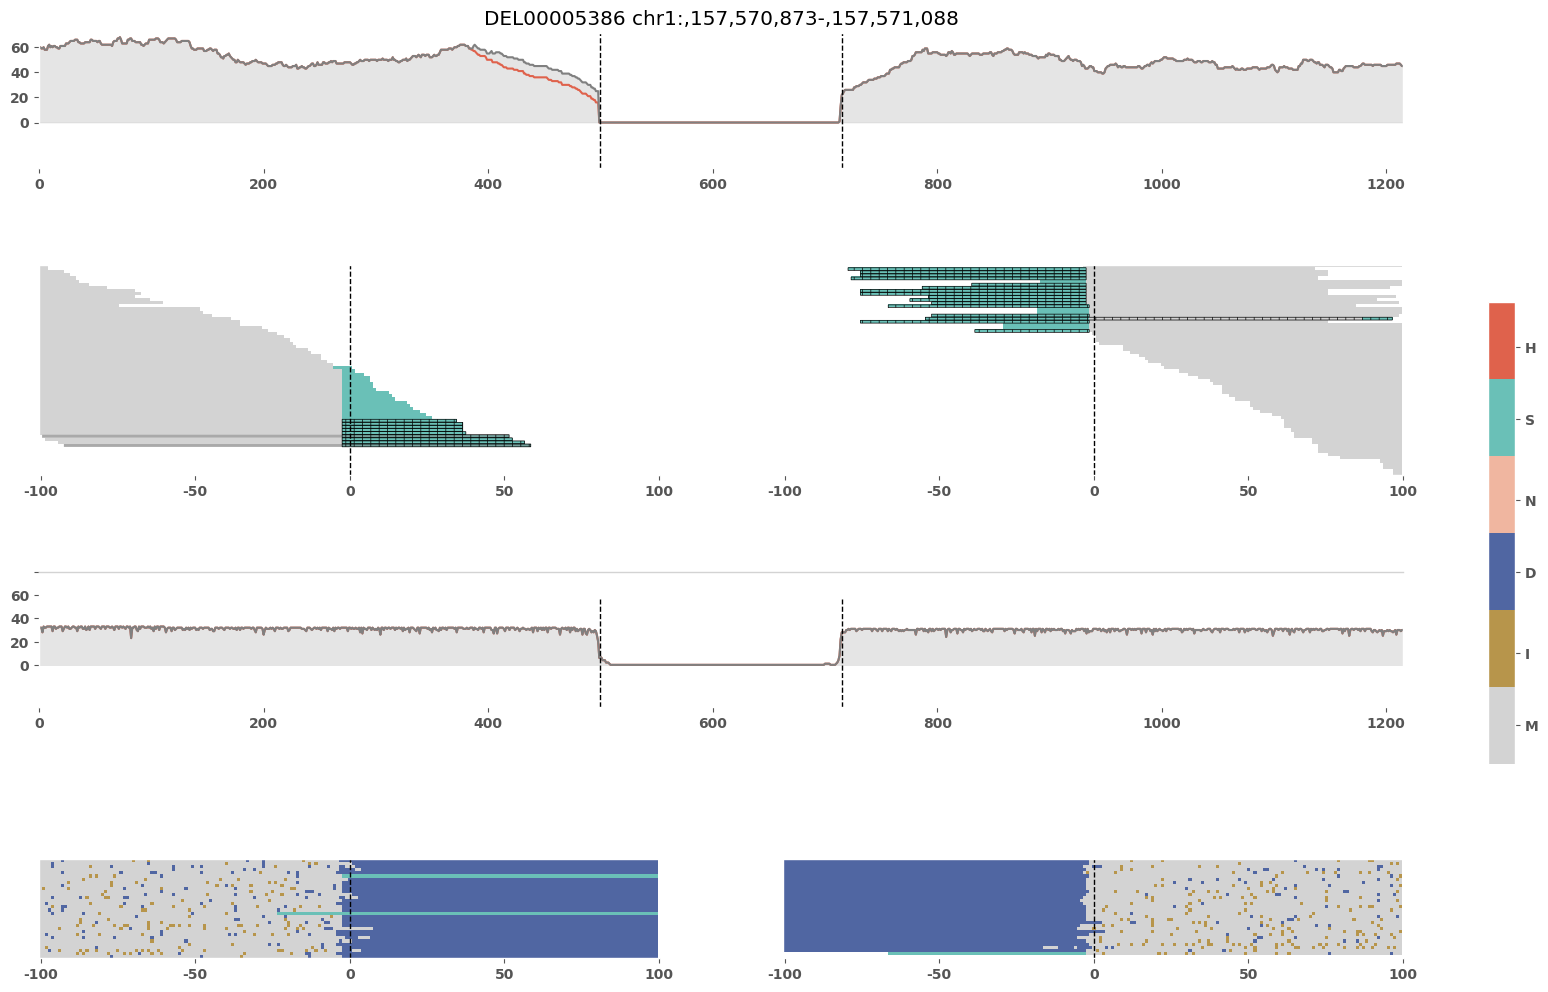

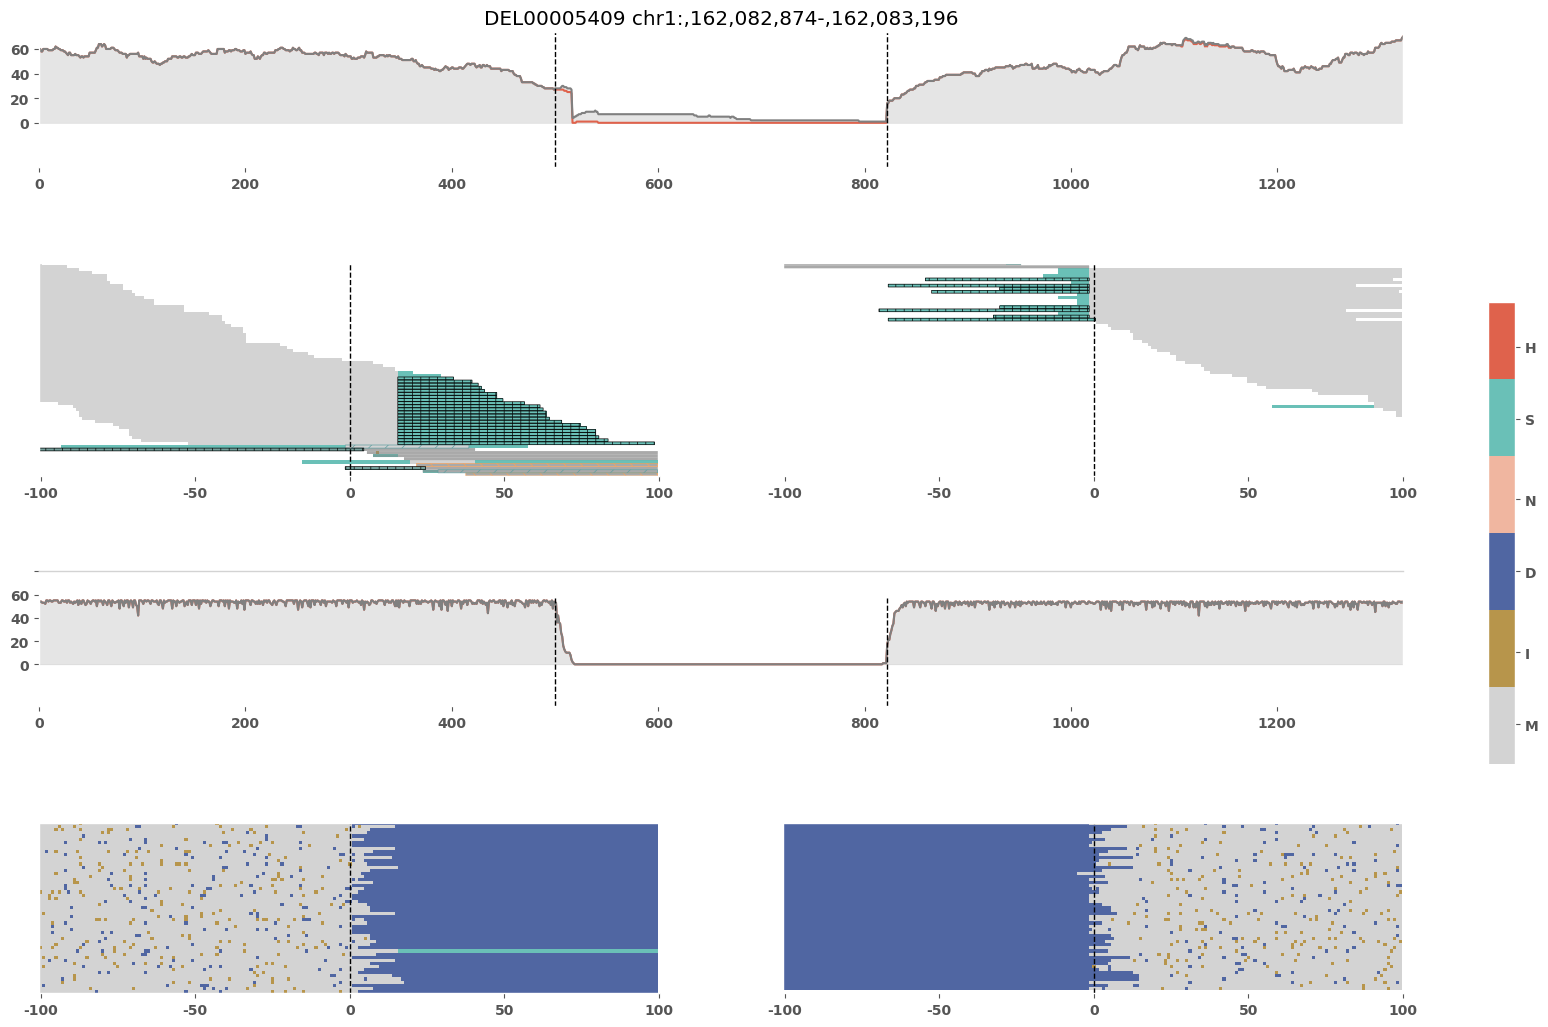

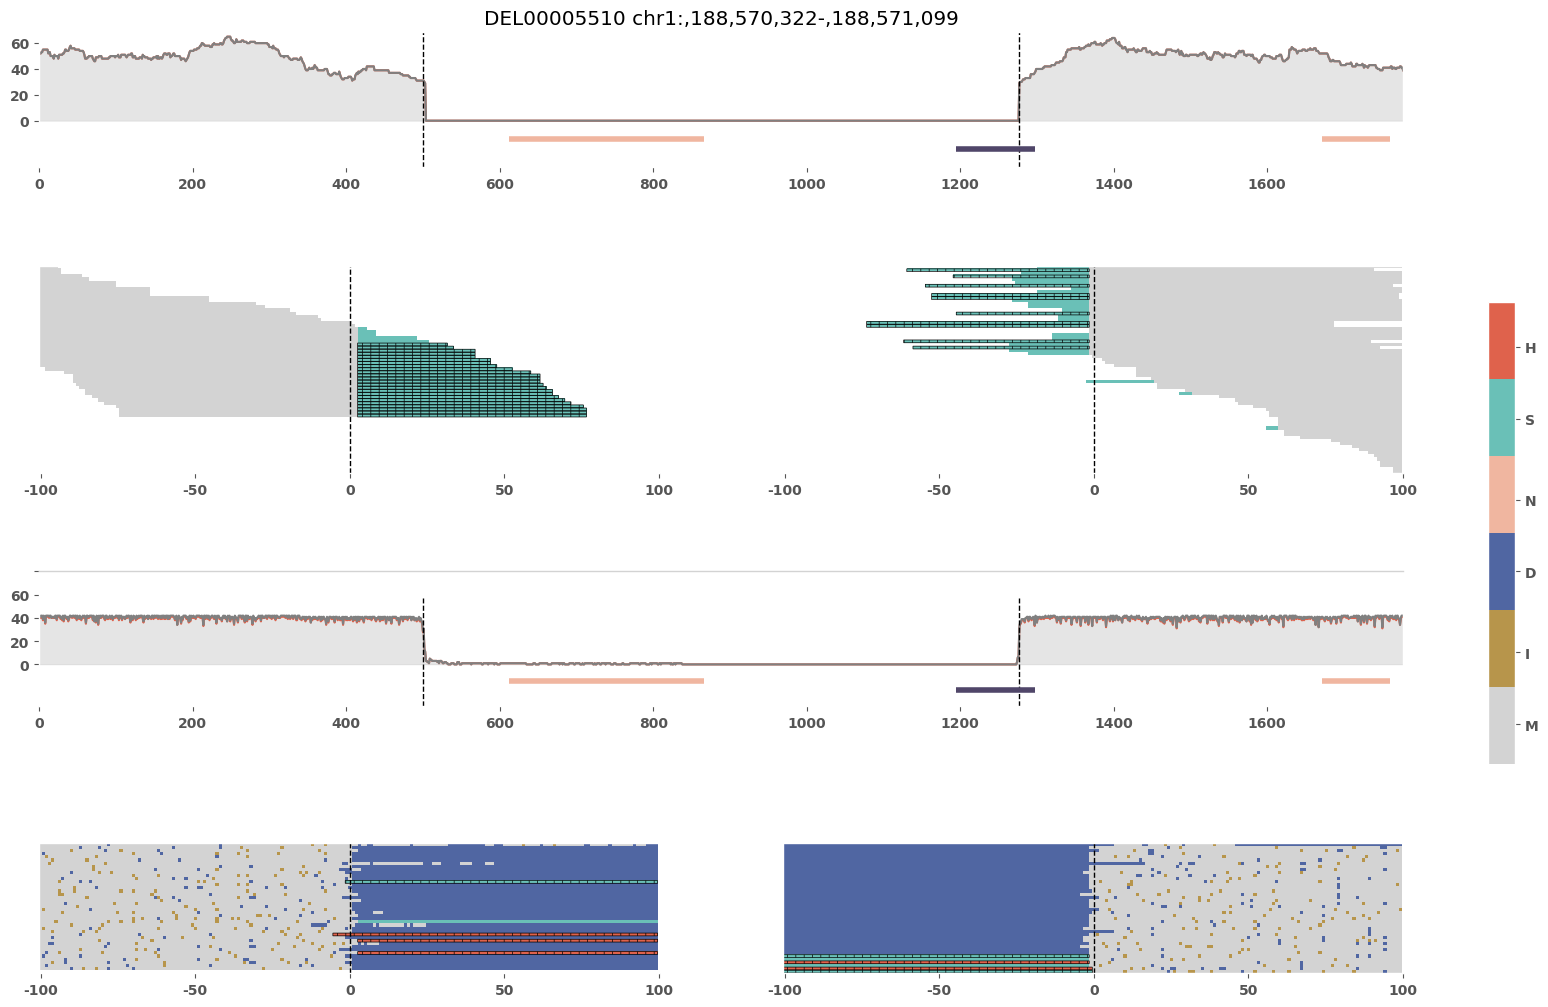

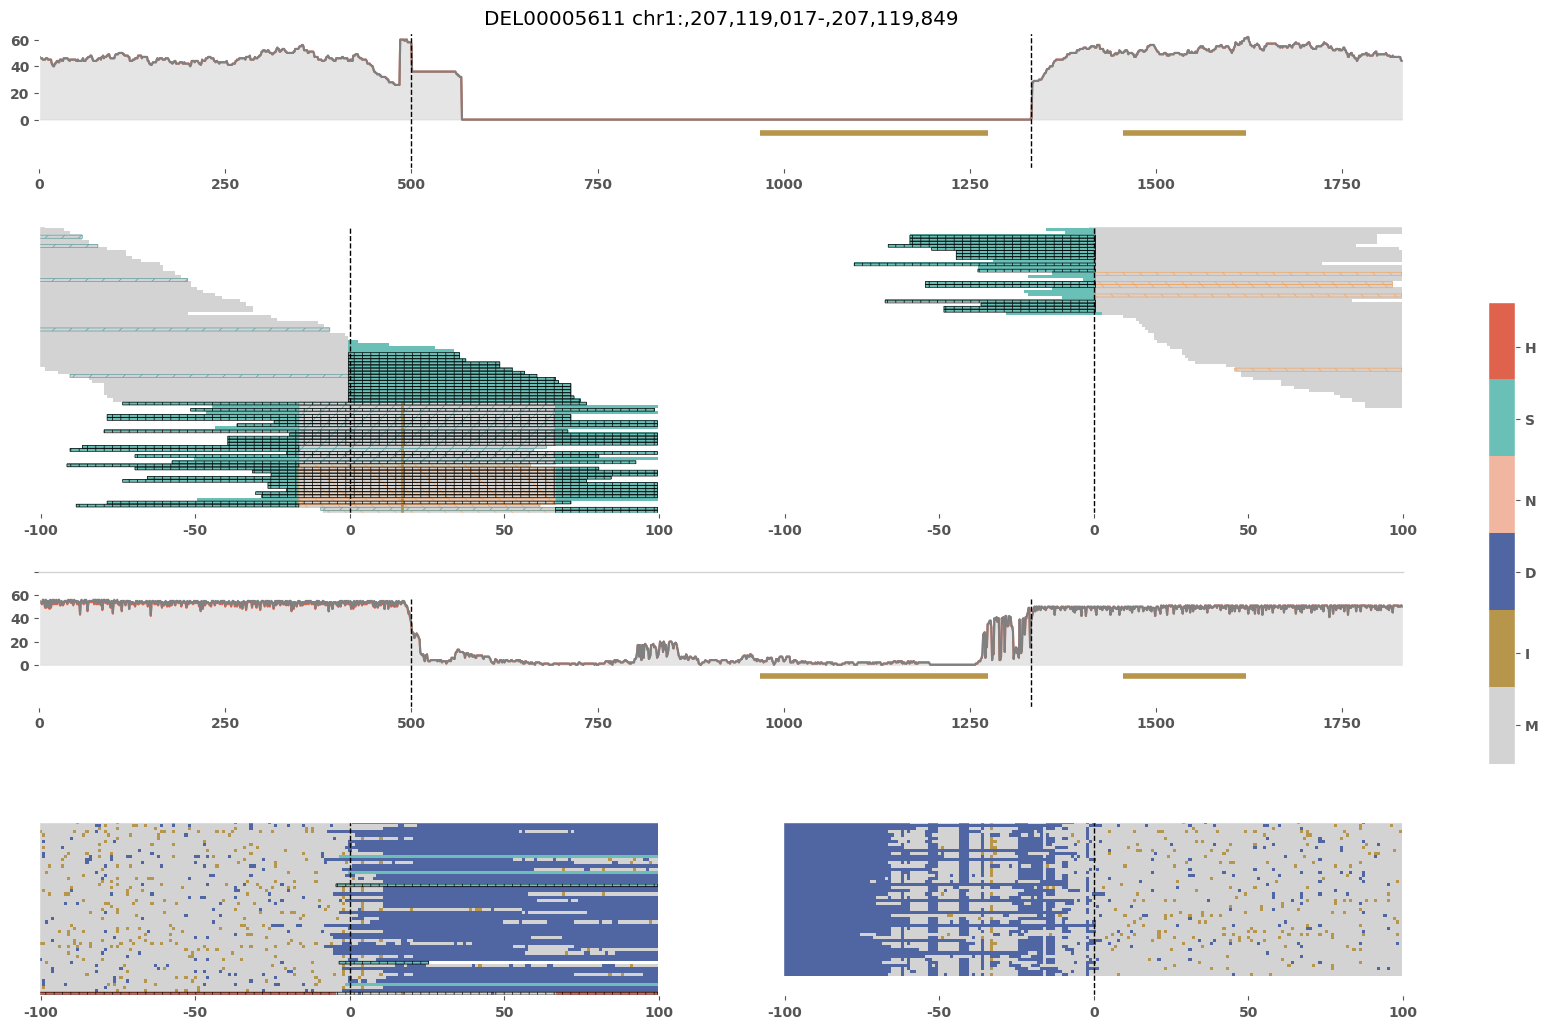

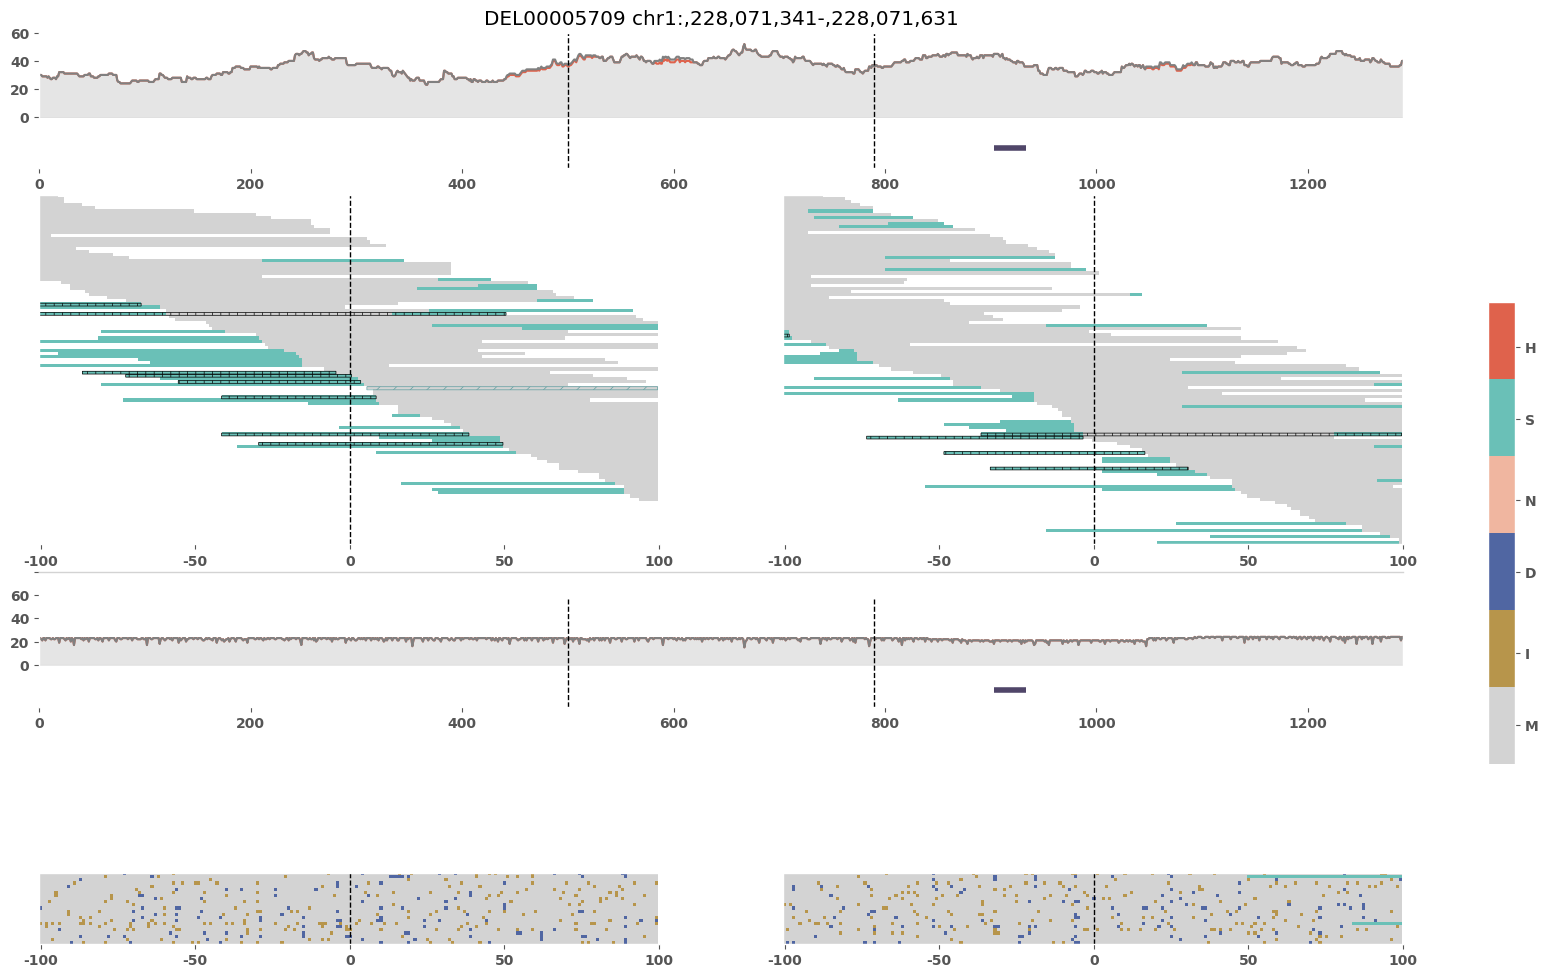

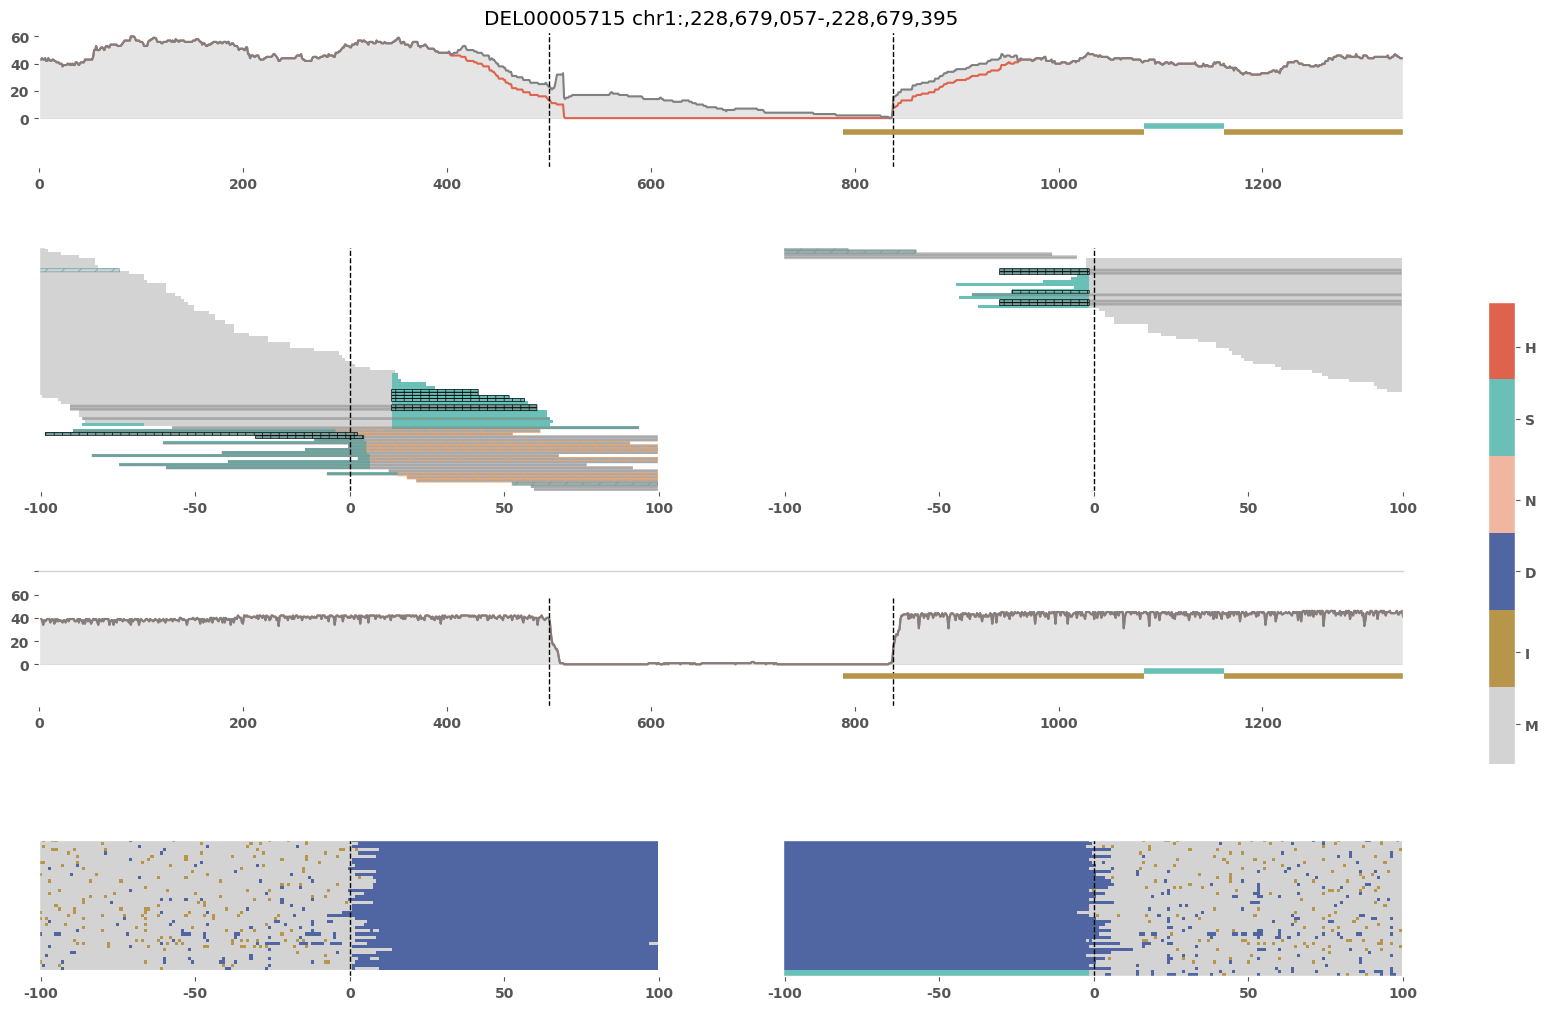

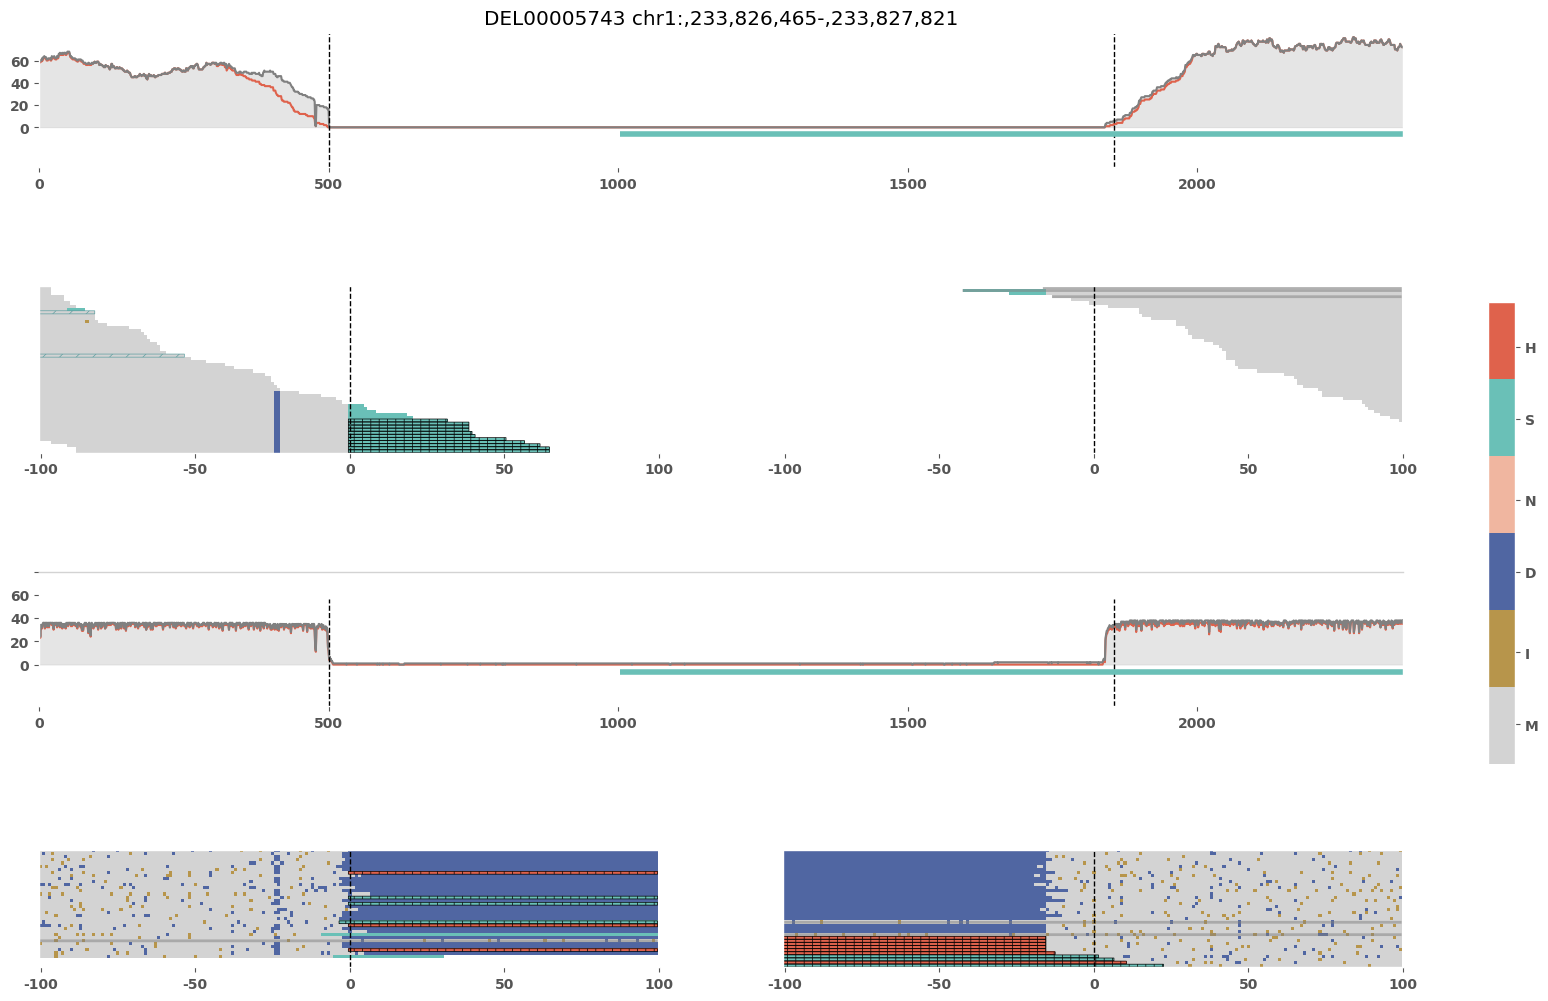

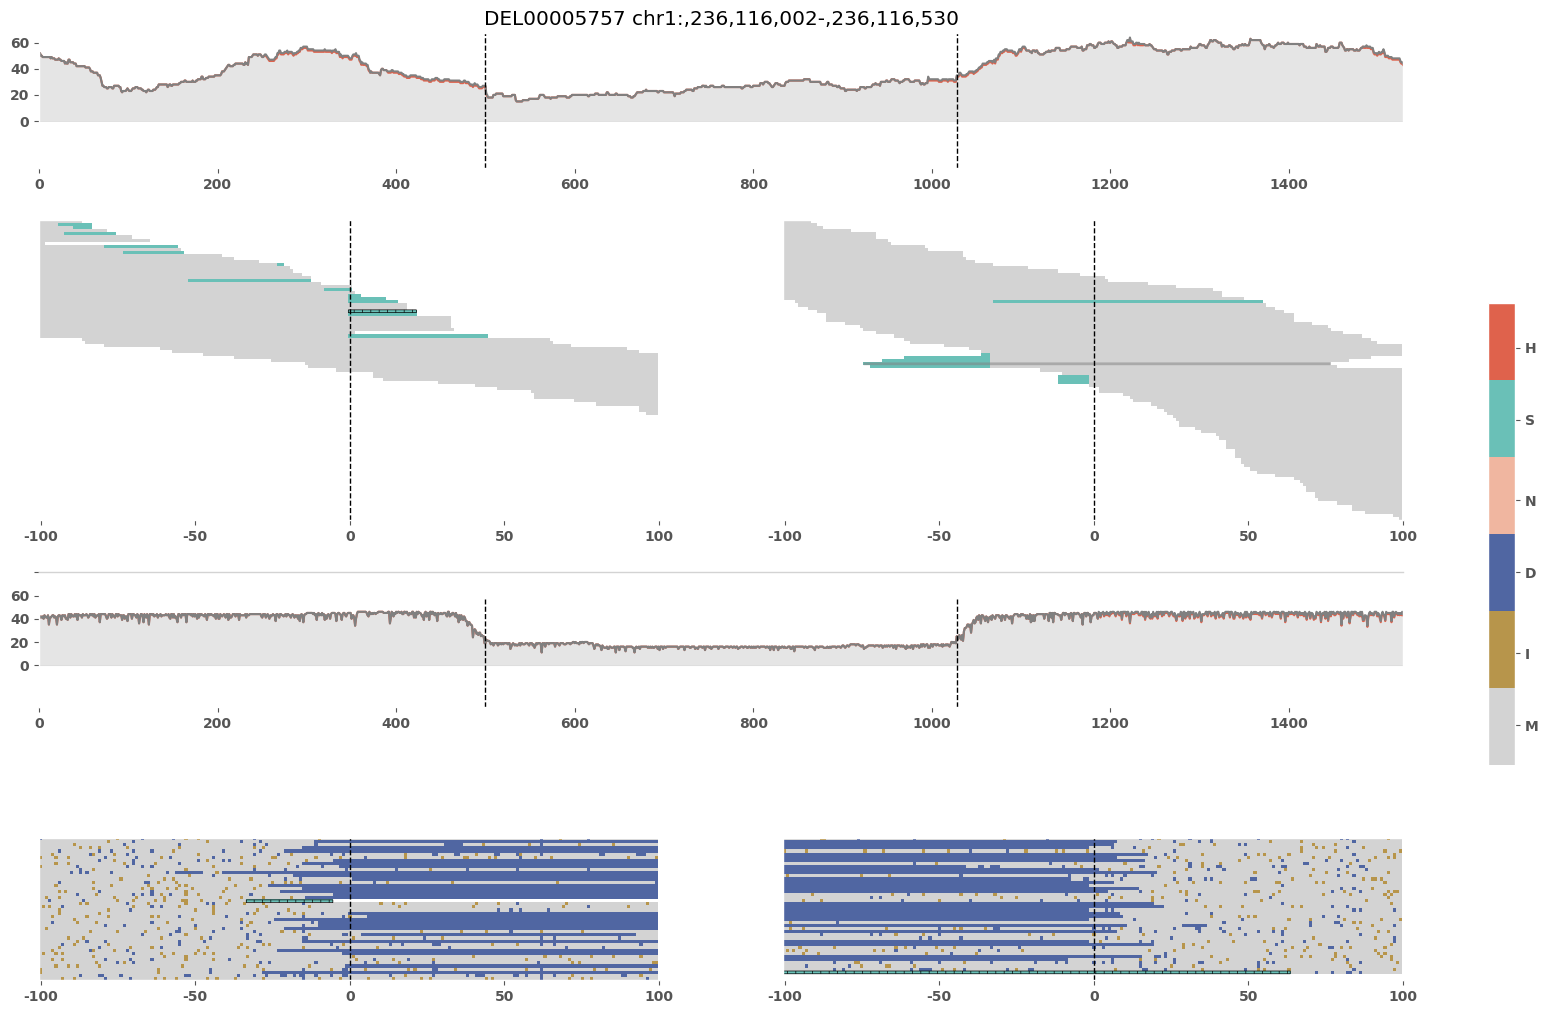

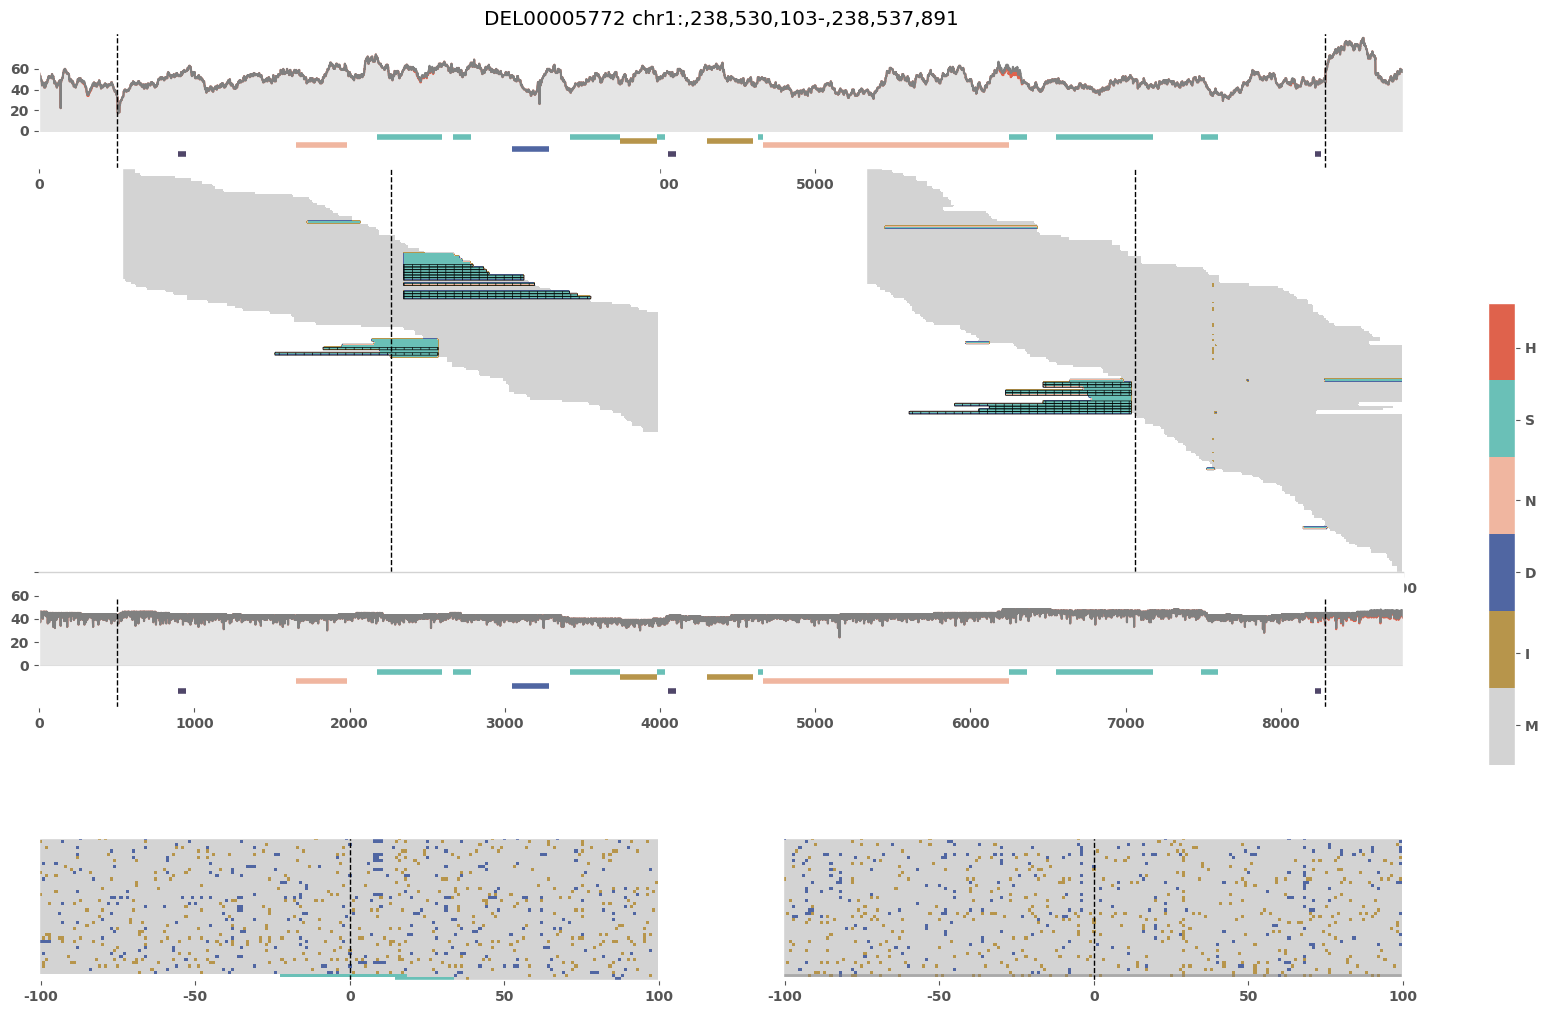

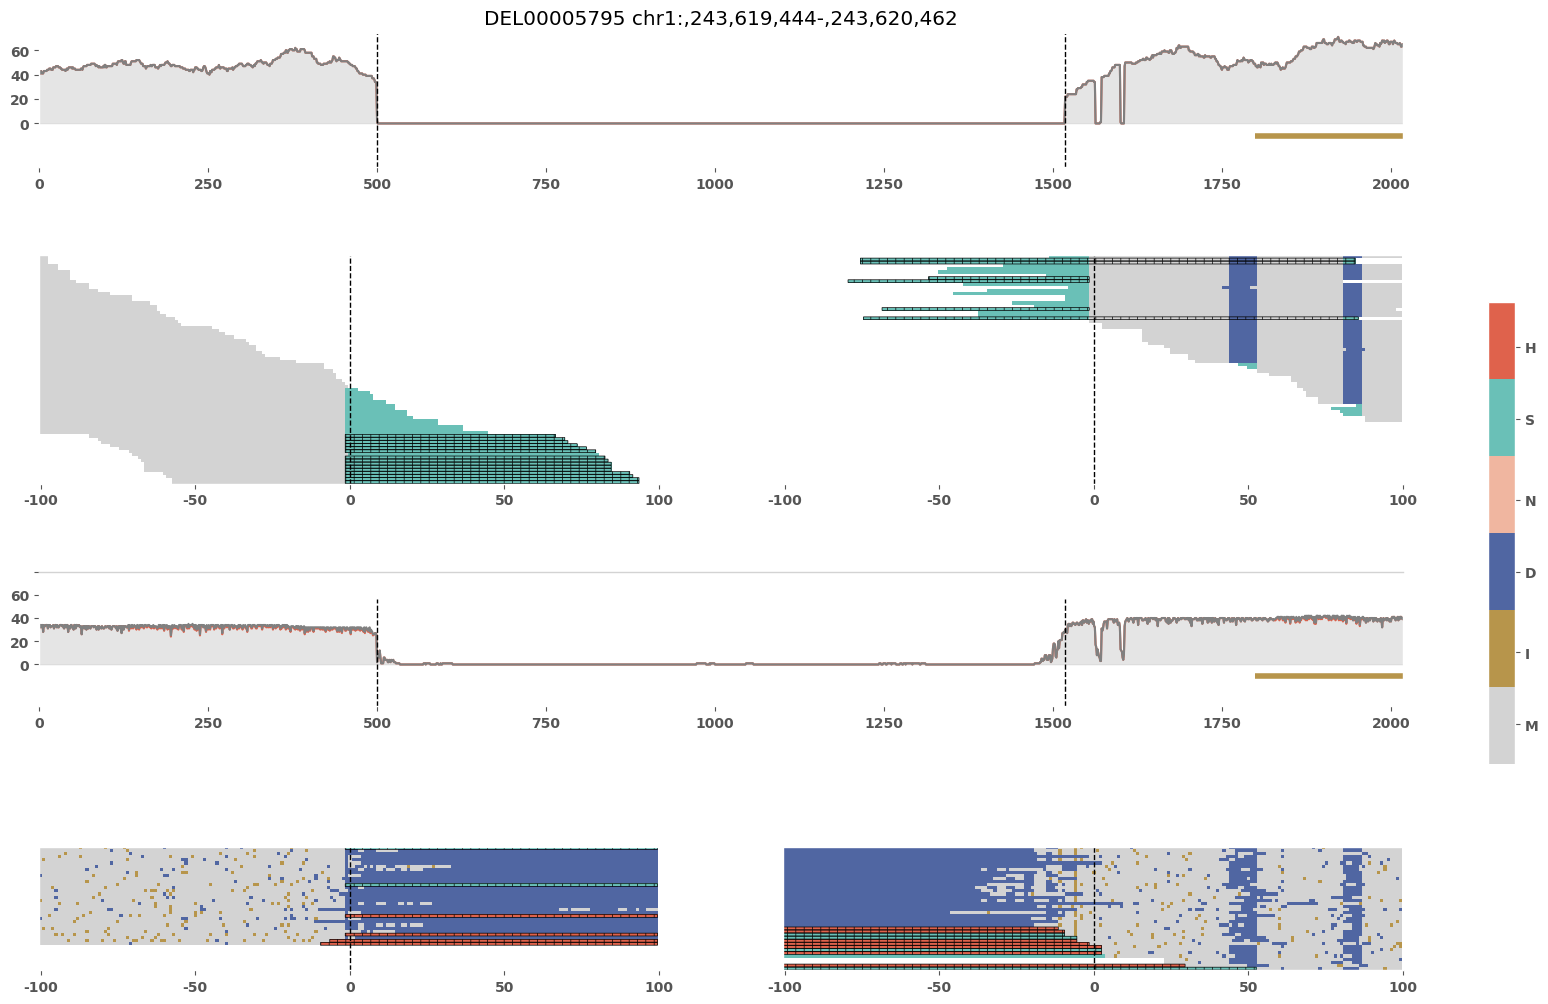

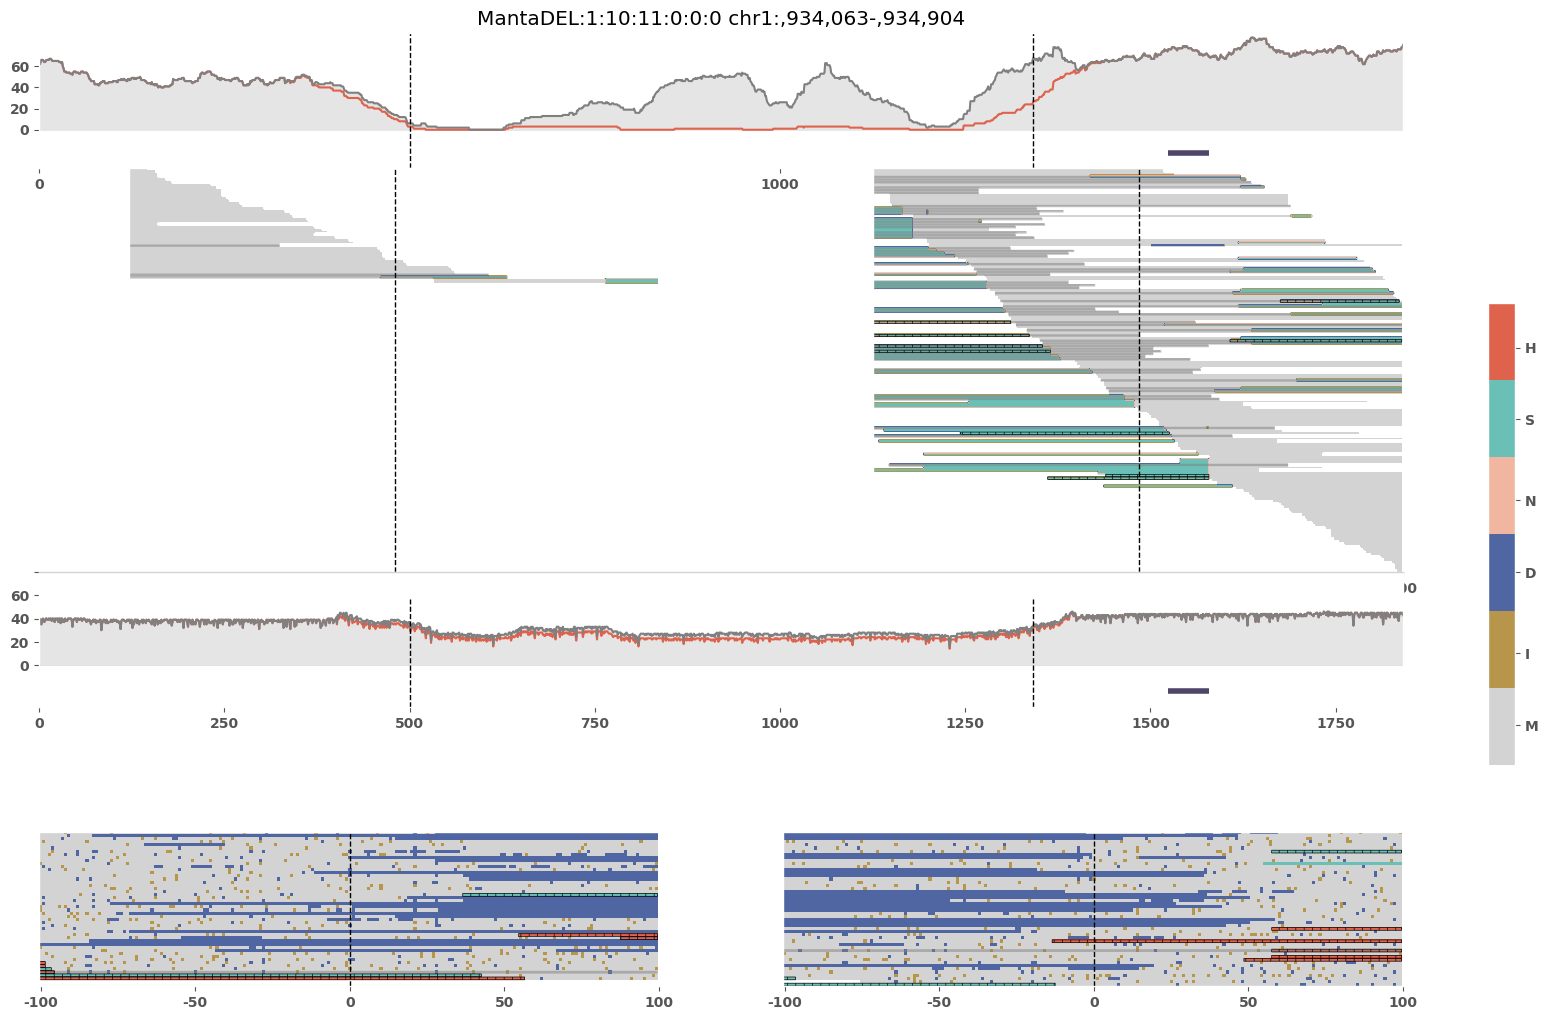

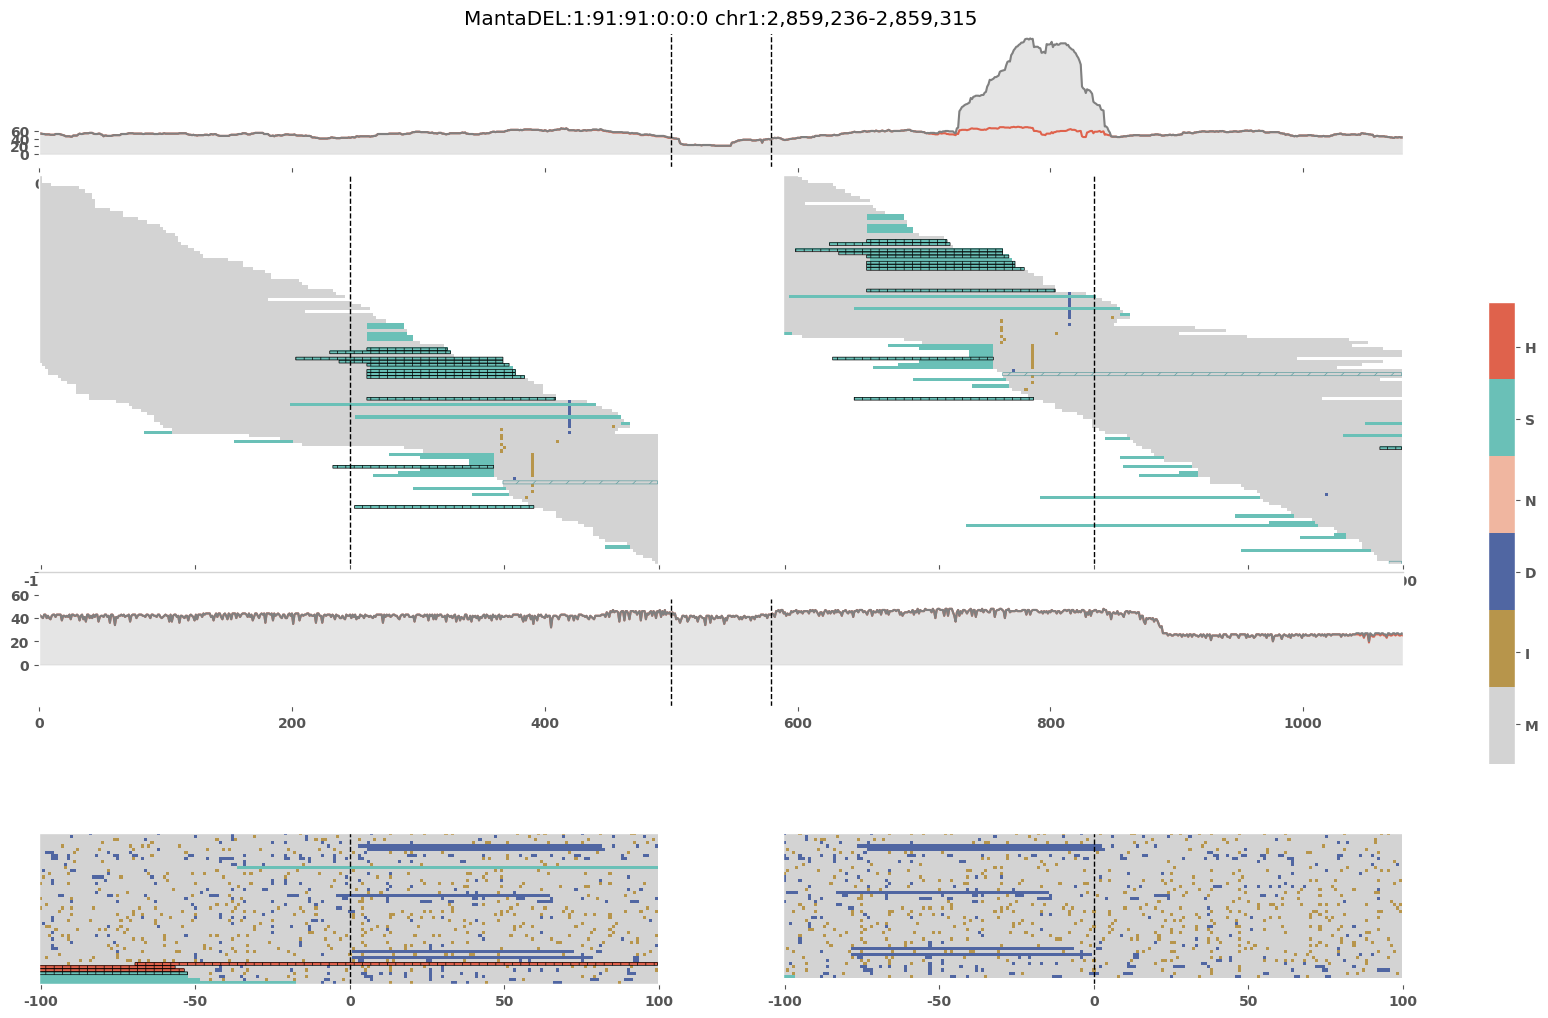

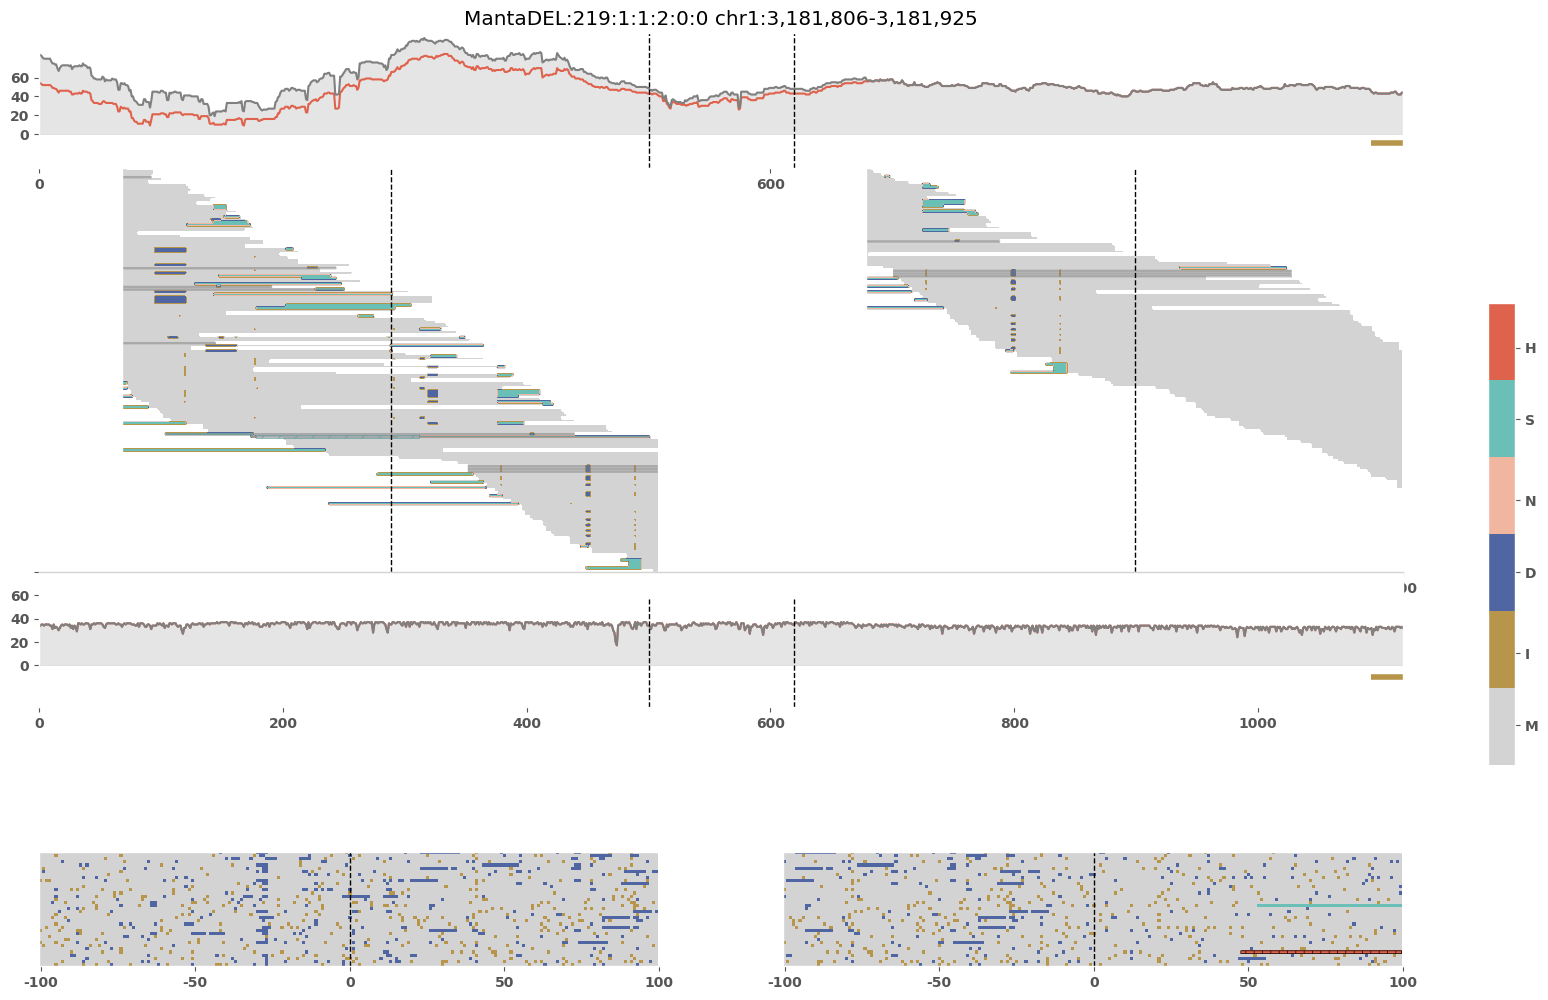

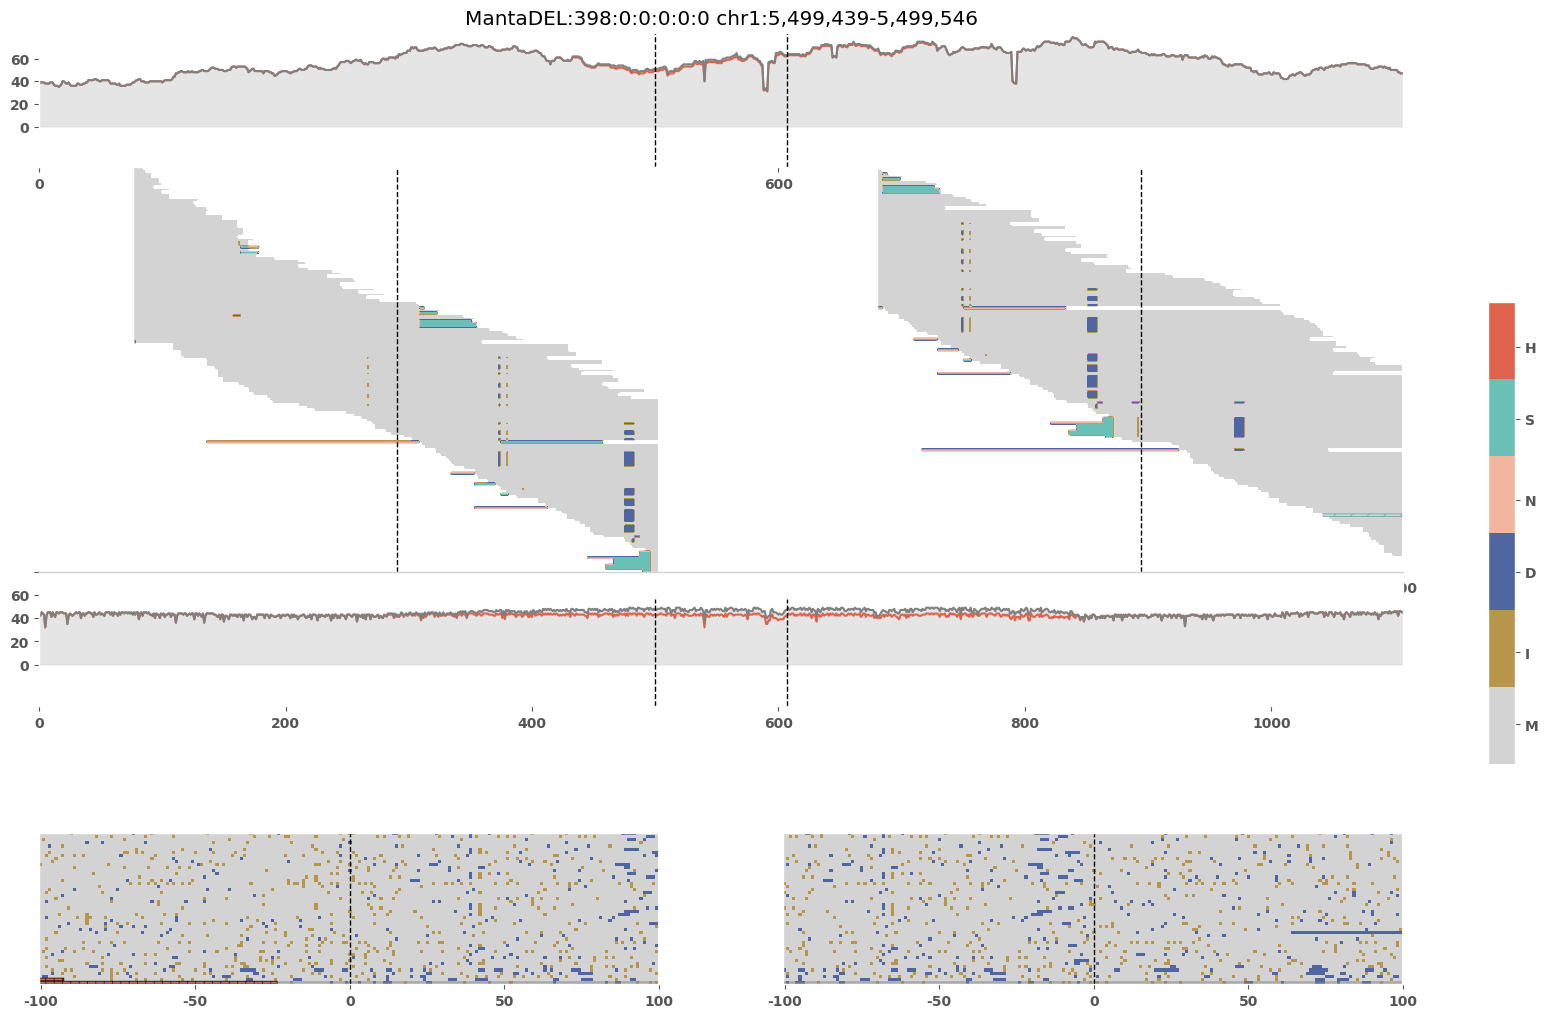

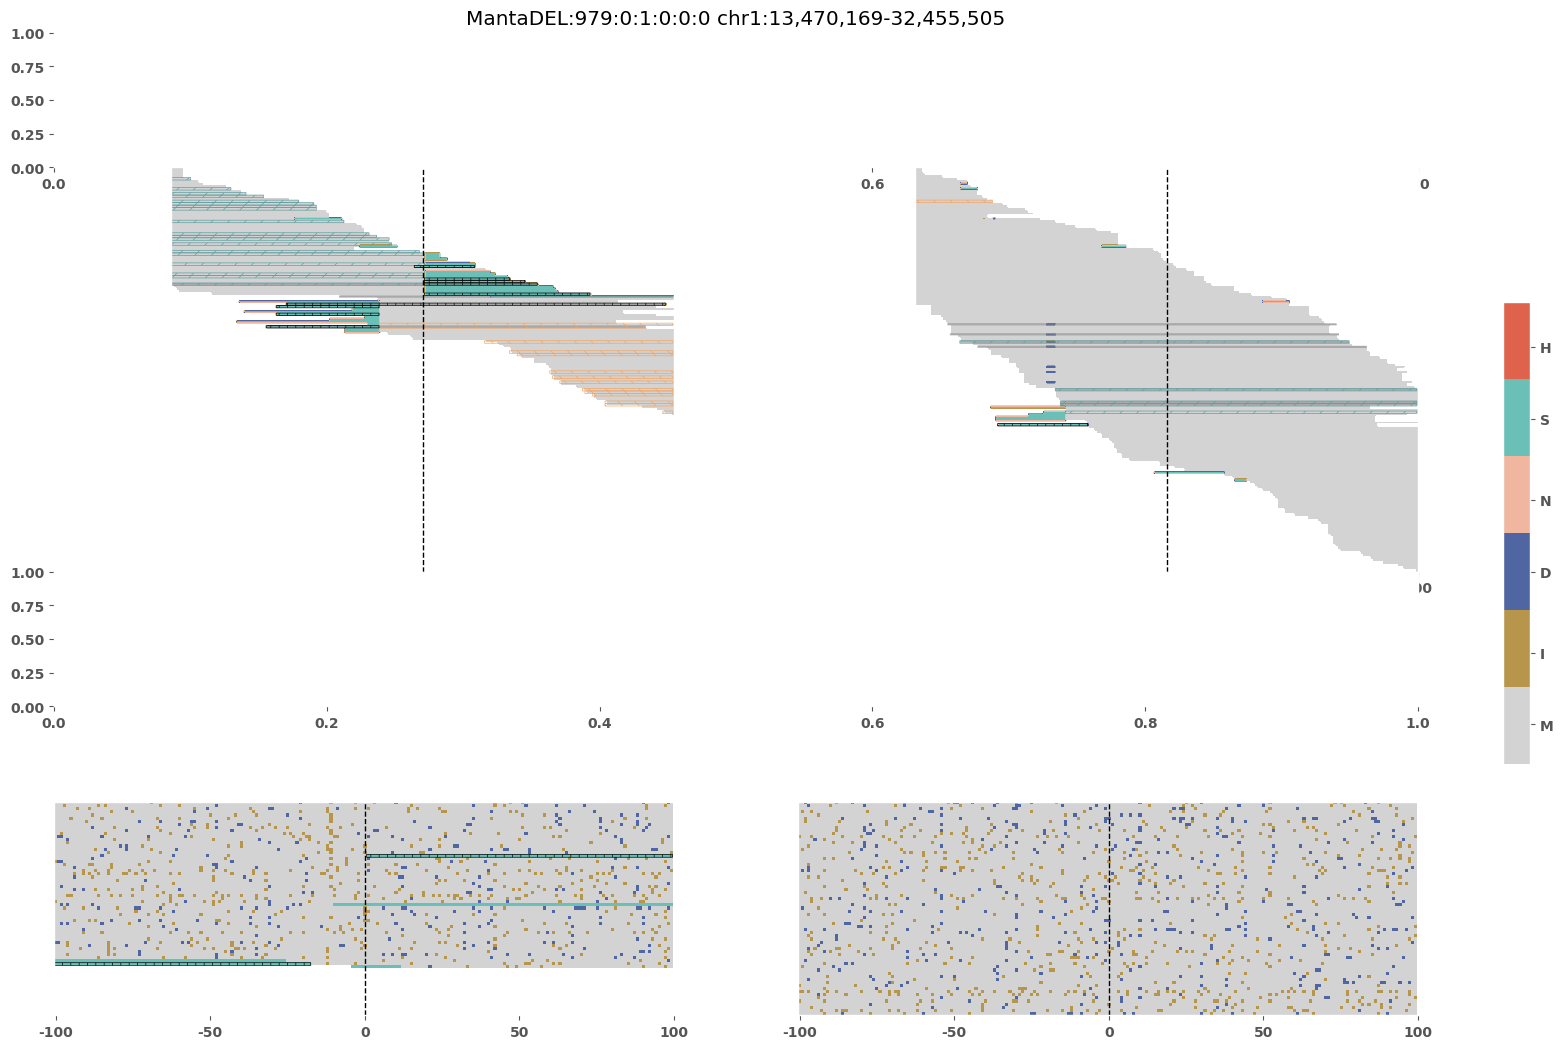

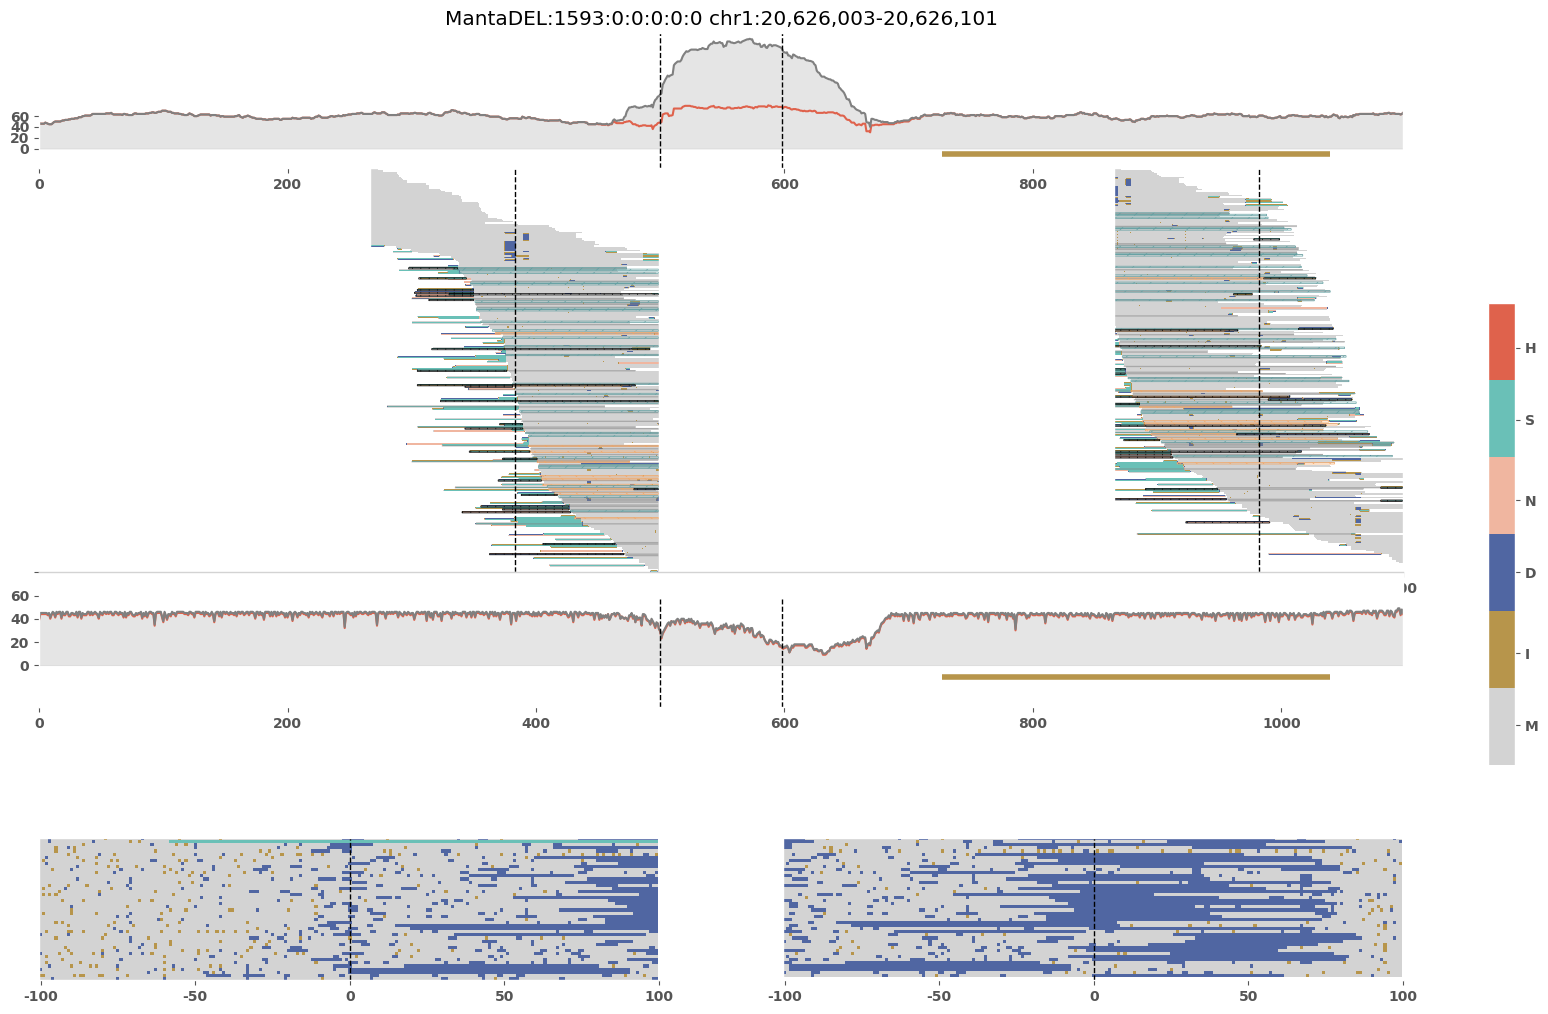

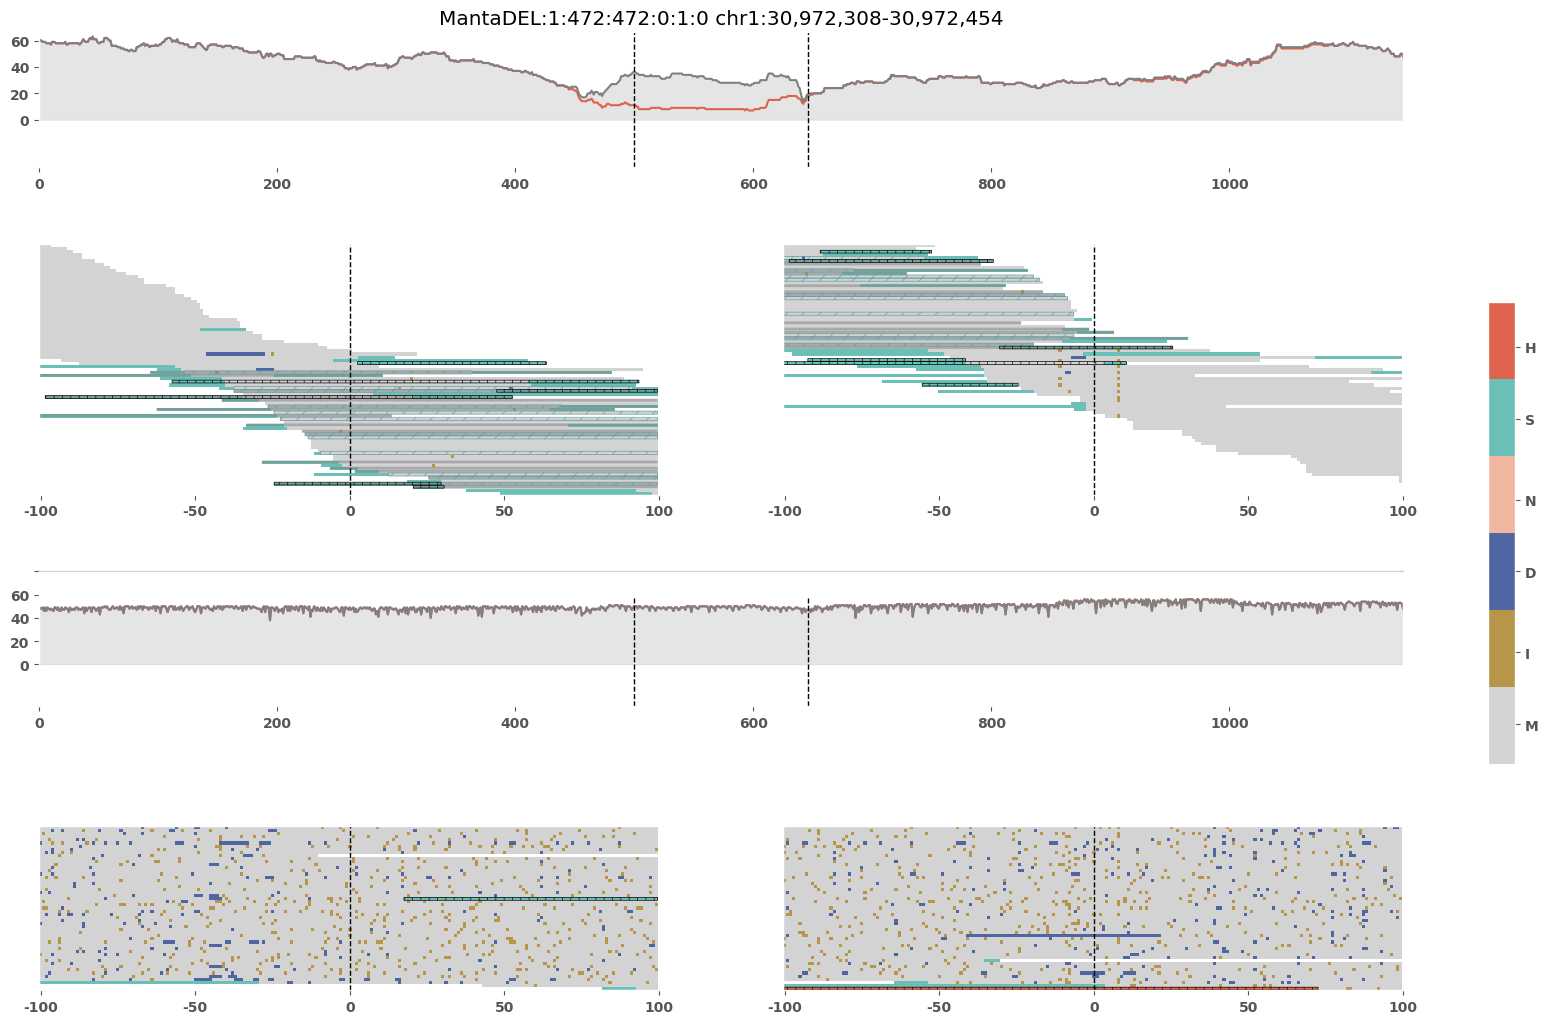

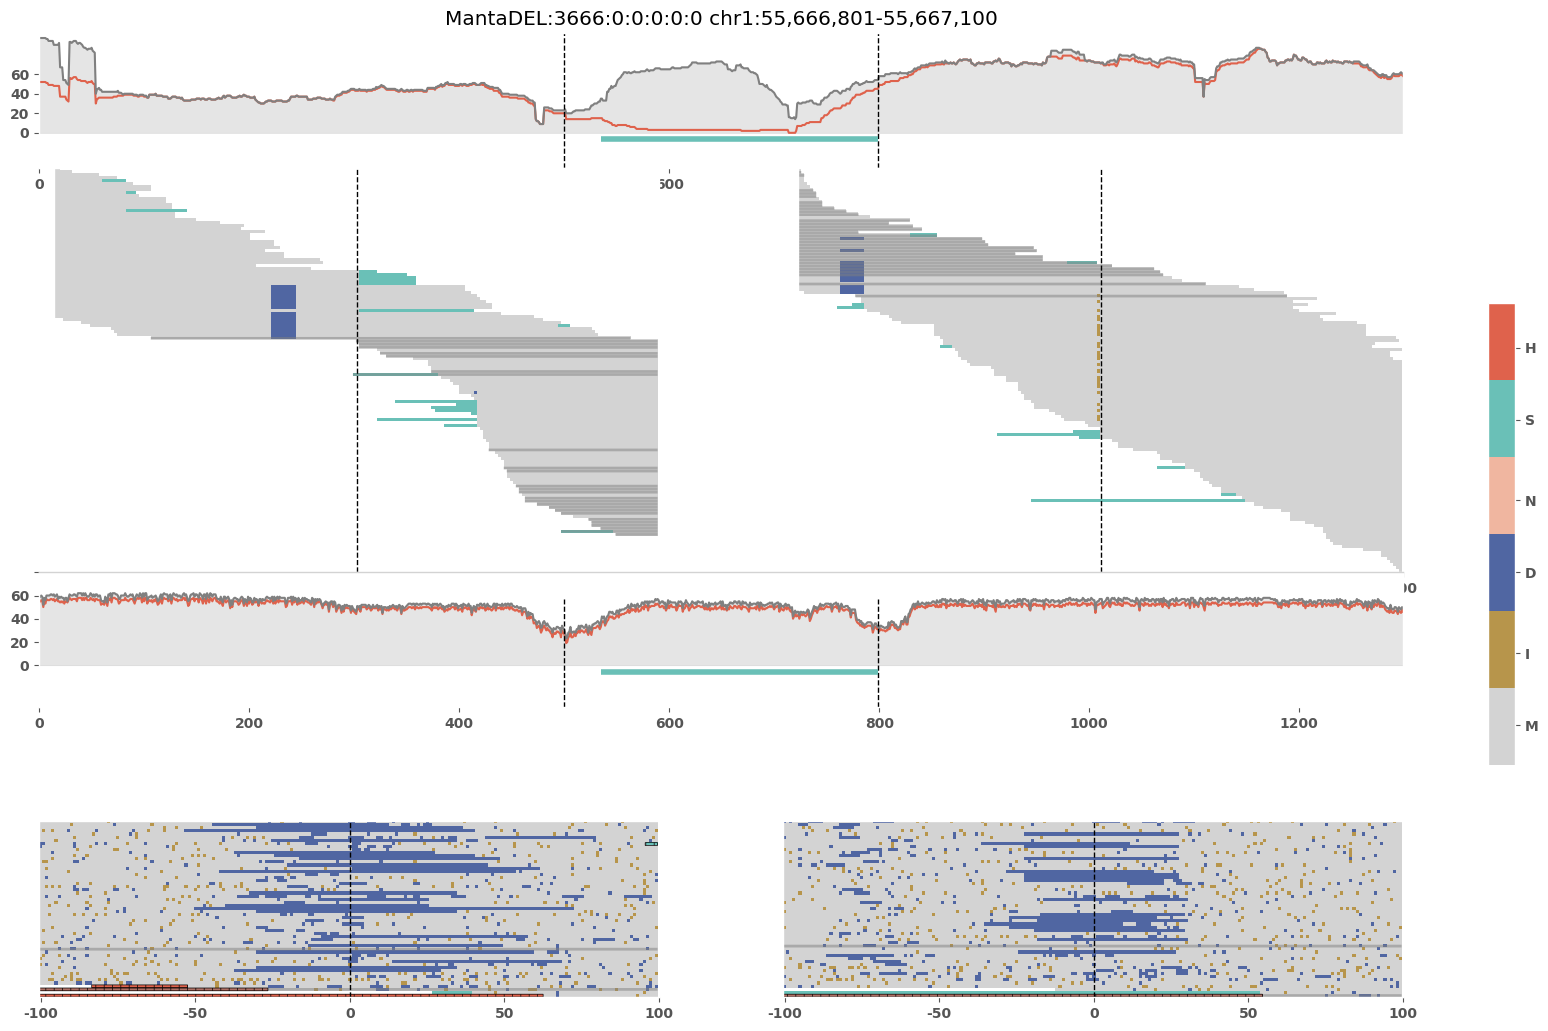

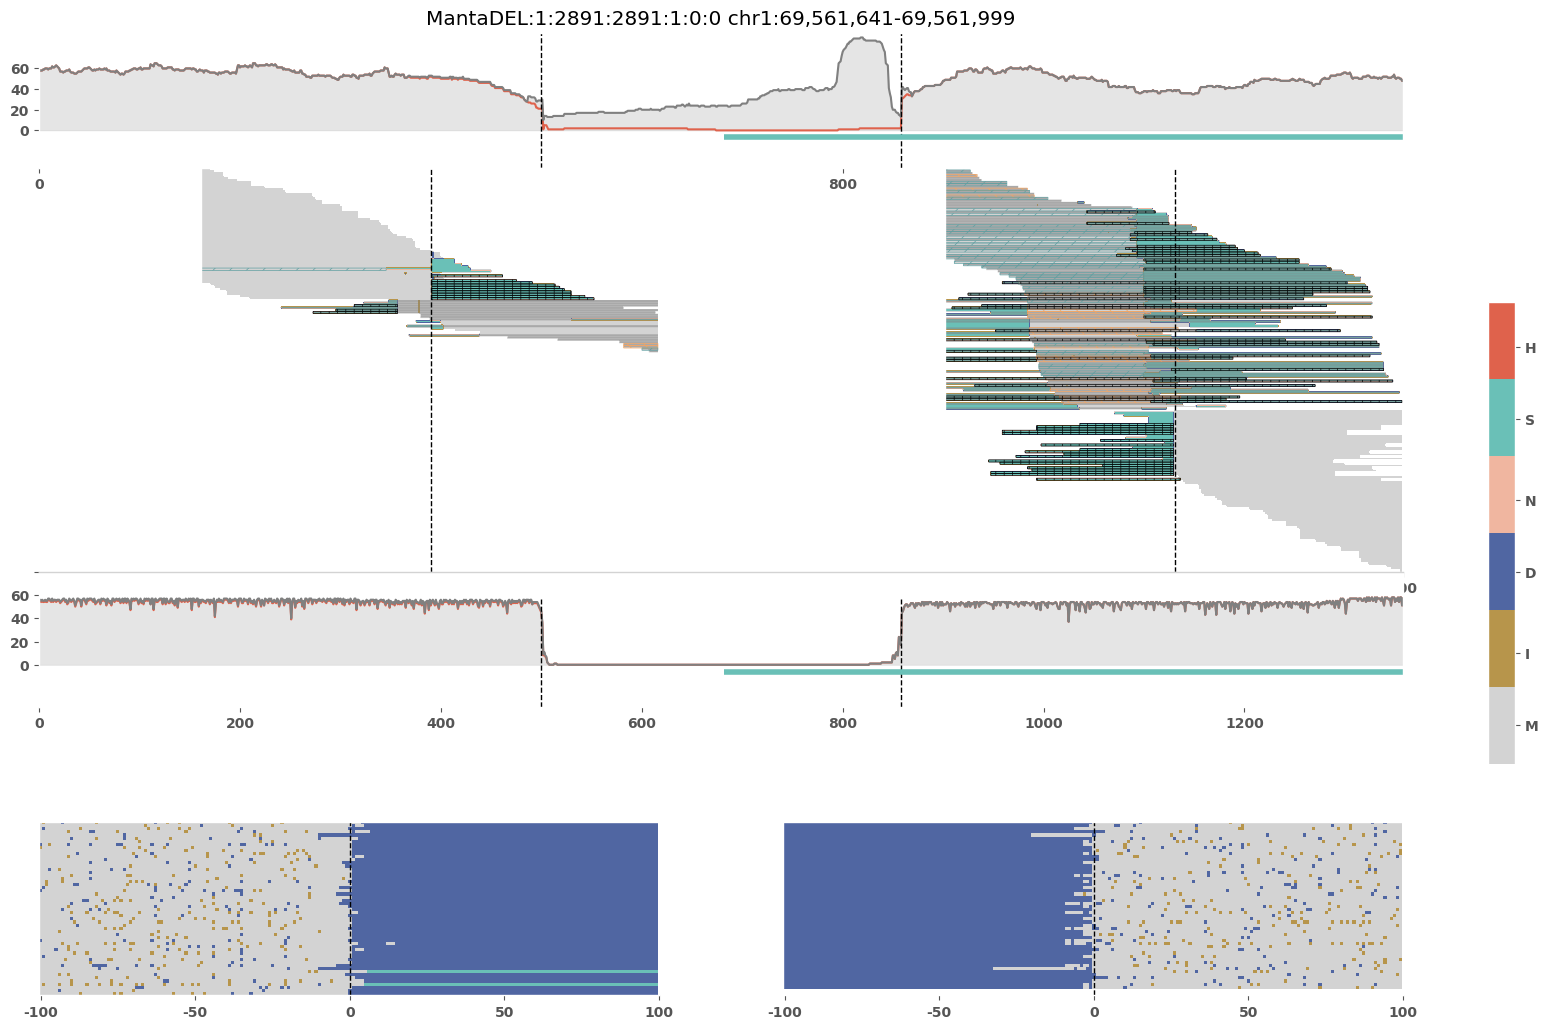

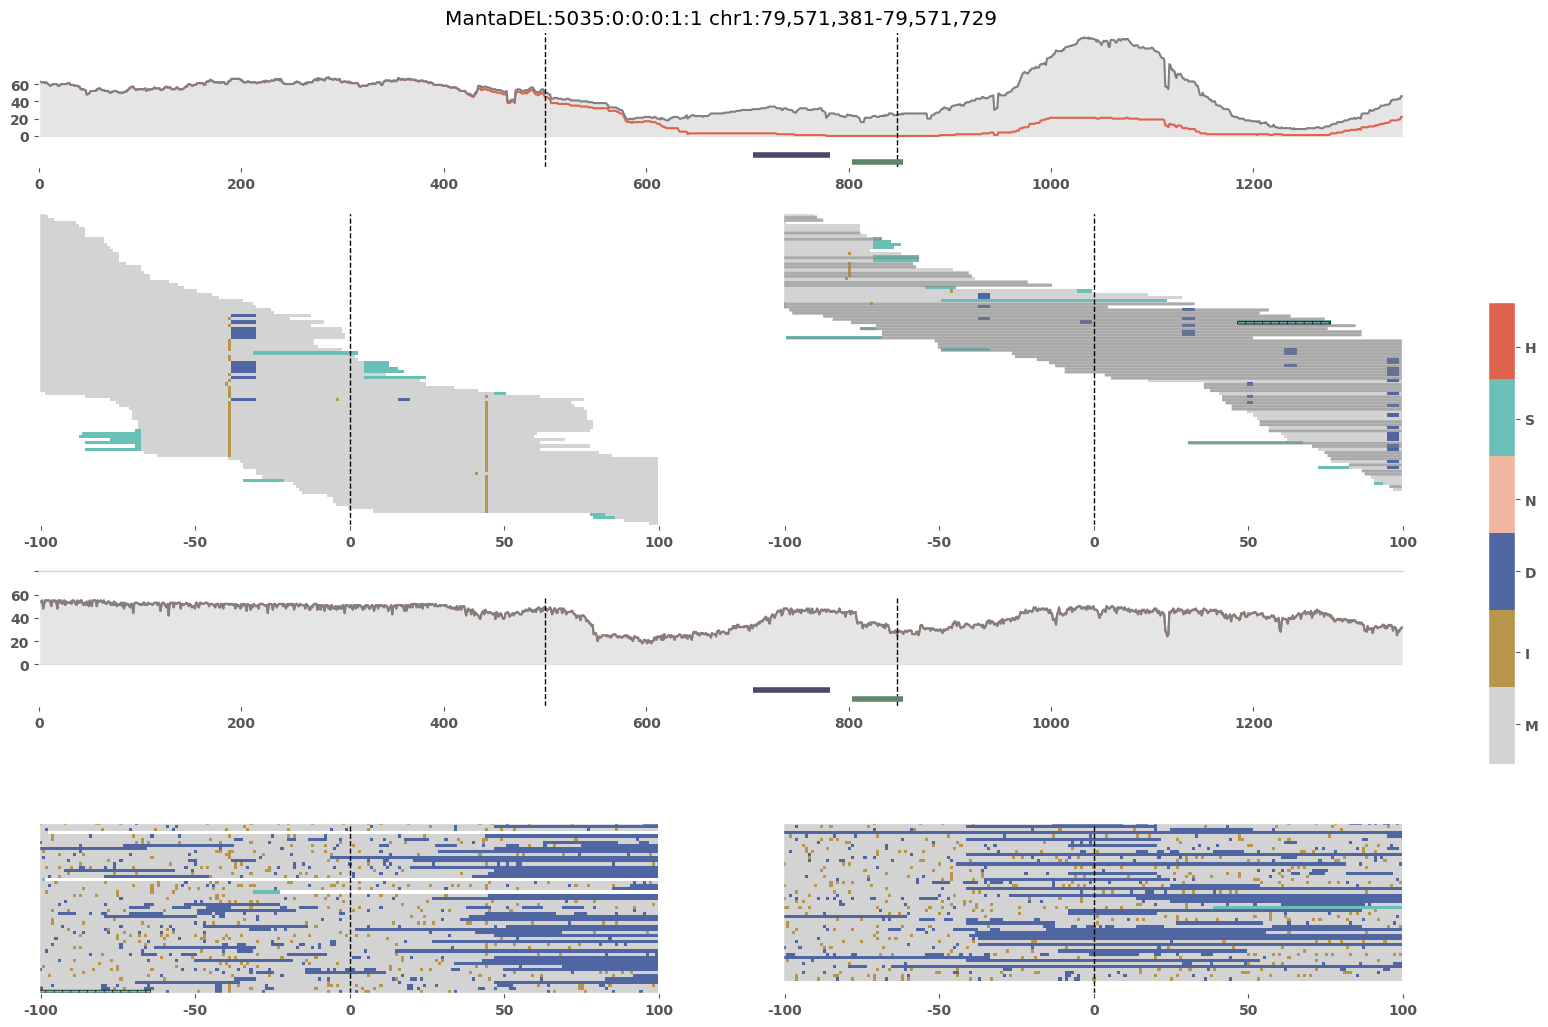

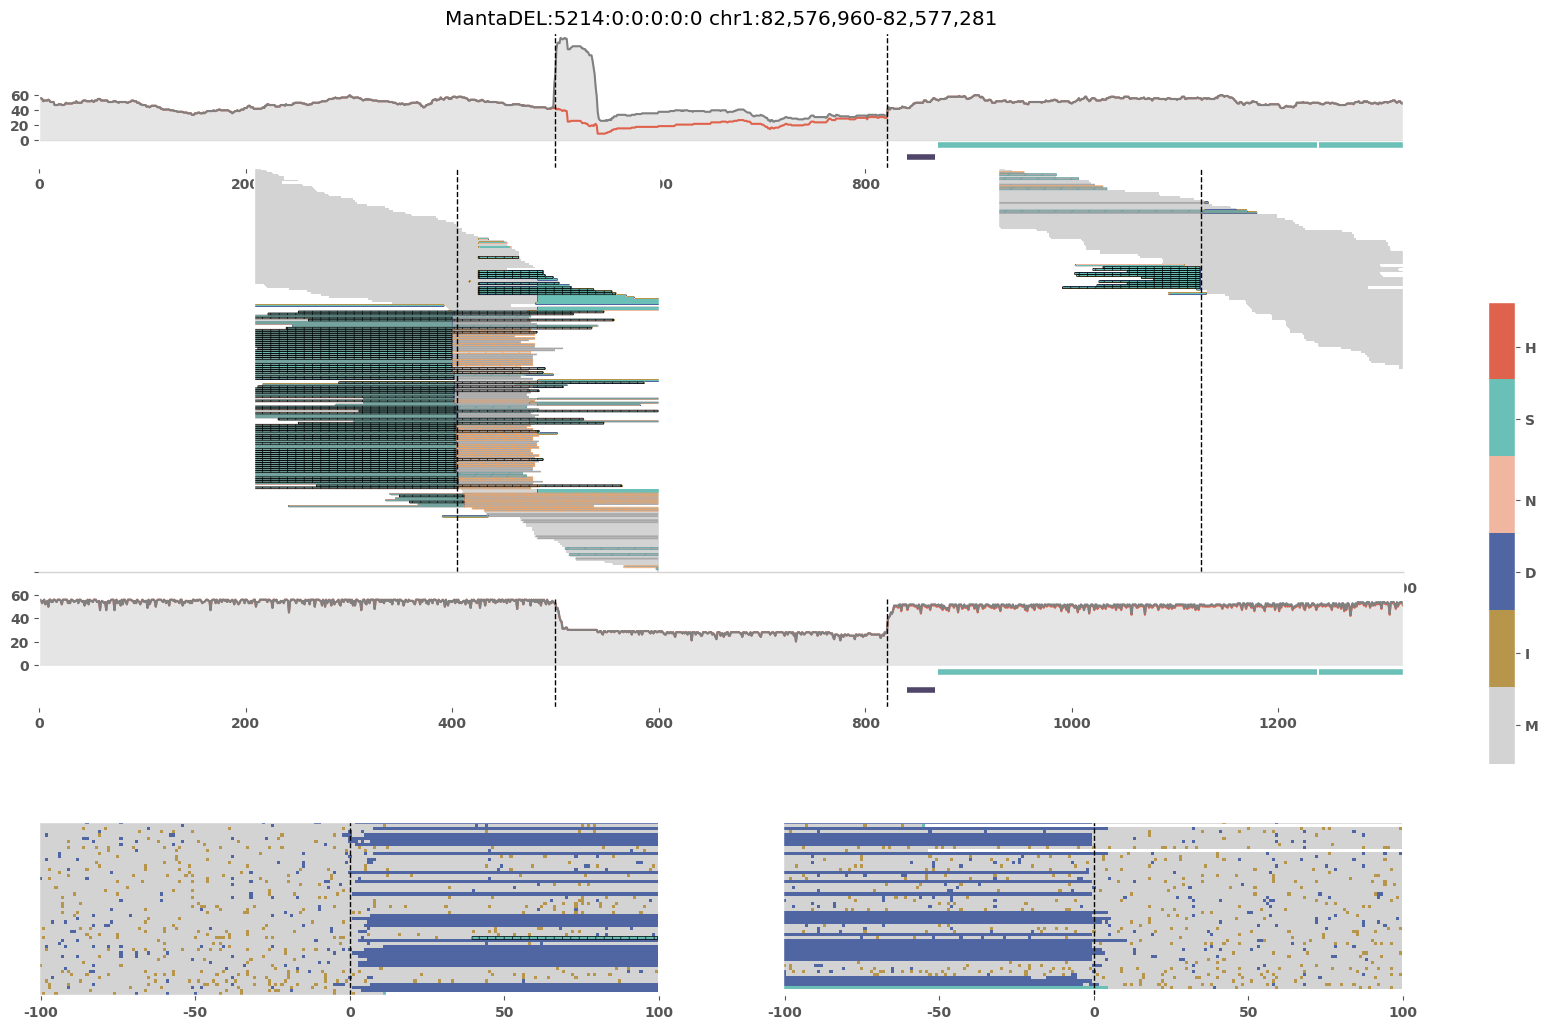

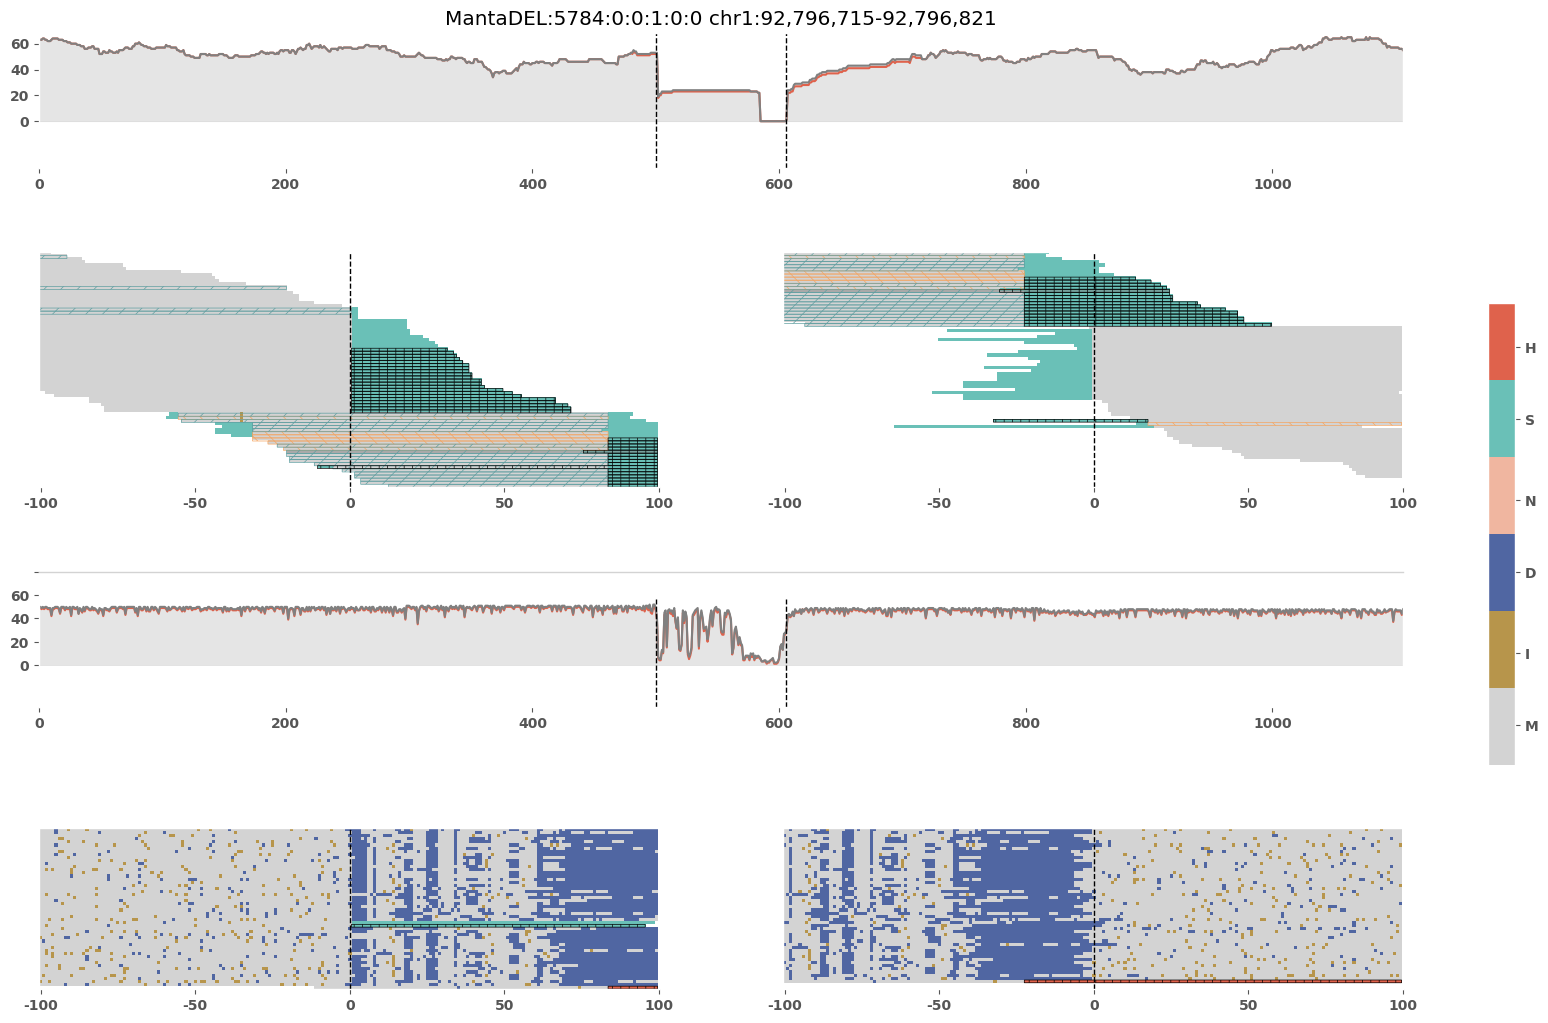

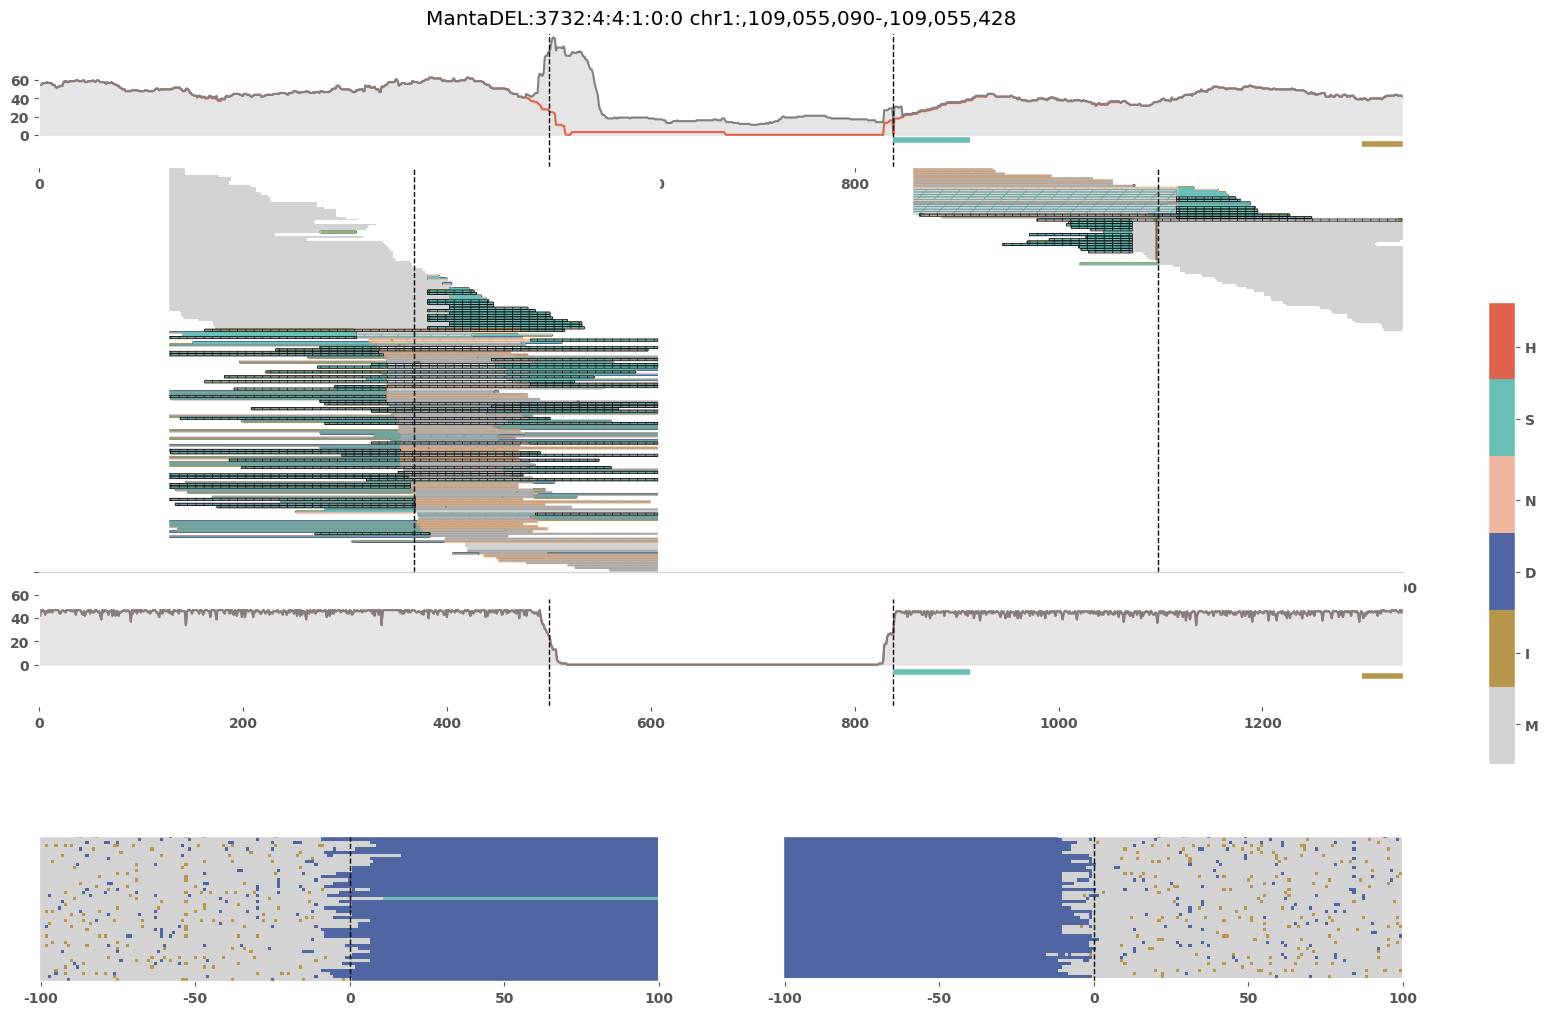

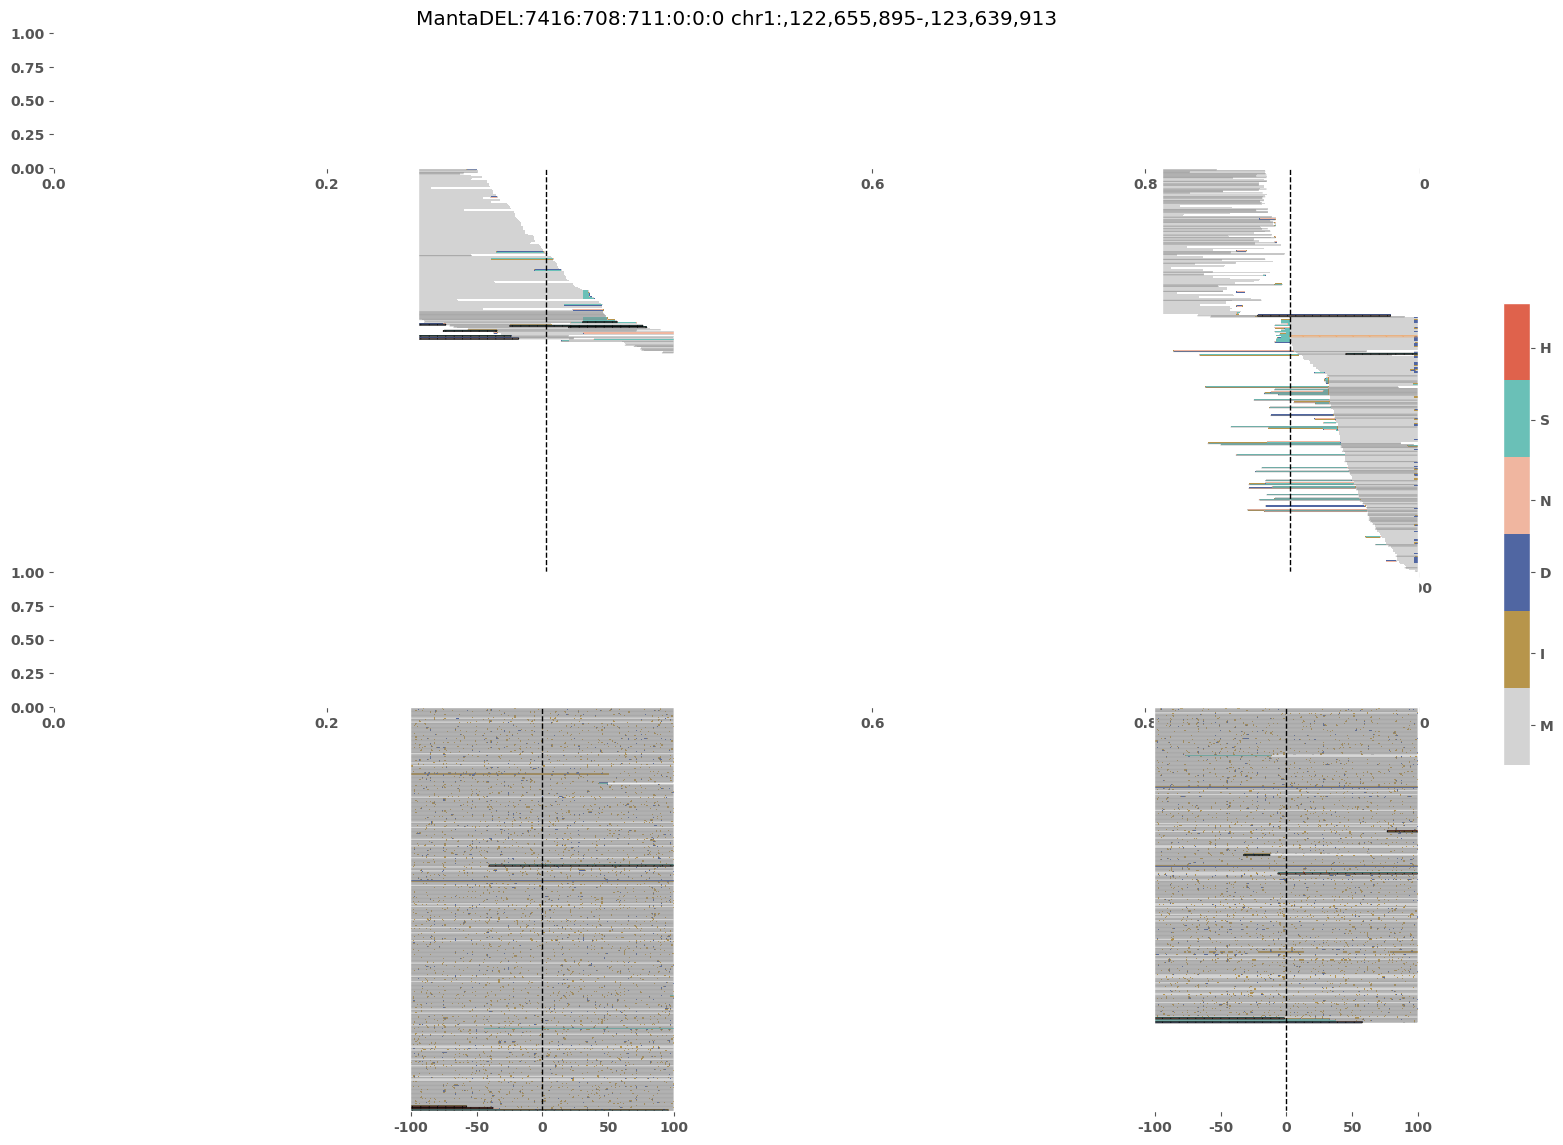

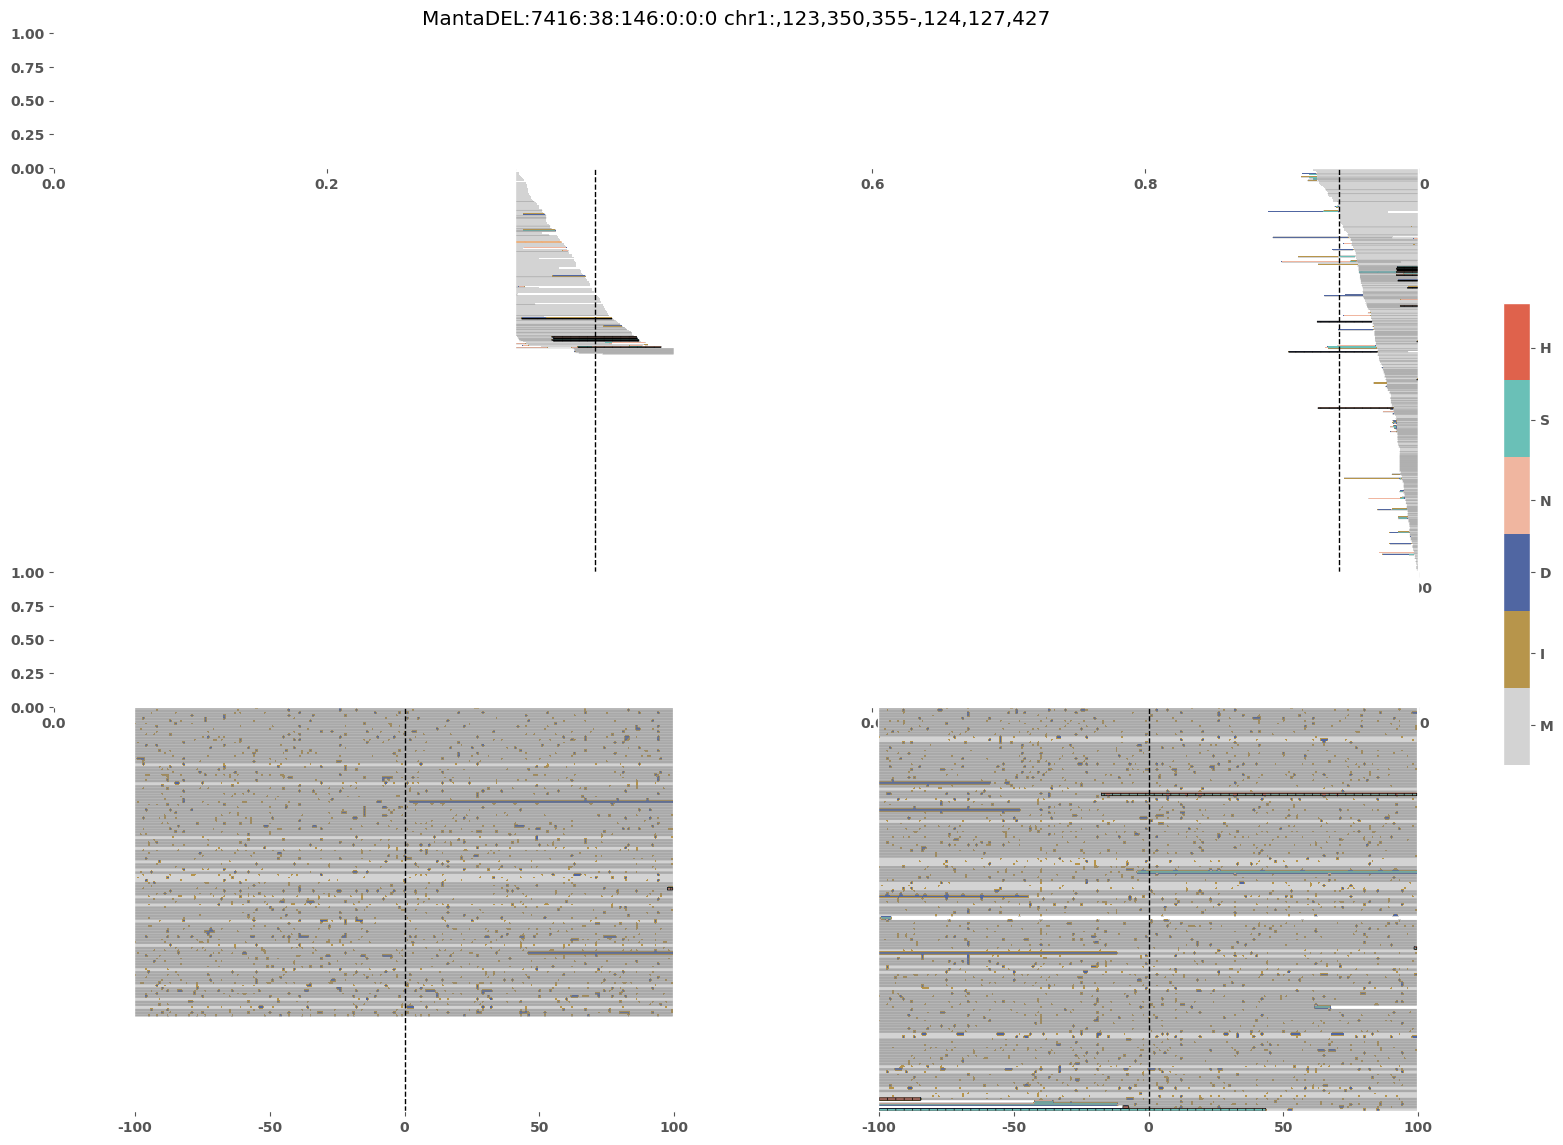

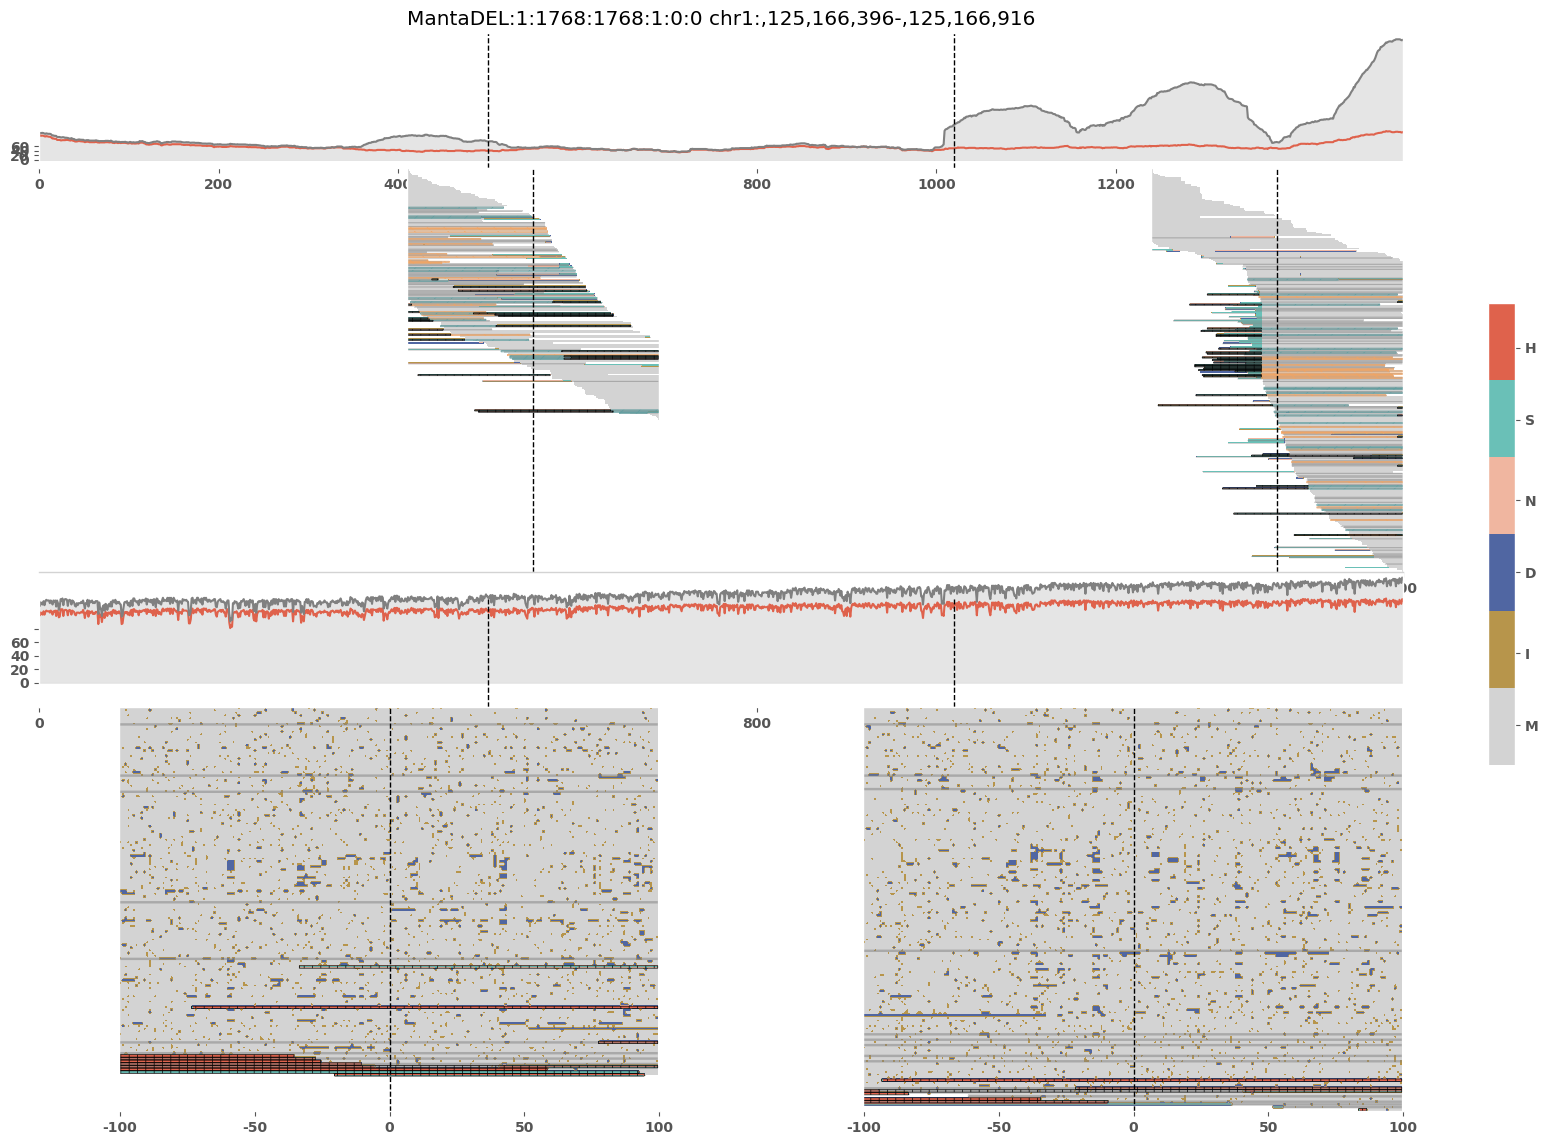

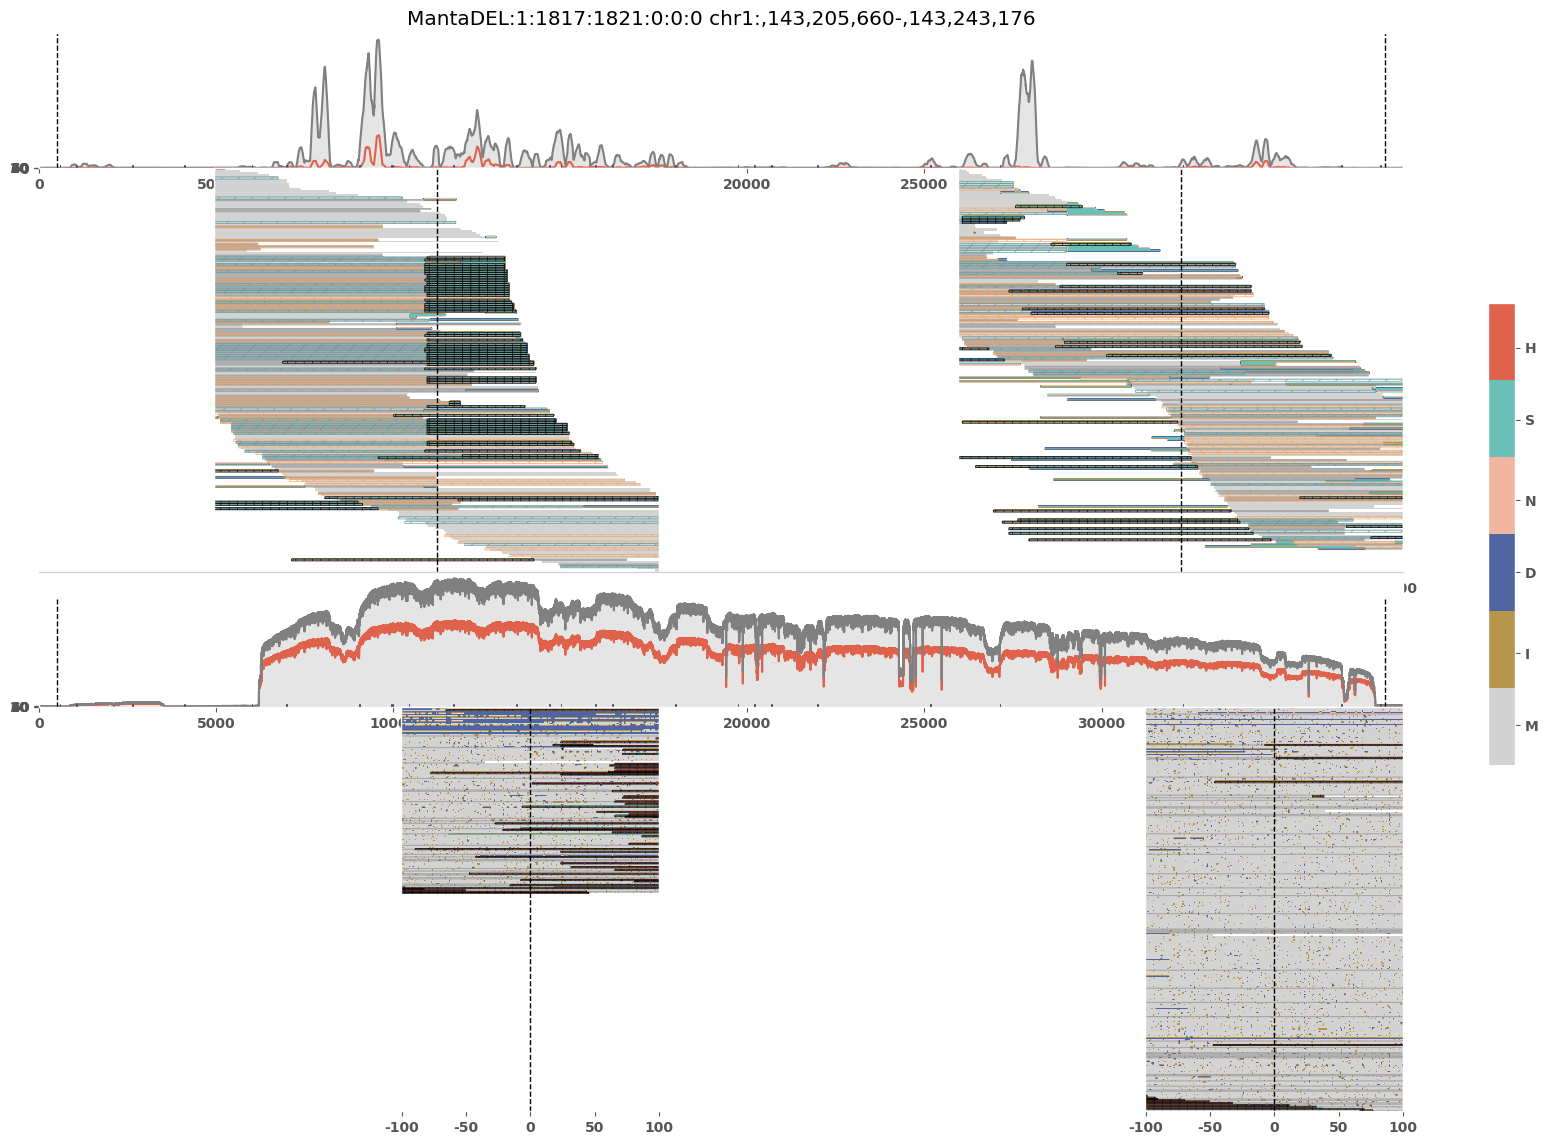

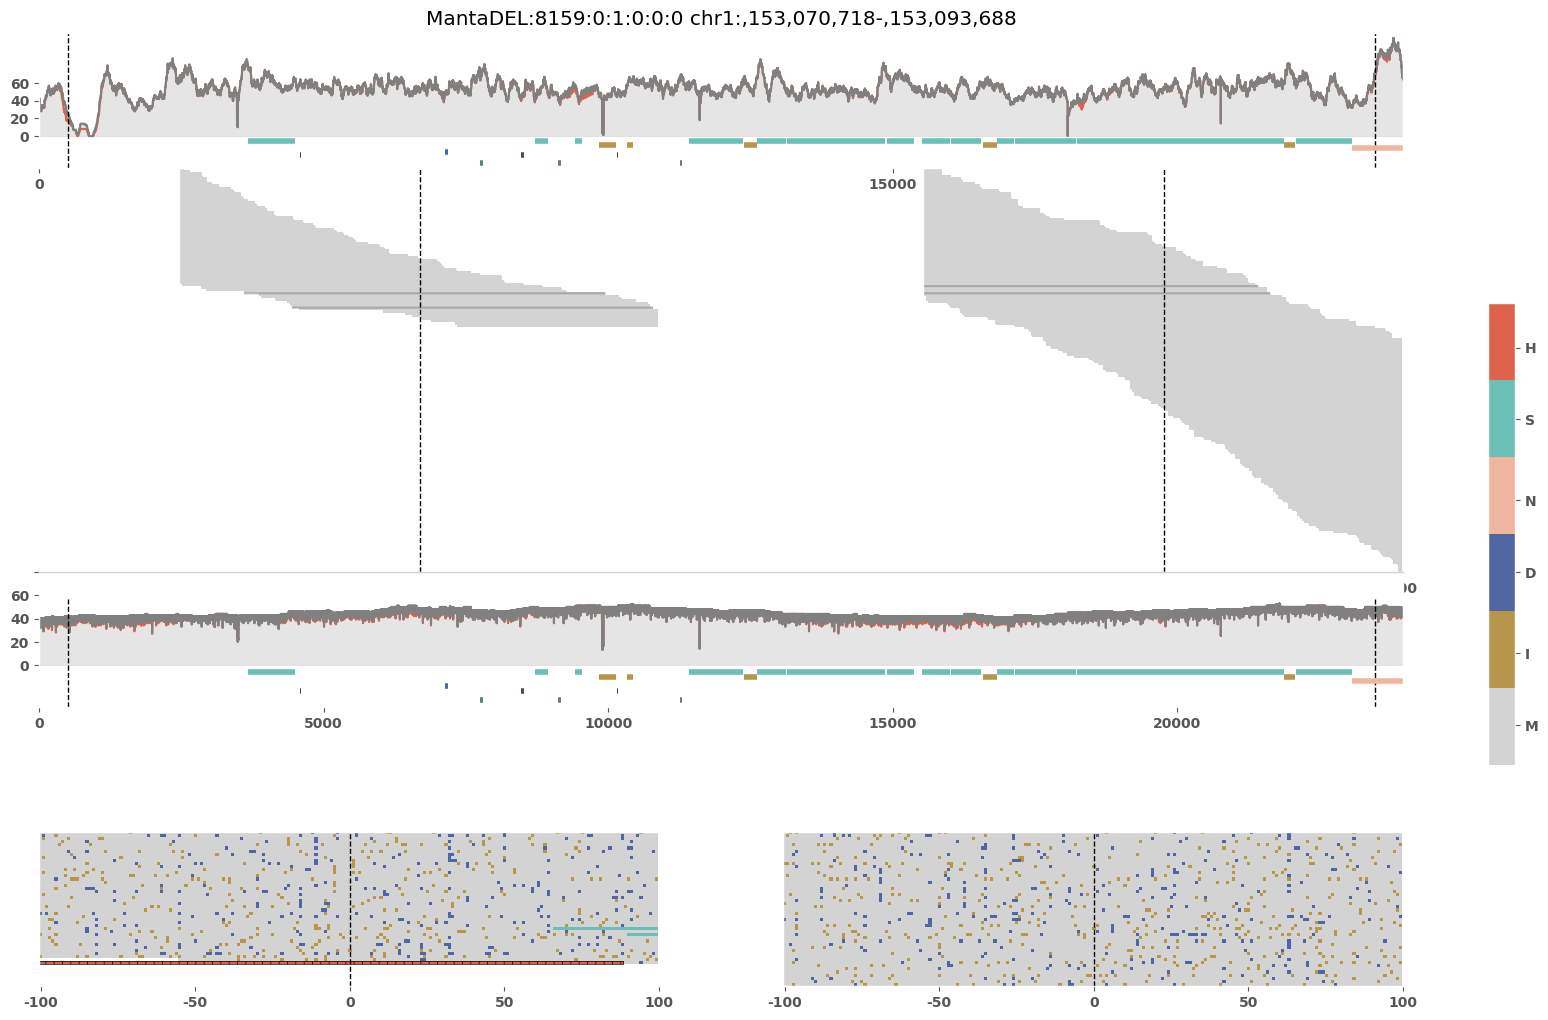

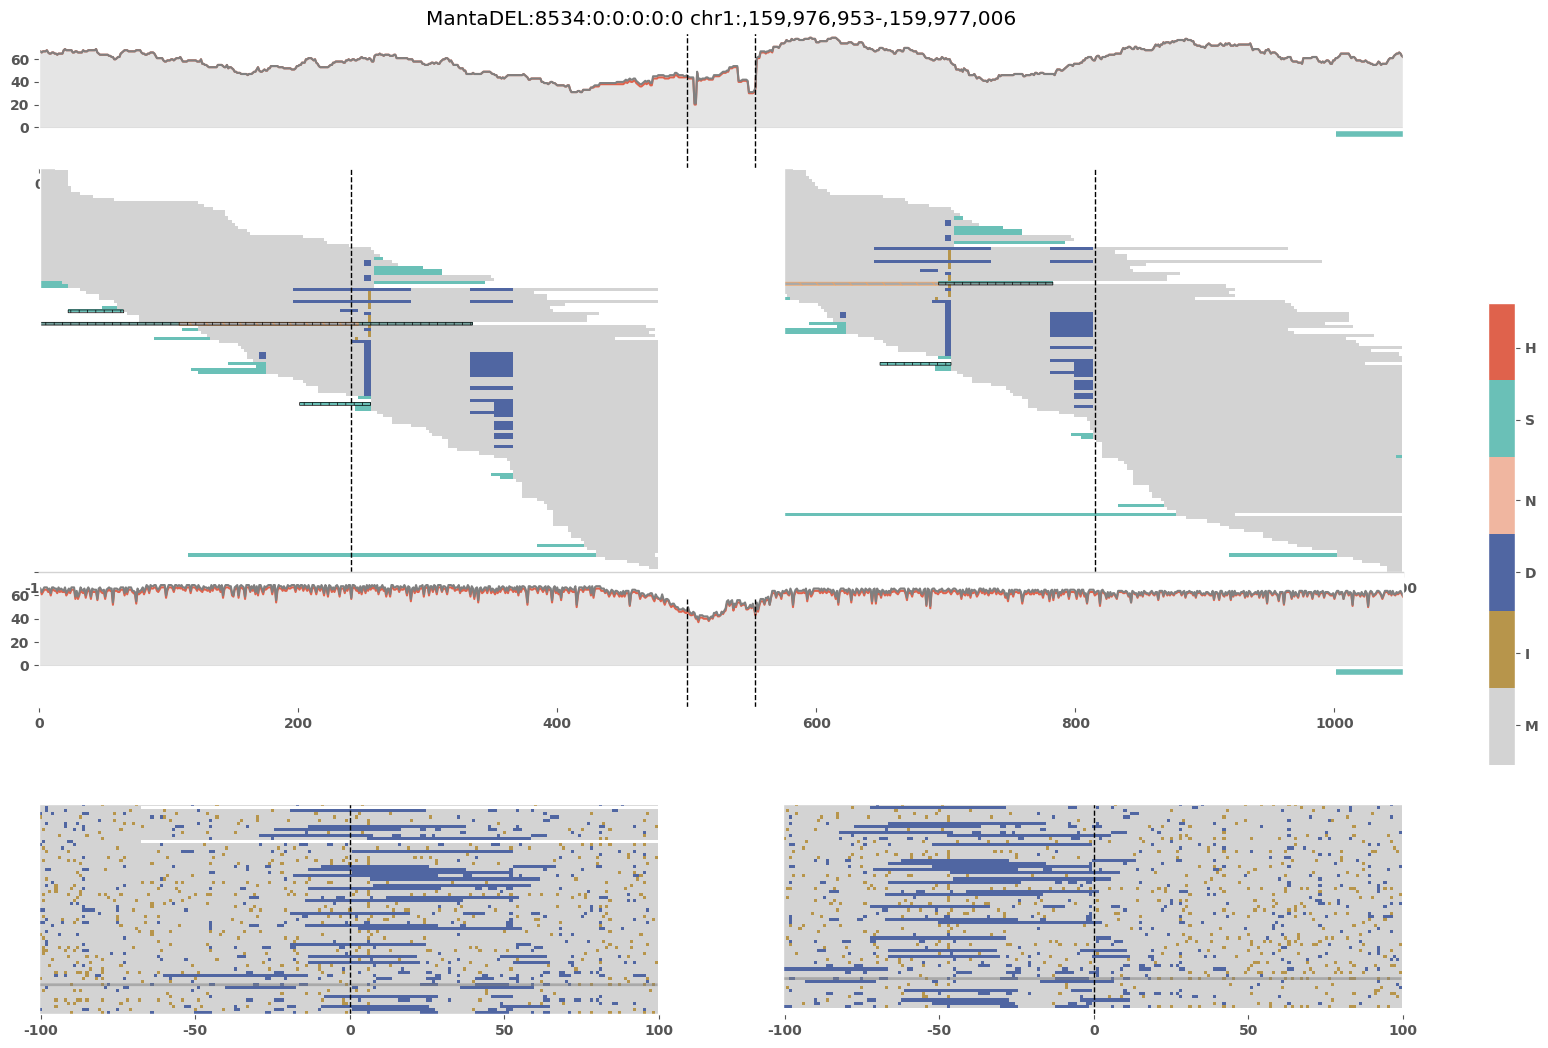

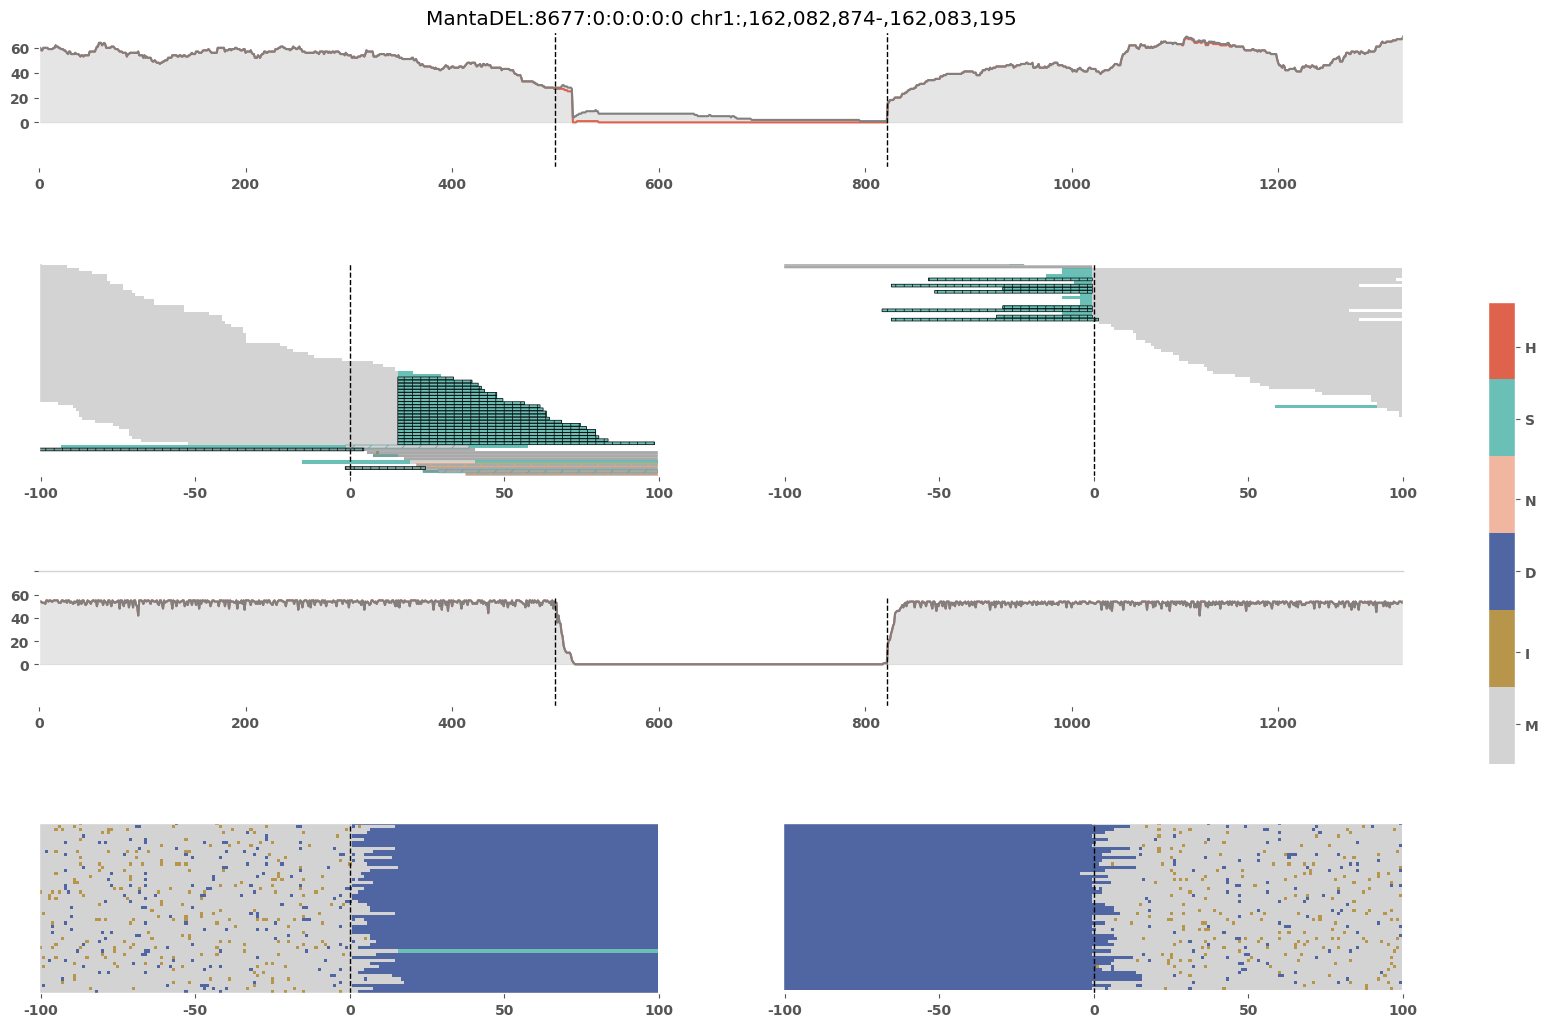

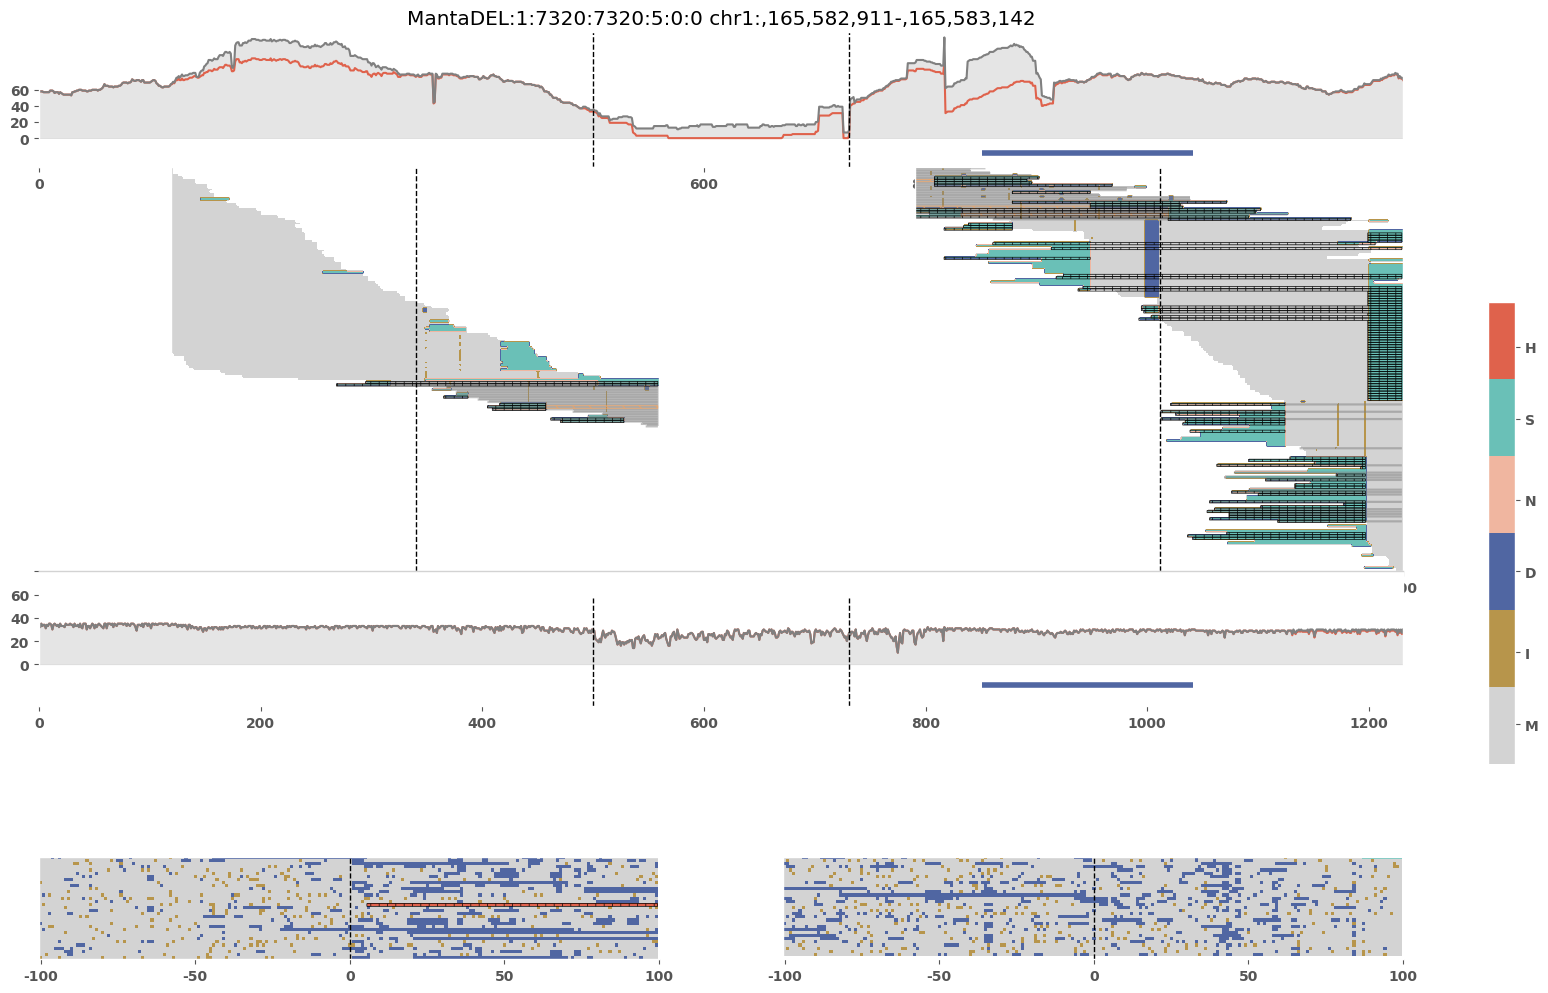

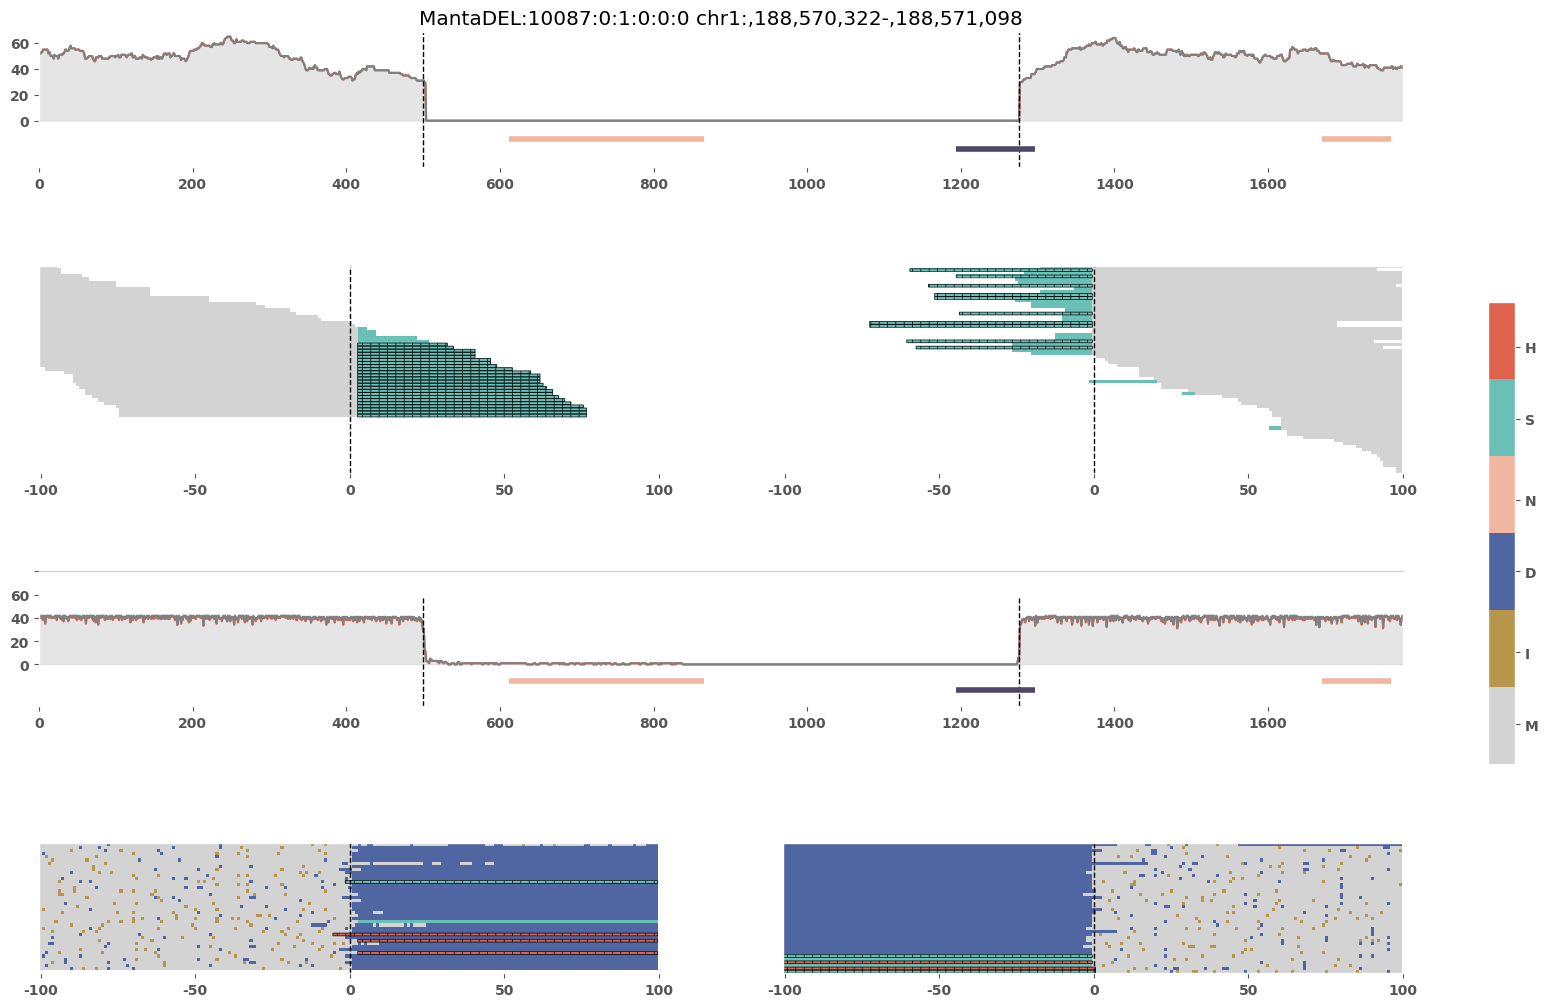

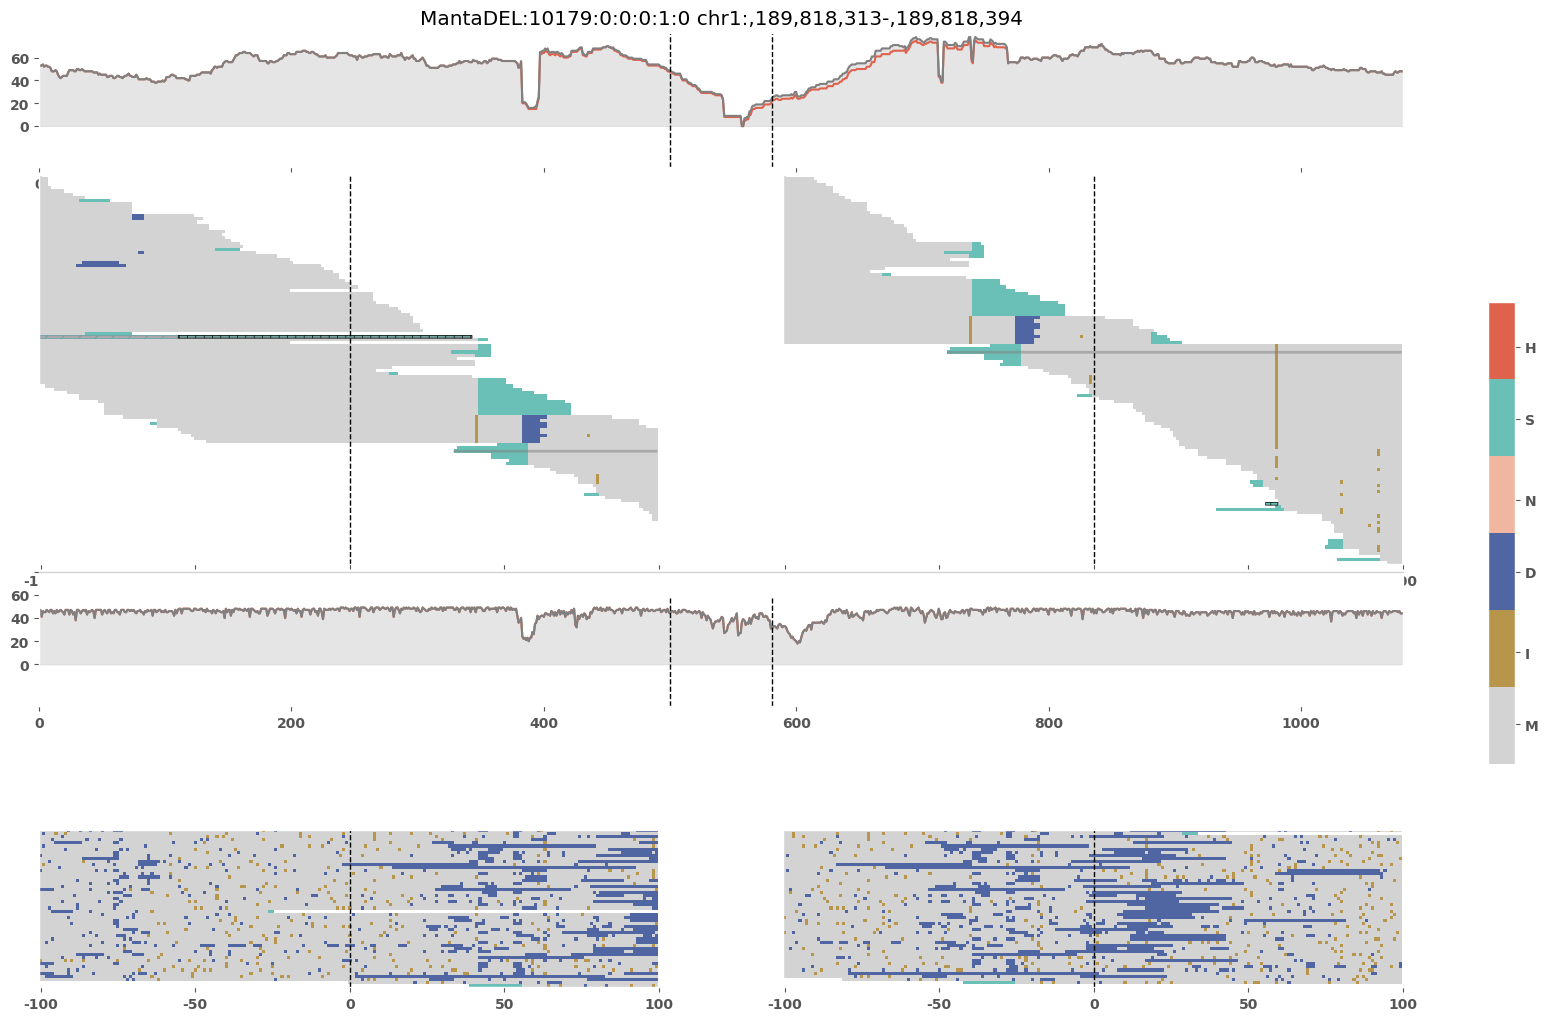

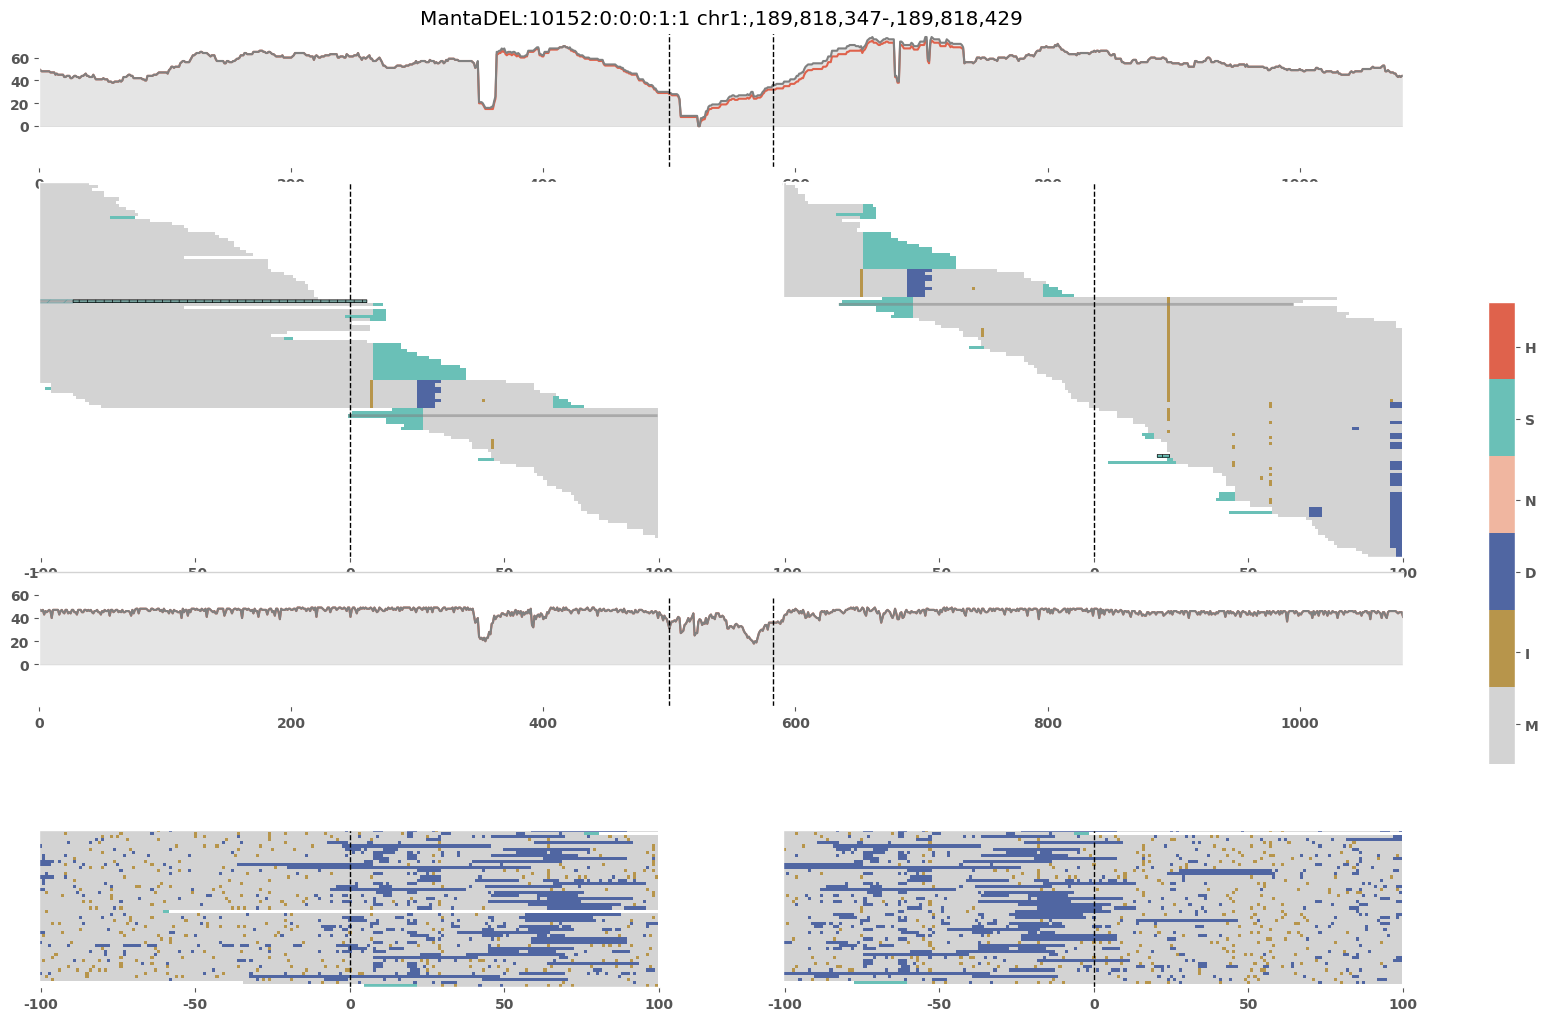

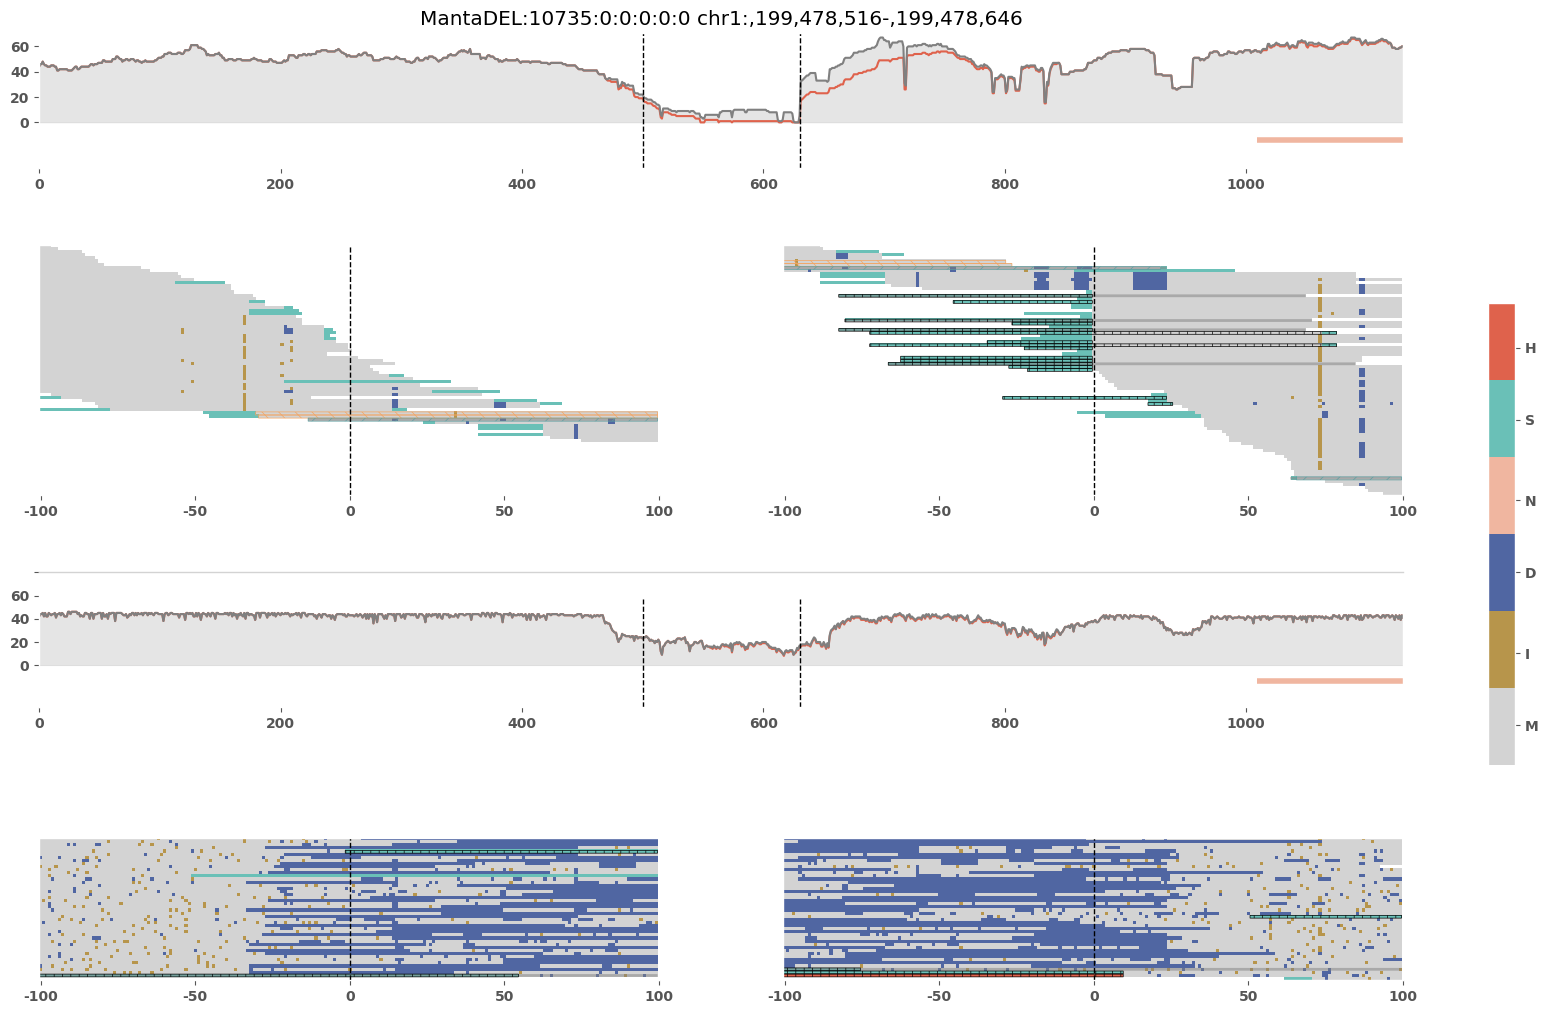

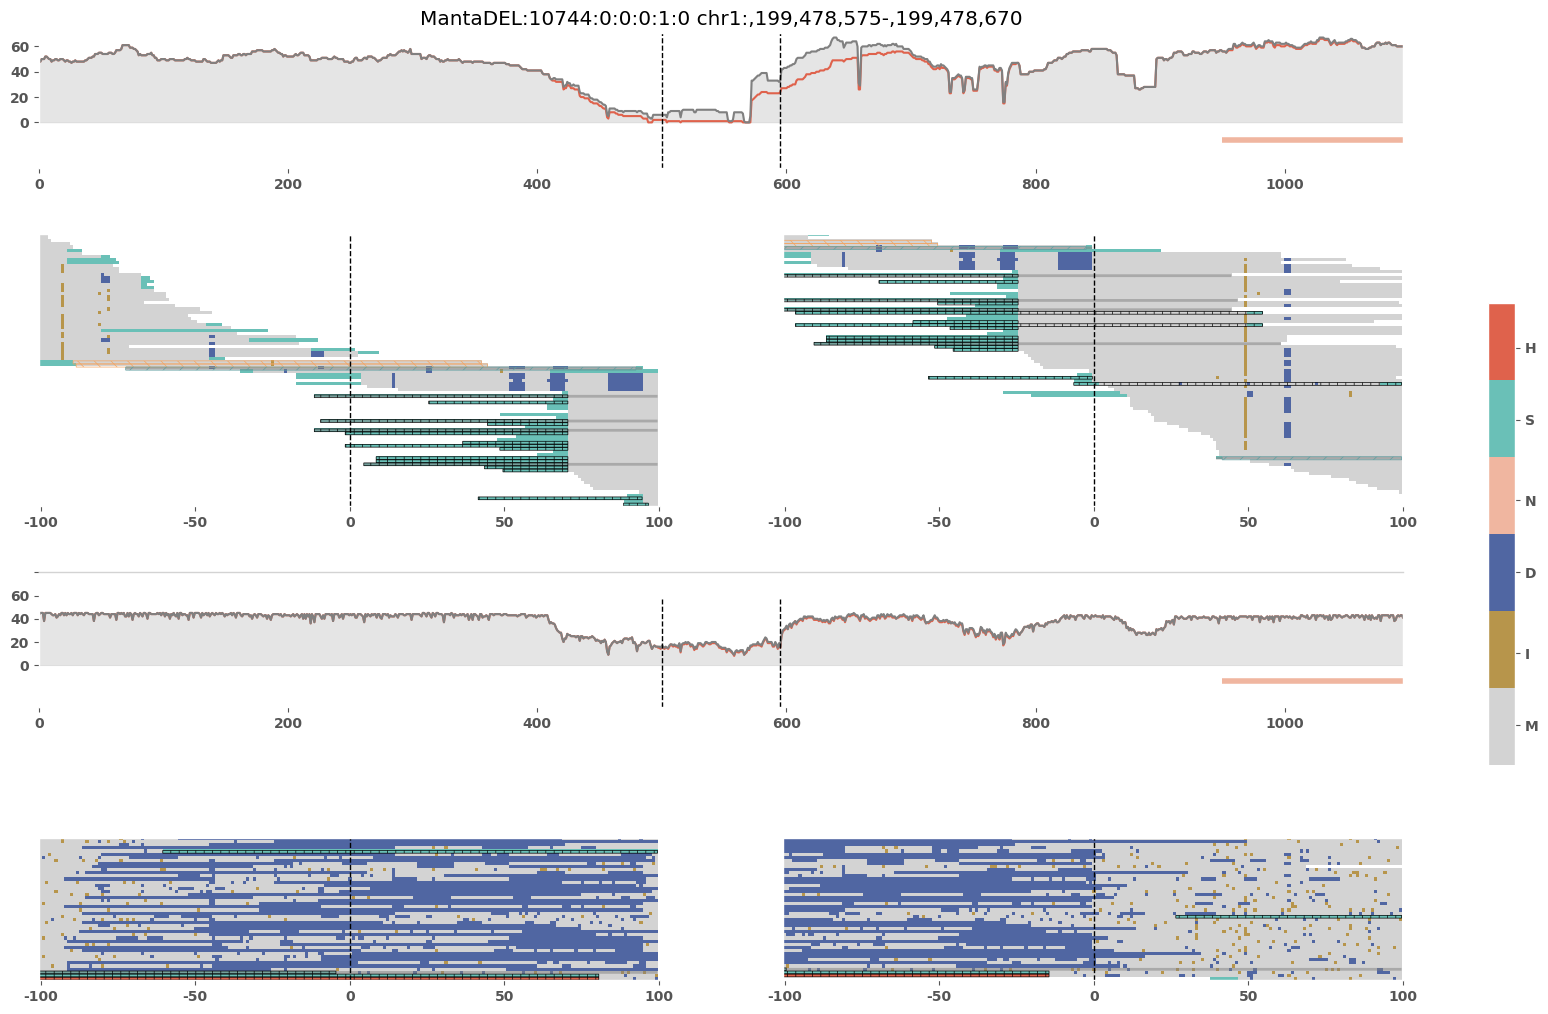

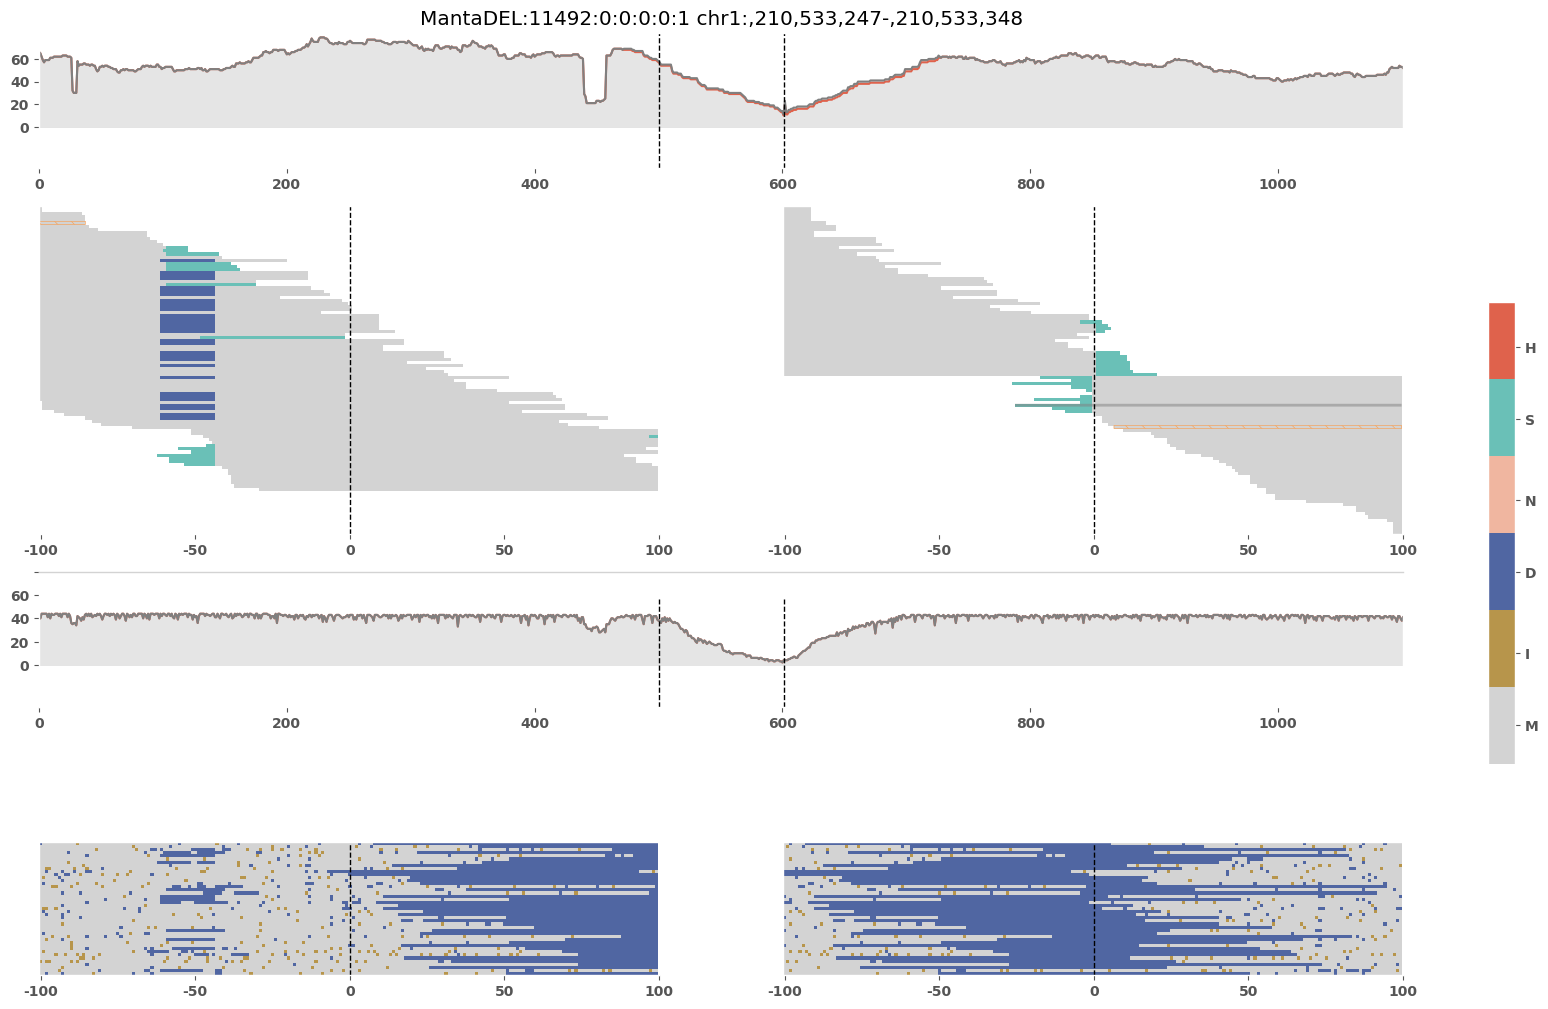

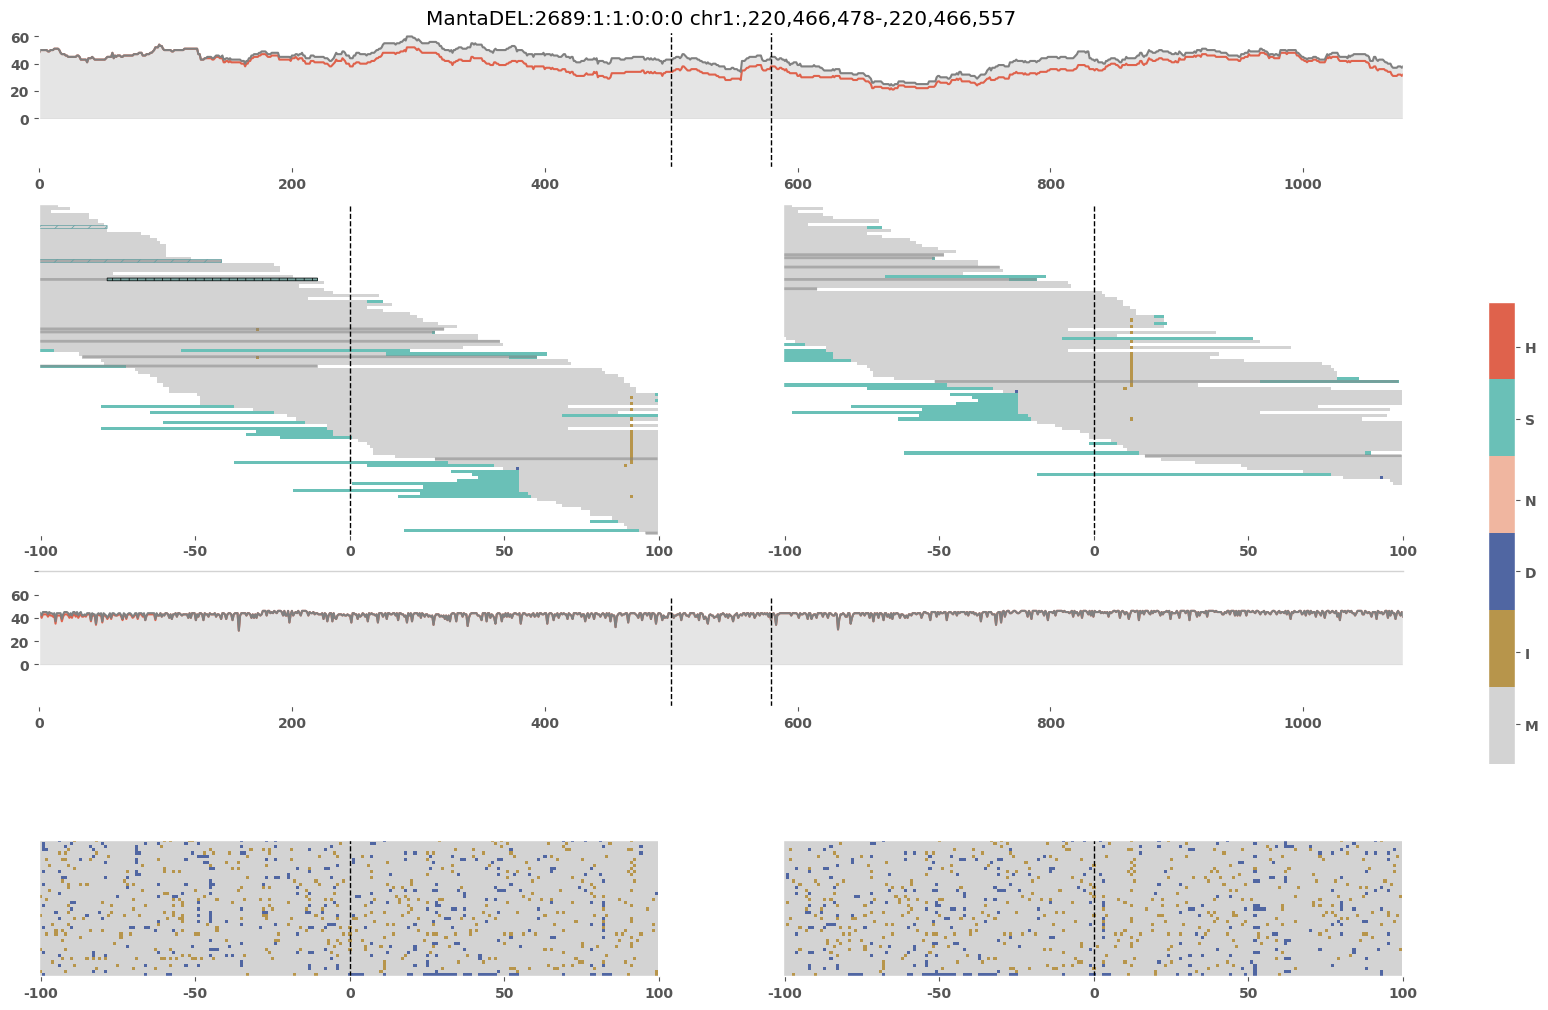

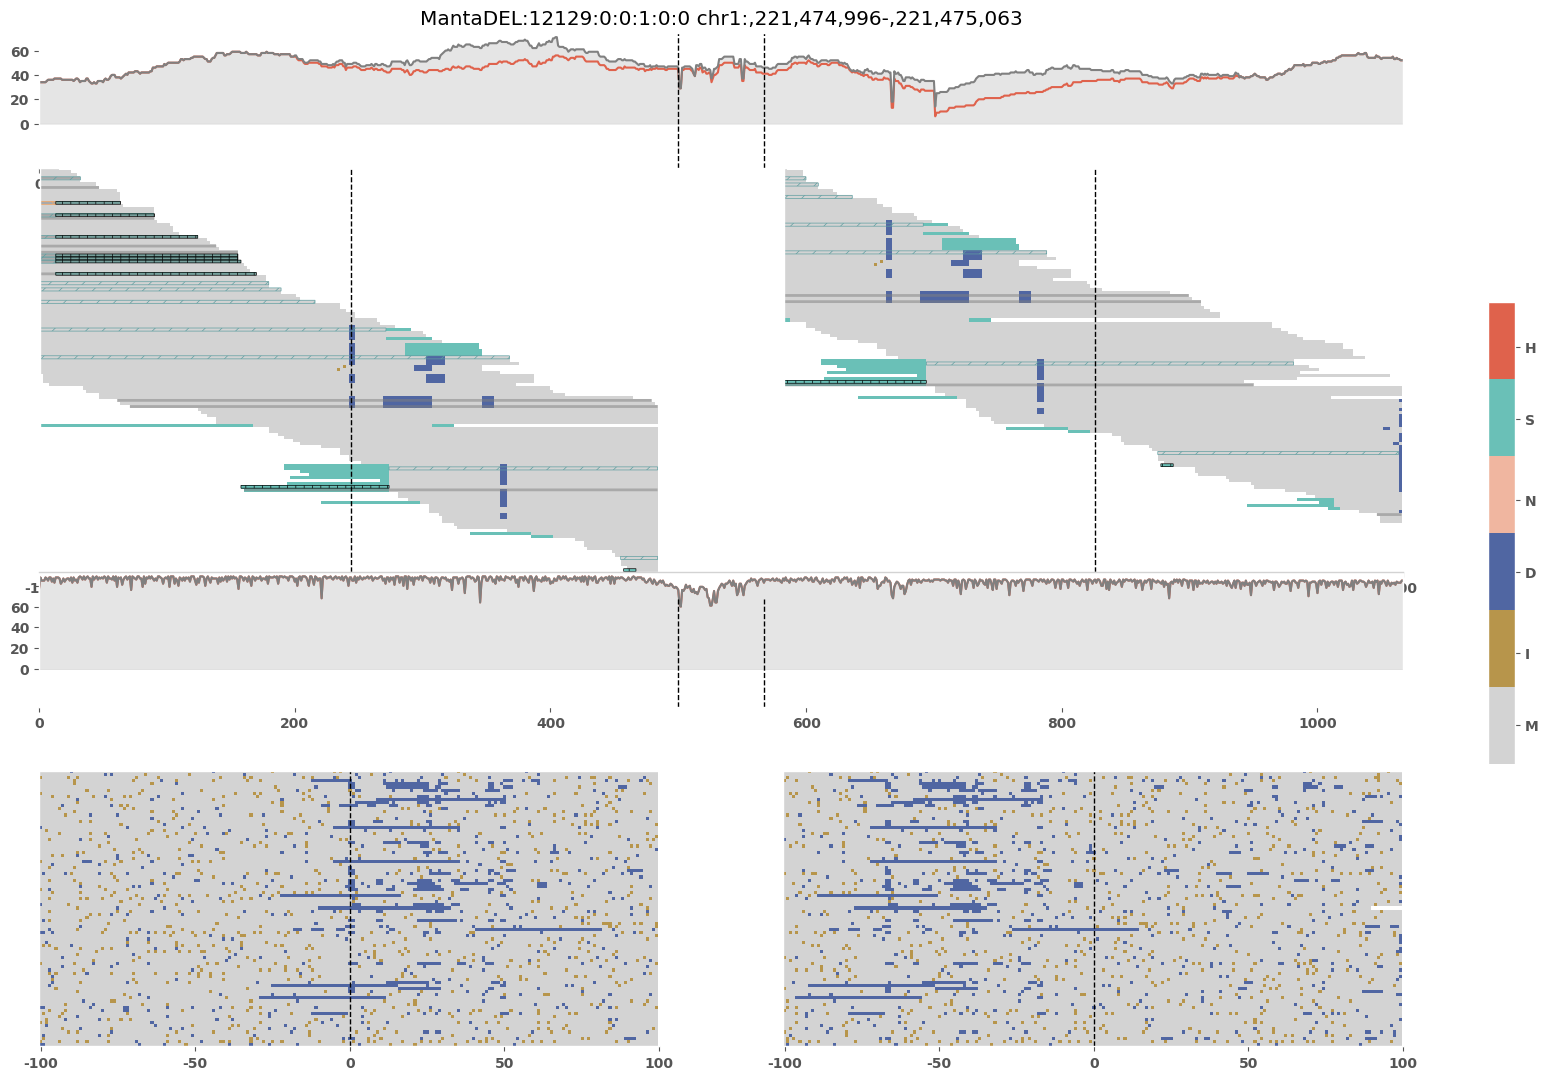

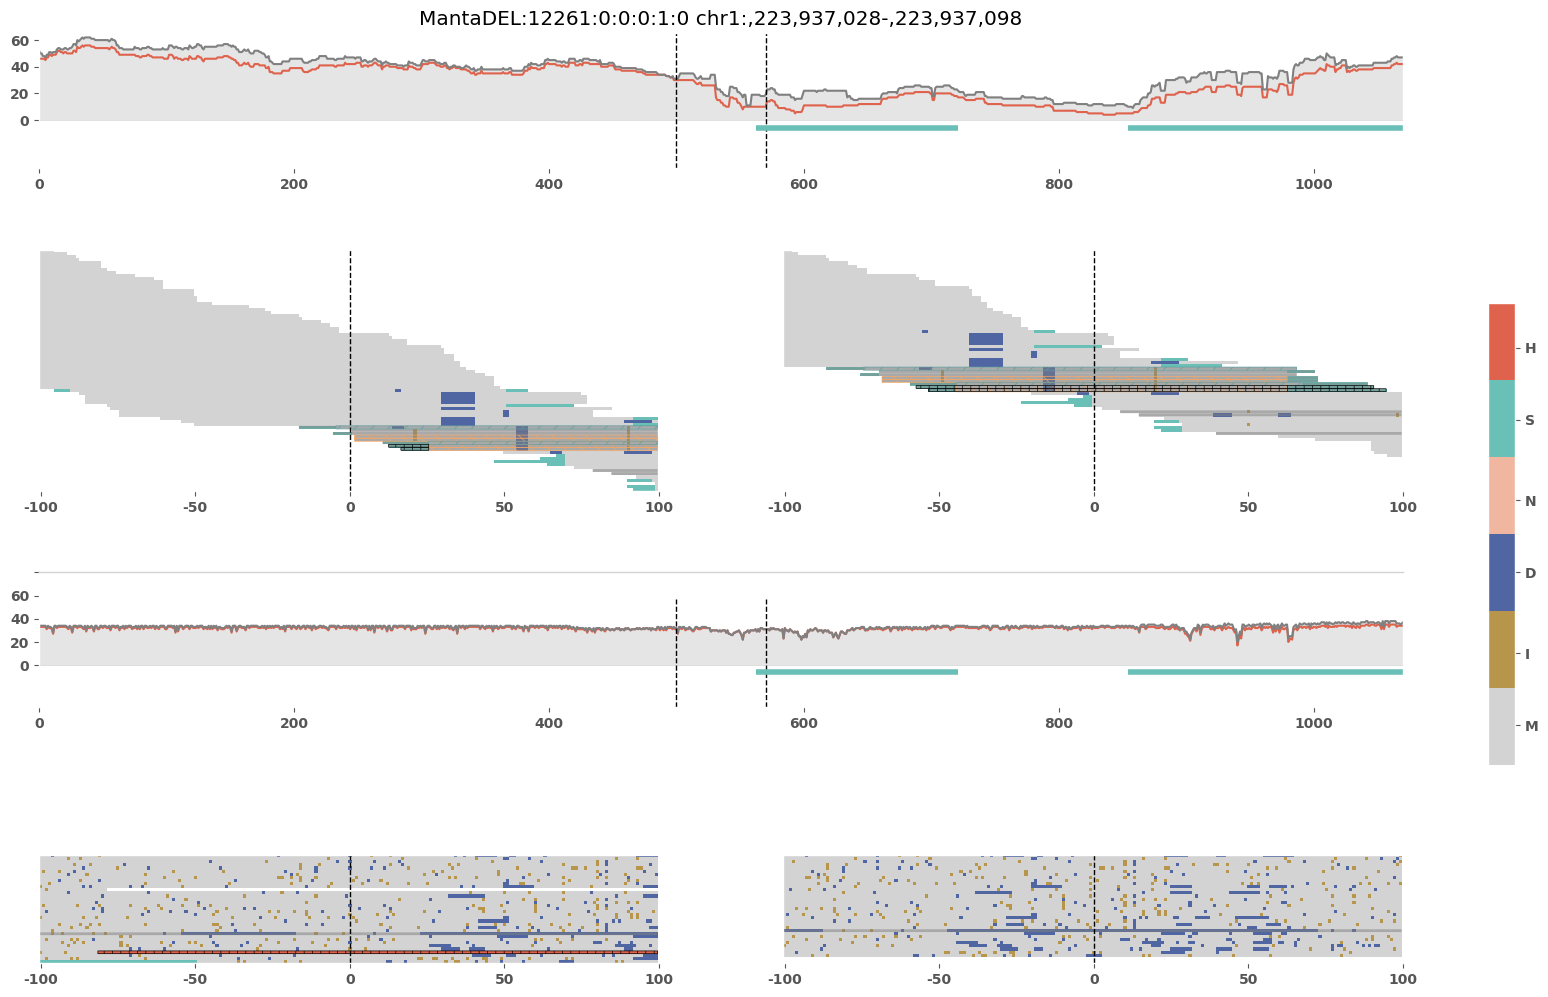

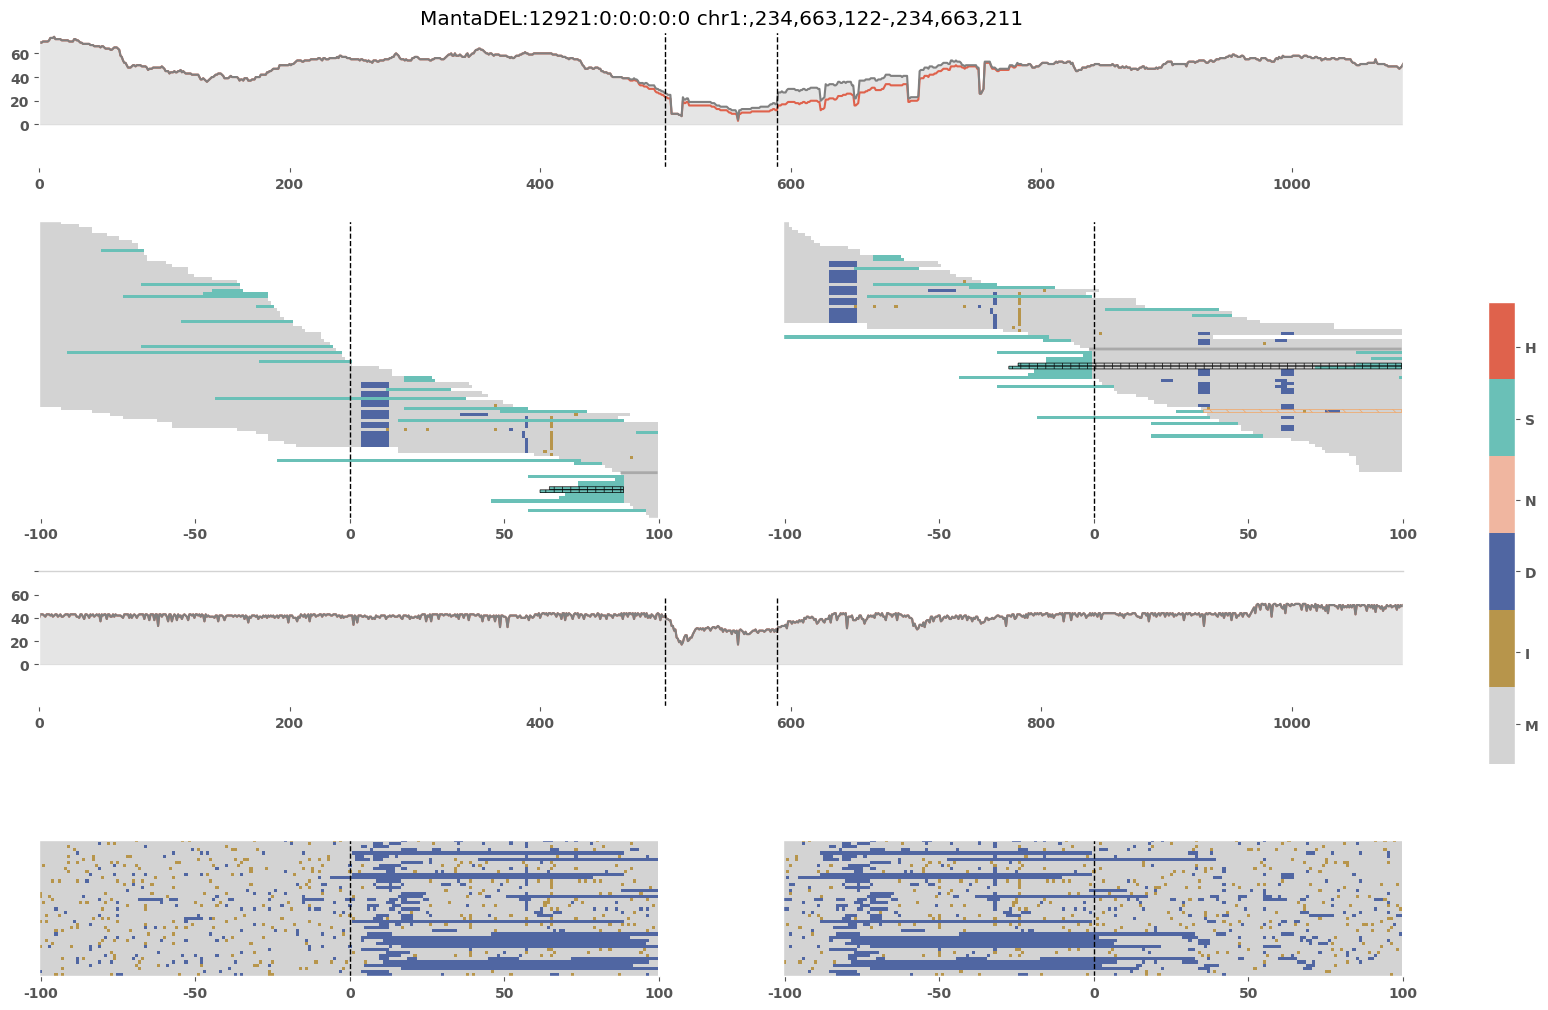

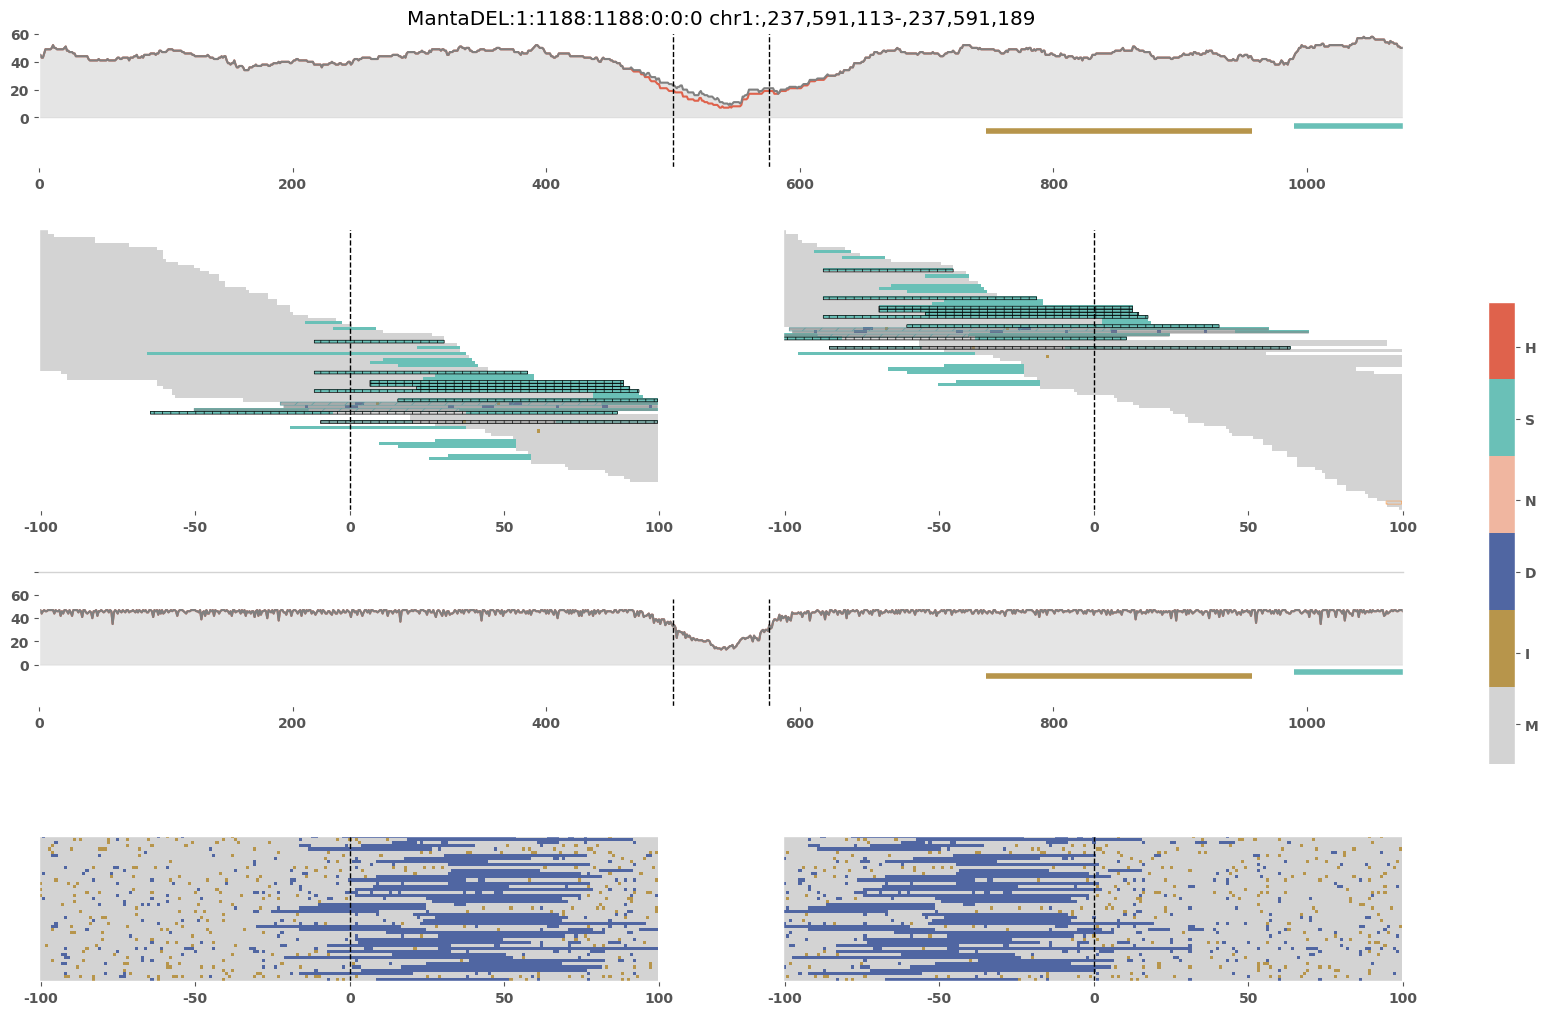

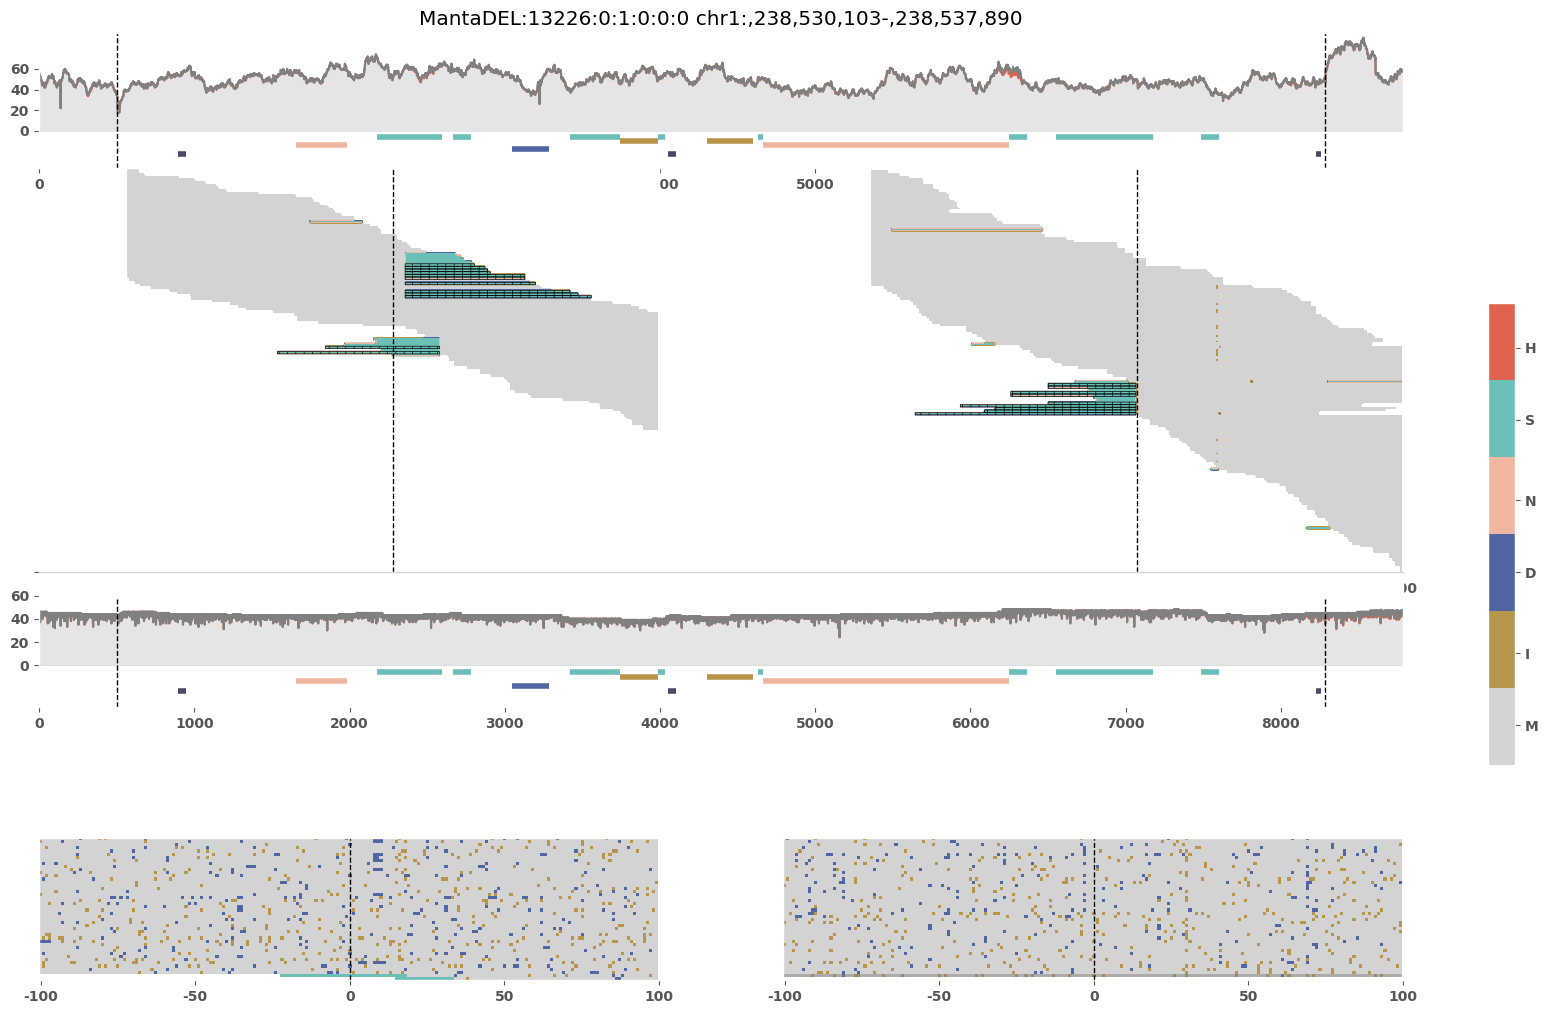

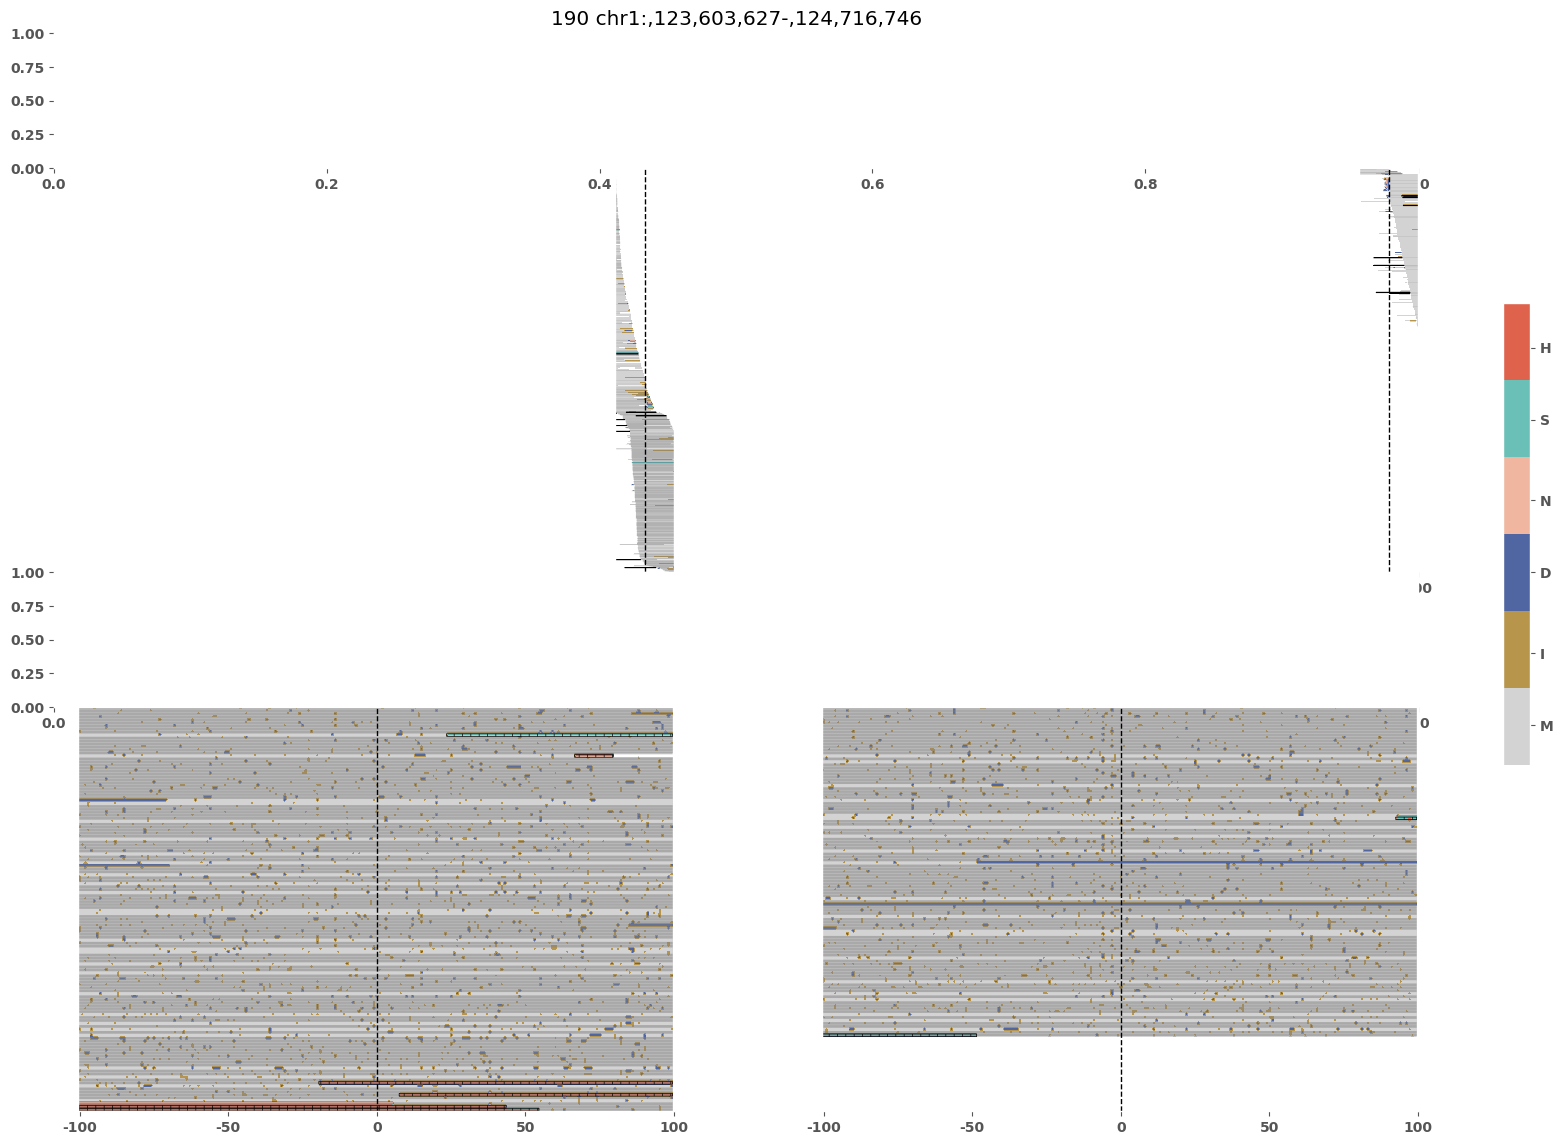

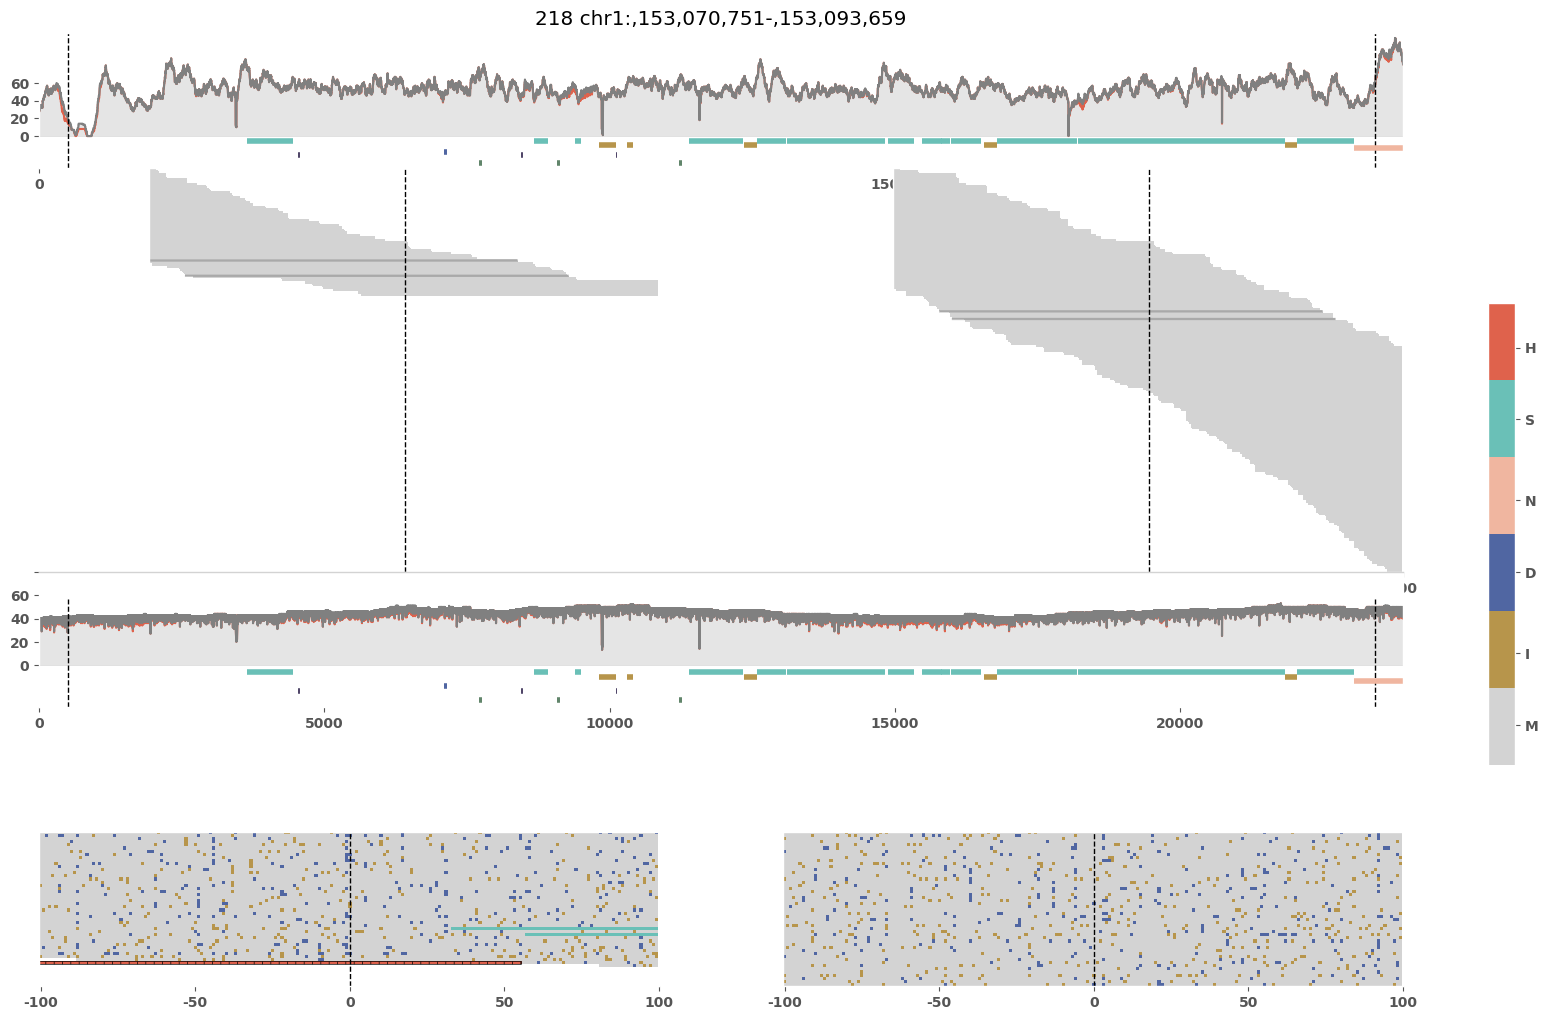

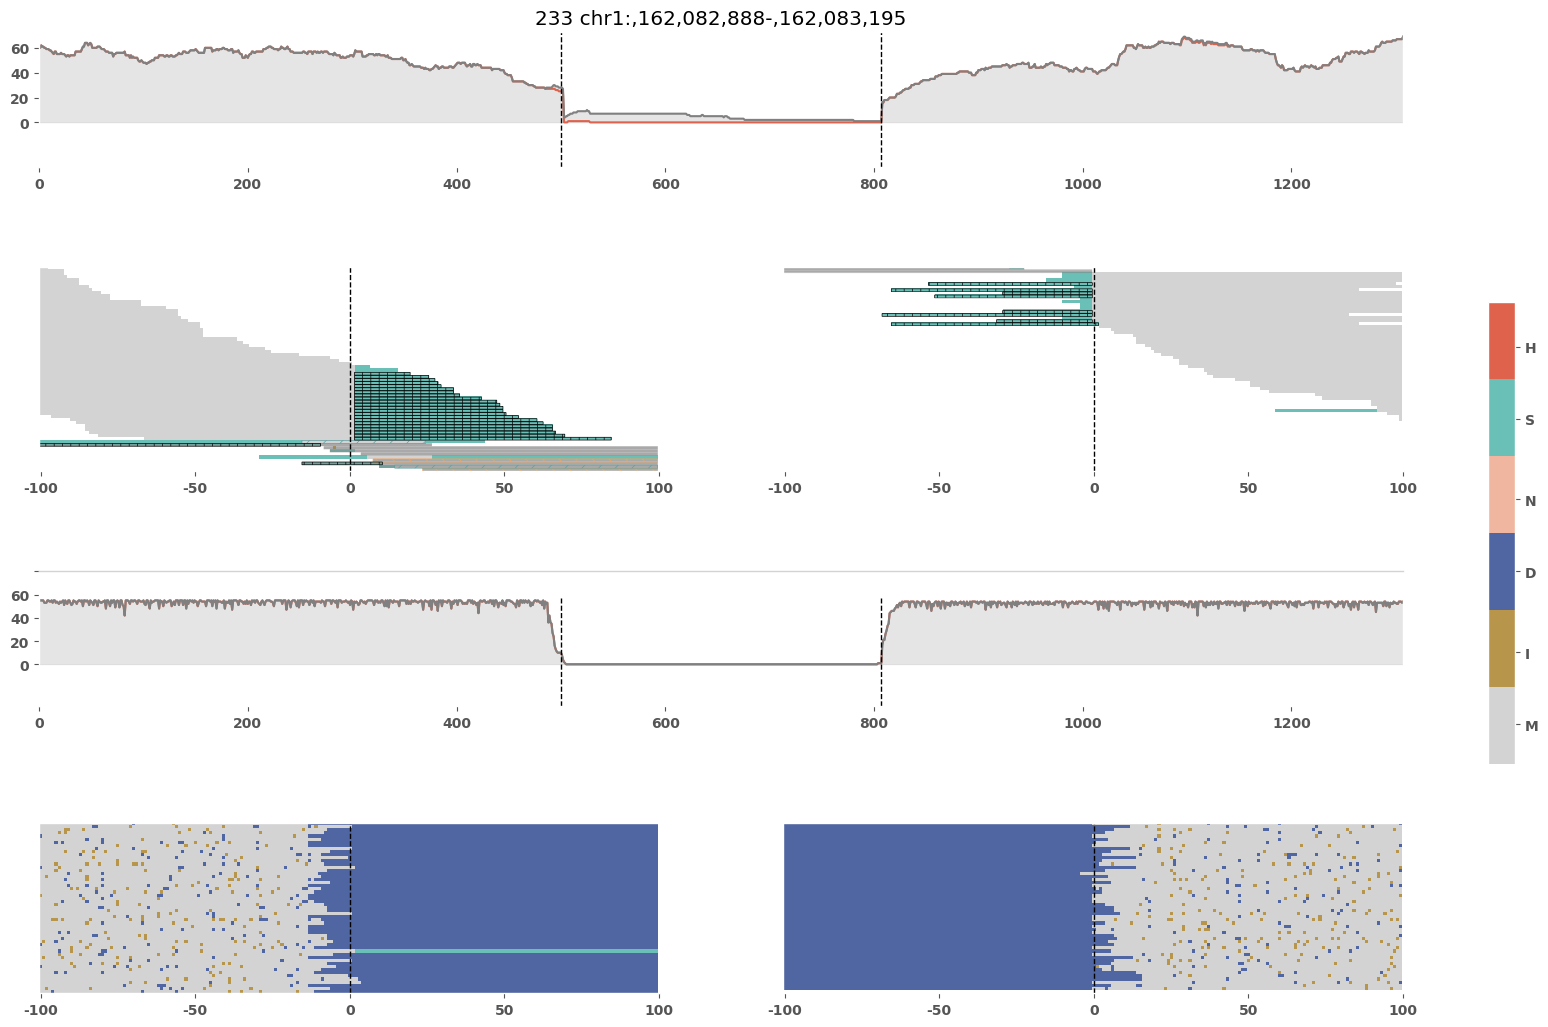

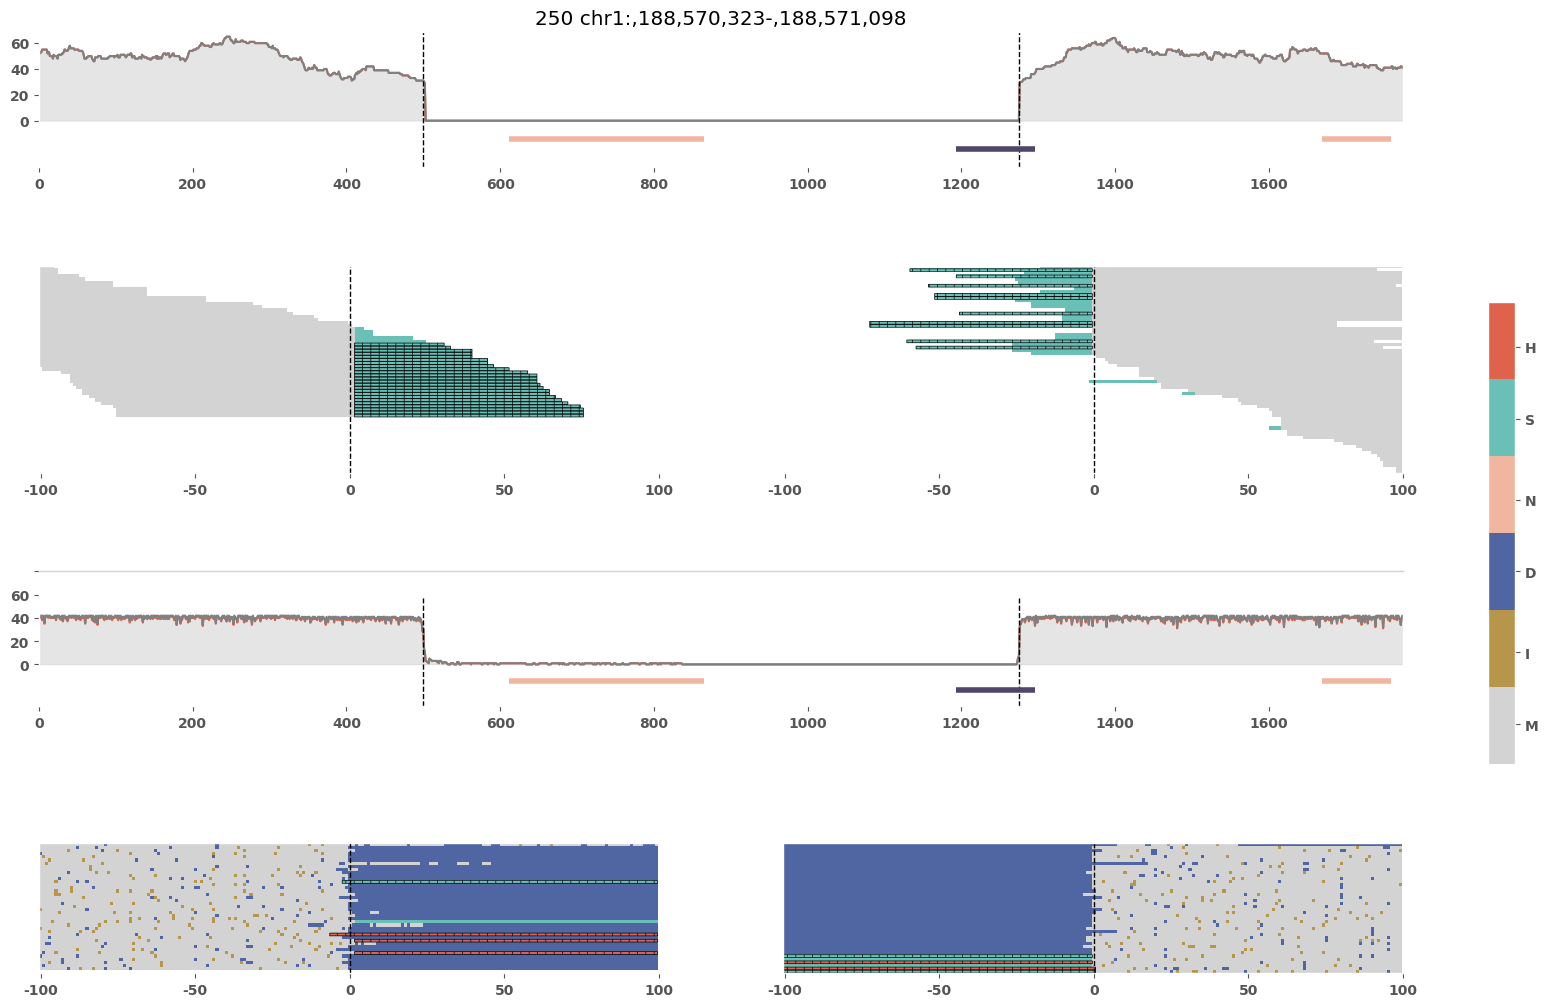

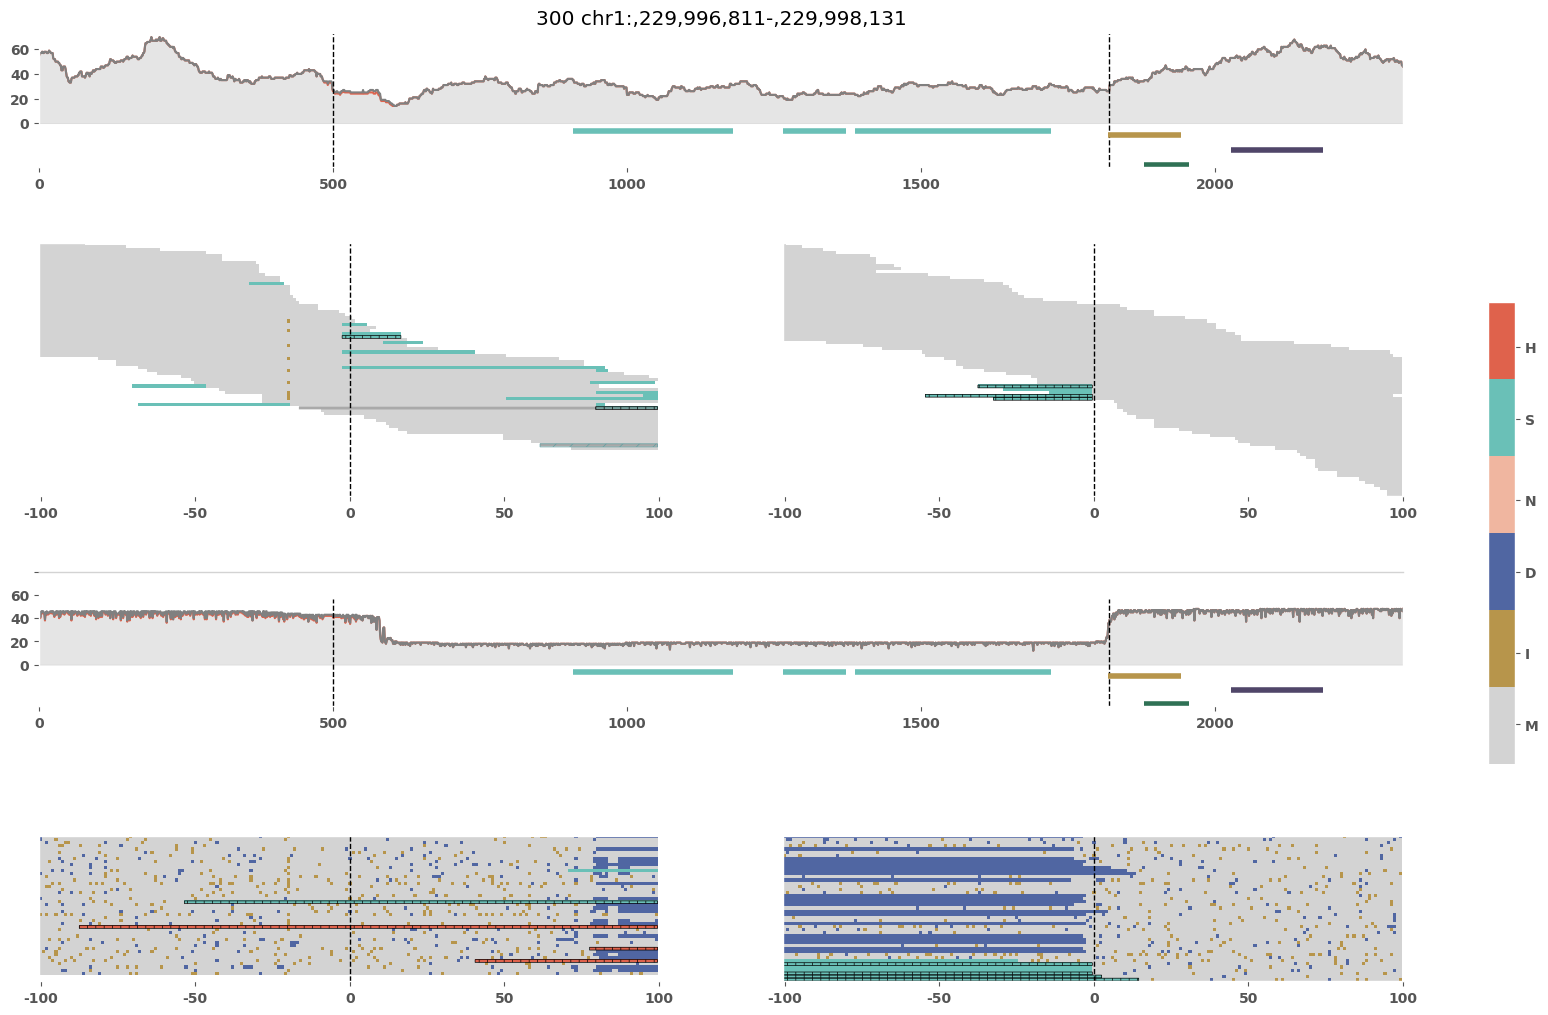

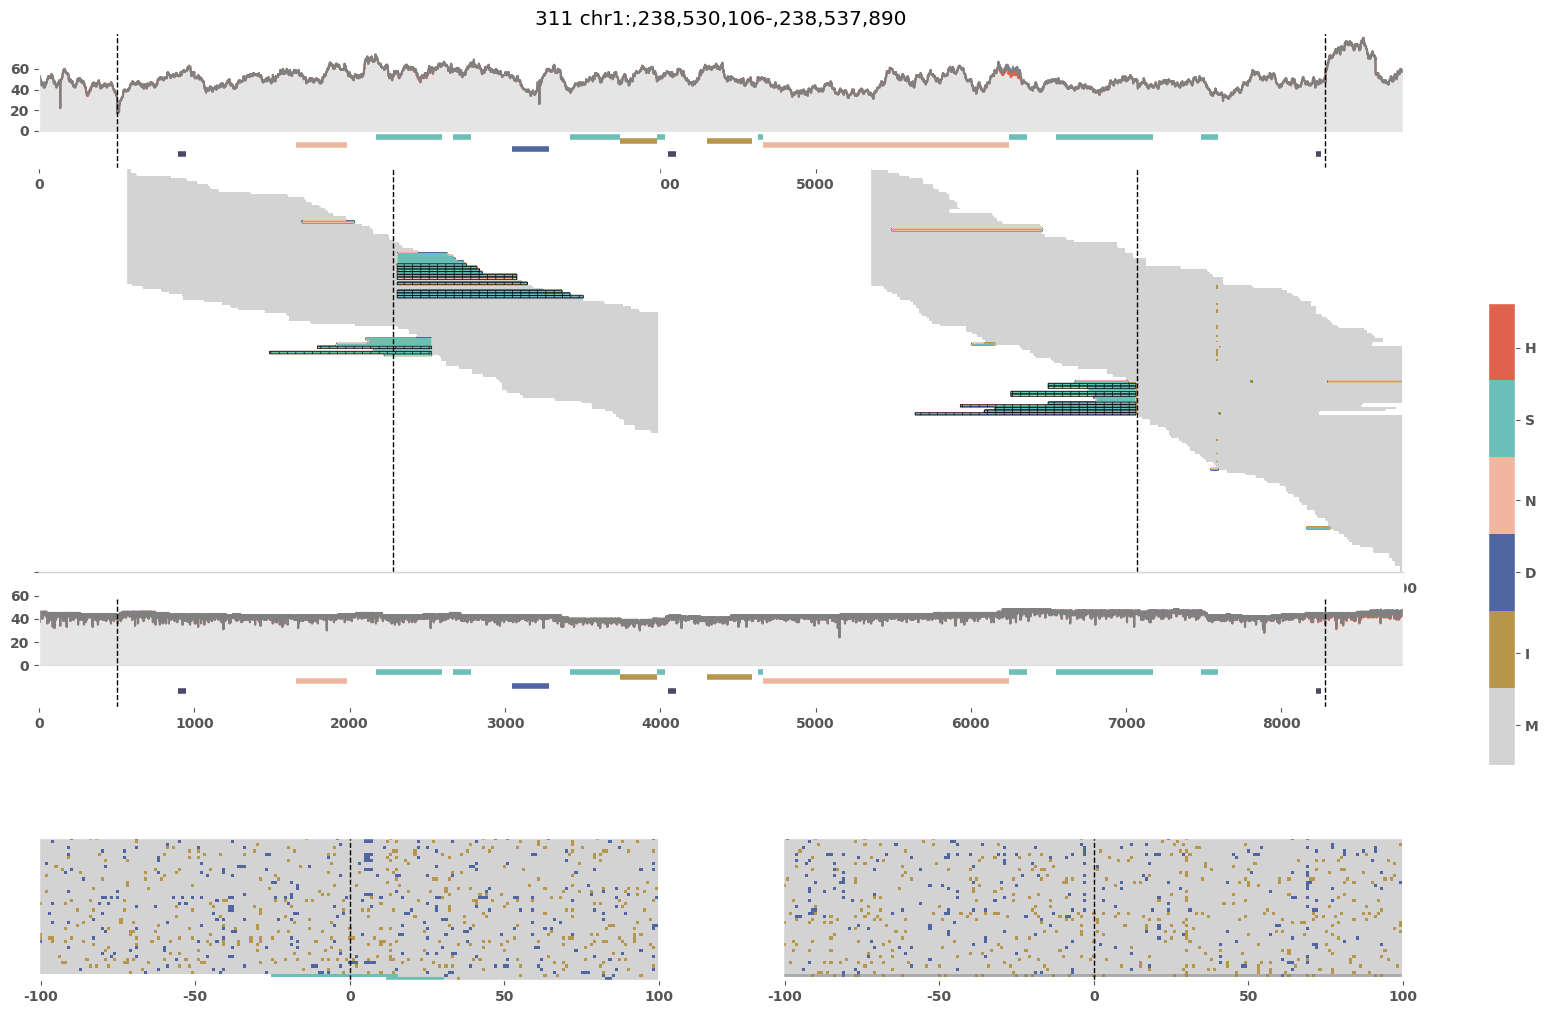

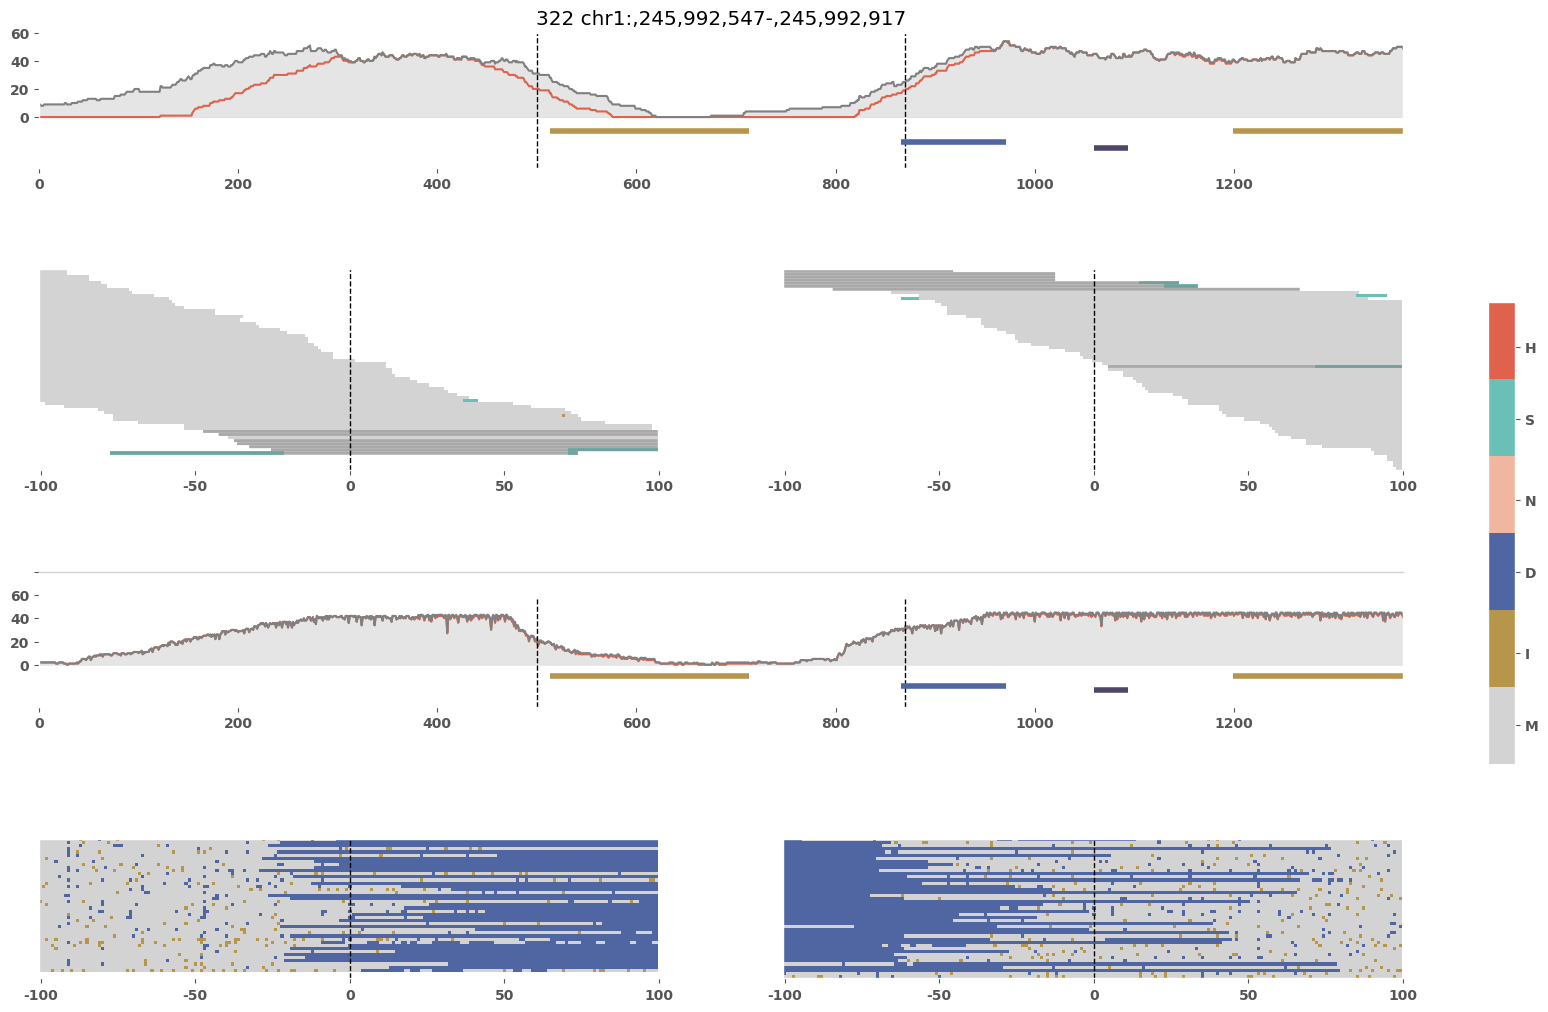

In [4]:
df = pd.read_csv(f'{QCDIR}/{QCFILE}', sep='\t')

for i in tqdm(range(df.shape[0])):
    svid = df.loc[i, 'id']
    chrom = df.loc[i, 'chrom']
    start = df.loc[i, 'start']
    end = df.loc[i, 'end']
    title = svid + ' ' + chrom + ':' + add_comma_to_pos(start) + '-' + add_comma_to_pos(end)
    
    if TYPE == 'INS':
        collapse = False
    else:
        collapse = True
    plot_breakpoints_ill_pb(BAM_ILL, BAM_PB, REPEATS, chrom, start, end, collapse_ins=collapse, window=100, title=title, outfile=f'{QCDIR}/images/{svid}.png')